# Lección 8.1 · $k$-mers y espectros de $k$-mers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-08-ensamblaje/8.1_kmers_espectros.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 8 — Ensamblaje y anotación de genomas** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio–avanzado | Lecciones 6.2 (lecturas de *E. coli* y su control de calidad), 6.3 (cobertura y Lander–Waterman) y 7.1 (índices y $k$-mers) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Definir** qué es un $k$-mer y un $k$-mer **canónico** $\kappa(x) = \min\{x, \bar{x}\}$, explicar por qué casi todas las
   herramientas usan $k$ **impar** y **codificar** $k$-mers como enteros de 2 bits por base.
2. **Calcular** la cobertura de $k$-mers $\lambda_k = \frac{N(L-k+1)}{G}(1-e)^k$ y **explicar** por qué el pico del espectro
   nunca está donde dice la cobertura por bases.
3. **Construir** e **interpretar** un espectro de $k$-mers $h(m)$ y reconocer las firmas de los errores, la
   heterocigosidad y las repeticiones.
4. **Ajustar** el modelo diploide (mezcla de binomiales negativas, al estilo de GenomeScope) por mínimos cuadrados y
   **estimar** sin referencia el tamaño $\widehat{G}$, la heterocigosidad $\widehat{h}$ y la tasa de error de un genoma.
5. **Explicar** cómo cuentan miles de millones de $k$-mers Jellyfish (tabla *hash* sin bloqueos) y KMC (particiones
   en disco), y para qué sirve un **filtro de Bloom**.
6. **Estimar el tamaño del genoma** del clon del LTEE **SRR2584863** a partir de su espectro real, **reconciliar** con
   honestidad el pico en 73 con la cobertura teórica $c_k \approx 87$ y **comparar** $\widehat{G}$ con los 4 629 812 pb
   de REL606.
7. **Elegir** $k$ con criterio, equilibrando unicidad ($p_{\text{azar}}$) y cobertura efectiva ($(1-e)^k$).

## 🗺️ Mapa de la clase

1. Medir un libro sin leerlo: el problema y el caso real del LTEE
2. Qué es un $k$-mer: palabras, hebras, $k$-mers canónicos y codificación en 2 bits (🎬 animación)
3. Cobertura de $k$-mers: por qué el pico se corre a la izquierda
4. El espectro de $k$-mers y sus tres firmas: errores, heterocigosidad y repeticiones (🎬 animación)
5. Un modelo para el espectro de un diploide: $\alpha$, la mezcla y la masa (🔍 interactivo)
6. Contar miles de millones de $k$-mers: tablas *hash*, filtros de Bloom, Jellyfish y KMC
7. 🧪 El clon del LTEE: tamaño del genoma **antes** de ensamblar (🔍 interactivo)
8. Elegir $k$ (🔍 interactivo)
9. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección «$k$-mers y espectros de $k$-mers» del capítulo 8 del libro del curso. Usamos su
> misma notación y sus mismos ejemplos numéricos; cuando citemos una ecuación del libro («ecuación 08-ck») la
> escribiremos también aquí, de modo que el cuaderno se puede leer solo.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, gzip, time, shutil, subprocess, tempfile, math, sys
import matplotlib as mpl
from collections import Counter
from scipy import stats, optimize
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle, FancyBboxPatch

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=60):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia de respaldo en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def course_file(name):
    """Deja una copia local de un archivo del curso y devuelve su ruta (para herramientas de línea de comandos)."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        open(name, "wb").write(course_bytes(name))
    return name

# --- Utilidades de secuencias que usaremos toda la clase ---------------------------------------
COMP = str.maketrans("ACGT", "TGCA")
def revcomp(s):
    """Reverso complementario de una cadena de ADN."""
    return s.translate(COMP)[::-1]

LUT = np.full(256, 4, dtype=np.uint8)            # tabla ASCII → código de 2 bits (4 = N u otro símbolo)
for code_, base_ in enumerate(b"ACGT"):
    LUT[base_] = code_
    LUT[base_ + 32] = code_                       # también minúsculas

def encode(seq):
    """Convierte una cadena ACGT en un arreglo de enteros 0..3 (4 para N)."""
    return LUT[np.frombuffer(seq.encode() if isinstance(seq, str) else seq, dtype=np.uint8)]

def read_fastq_seqs(name):
    """Devuelve la lista de secuencias (bytes) de un FASTQ.gz del curso."""
    raw = gzip.decompress(course_bytes(name))
    return [s for s in raw.split(b"\n")[1::4] if s]

rng = np.random.default_rng(81)       # semilla fija para los ejemplos pequeños de la clase
print("SciPy listo · Lección 8.1")

Entorno listo ✔  |  Colab: False


SciPy listo · Lección 8.1


## 1. Medir un libro sin leerlo

Suponga que le entregan **cuarenta fotocopias** de un libro, cada una cortada en frases sueltas, todo mezclado en una
caja. No sabe cuántas páginas tiene el libro, pero puede contar cuántas veces aparece cada frase de, digamos, seis
palabras. La mayoría aparecerá unas **cuarenta veces**, una por fotocopia. Si cuenta el total de frases de la caja y lo
divide entre cuarenta, obtendrá la **longitud del libro sin haberlo leído**.

Pero la caja dice más cosas:

* las frases que aparecen **una sola vez** delatan **erratas** de la fotocopiadora (nadie más las repite);
* las que aparecen **ochenta veces** son **estribillos** que el autor escribió dos veces;
* y si el libro es en realidad **dos ediciones** ligeramente distintas mezcladas, habrá un grupo de frases que aparece
  **veinte** veces: las que difieren entre ediciones.

Todo eso está escrito en **un solo histograma**: cuántas frases distintas aparecen 1, 2, 3, … veces. En genómica, las
«frases» son **$k$-mers** (palabras de $k$ letras), las fotocopias son las **lecturas** del secuenciador y el histograma
es el **espectro de $k$-mers**.

### Por qué importa hoy: un clon del experimento de Lenski llega al laboratorio

Seguimos el hilo del curso. En la Lección 6.2 controlamos la calidad de las lecturas Illumina **SRR2584863**, un clon de
*Escherichia coli* B del **experimento de evolución a largo plazo** (LTEE) de Richard Lenski, y en el Módulo 7 las
mapeamos contra la cepa ancestral **REL606** (NC_012967.1). Ahora cambiamos de papel: imagine que usted **no tiene
referencia**, como le pasa a un laboratorio que recibe un aislado clínico nuevo de un brote hospitalario. Antes de lanzar
un ensamblador que tardará horas, quiere responder tres preguntas **en minutos**:

1. ¿Qué **tamaño** tiene el genoma? (¿Es de verdad una sola bacteria o hay contaminación?)
2. ¿Qué **cobertura** efectiva tengo? (¿Alcanza para ensamblar?)
3. ¿Cuán **ruidosas** son las lecturas, cuán **repetitivo** y, si fuera un eucariota, cuán **heterocigoto** es el genoma?

Al final de la clase responderemos las tres con el espectro **real** de las 3.1 millones de lecturas de SRR2584863, y
compararemos el tamaño estimado con los **4 629 812 pb** de REL606, que por ahora fingimos no conocer.

## 2. Qué es un $k$-mer

### 2.1 Palabras de longitud fija

La lectura de un secuenciador es **demasiado larga y ruidosa** para compararla entera con todas las demás (dos lecturas
del mismo sitio difieren si una tiene un error) y **demasiado corta** para situarla sola en un genoma. Casi todos los
algoritmos de ensamblaje, y muchos de mapeo (Lección 7.2), clasificación metagenómica y detección de variantes, trabajan
con una unidad intermedia: **subcadenas de longitud fija**.

Piense en la matrícula de un coche: con 6 caracteres basta para identificarlo entre millones. Un $k$-mer es la
«matrícula» de una posición del genoma: si es lo bastante largo, casi siempre señala un único lugar.

**Ejemplo a mano.** La lectura `CAGGTTGC` ($L = 8$) contiene, con $k = 4$, estas palabras, deslizando una ventana de 4
letras un paso cada vez:

| $i$ | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| $s_{i..i+3}$ | `CAGG` | `AGGT` | `GGTT` | `GTTG` | `TTGC` |

Son $L - k + 1 = 8 - 4 + 1 = 5$ $k$-mers. La ventana no puede empezar en la posición 6 porque se saldría de la lectura.

> **Definición ($k$-mer).** Un $k$-mer es una subcadena de longitud $k$ de una secuencia. Una lectura $s$ de longitud $L$
> contiene $L-k+1$ $k$-mers, $s_{i..i+k-1}$ para $i = 1, \dots, L-k+1$.

Con lecturas Illumina de $L = 150$ y $k = 21$, cada lectura aporta $150 - 21 + 1 = 130$ $k$-mers.

In [2]:
def kmers_of(s, k):
    """Lista de los L-k+1 k-mers de la cadena s (en el orden en que aparecen)."""
    return [s[i:i + k] for i in range(len(s) - k + 1)]

read1 = "CAGGTTGC"
print("k-mers (k=4) de", read1, "→", kmers_of(read1, 4), f"· L-k+1 = {len(read1) - 4 + 1}")
print("k-mers por lectura de 150 pb con k=21:", len(kmers_of("A" * 150, 21)))

k-mers (k=4) de CAGGTTGC → ['CAGG', 'AGGT', 'GGTT', 'GTTG', 'TTGC'] · L-k+1 = 5
k-mers por lectura de 150 pb con k=21: 130


### 2.2 Las dos hebras: el $k$-mer canónico

El ADN tiene dos hebras complementarias y antiparalelas, y el secuenciador lee **una u otra al azar**. La misma posición
del genoma puede llegarnos como `CAGG` (hebra directa) o como su **reverso complementario** `CCTG` (hebra opuesta,
leída en sentido contrario). Si contáramos esas dos palabras por separado, cada posición del genoma quedaría repartida
en dos contadores a medias.

La solución es elegir **un representante** de cada pareja, como cuando dos personas comparten un casillero y se acuerda
guardar todo bajo el apellido que va primero en el alfabeto:

$$
\kappa(x) = \min\{x,\ \bar{x}\} \qquad \text{(ecuación 08-canonico del libro)}
$$

donde el mínimo es en **orden lexicográfico** ($\texttt{A} < \texttt{C} < \texttt{G} < \texttt{T}$).

| Símbolo | Significado |
|---|---|
| $k$ | Longitud de las palabras que se cuentan (típicamente entre 21 y 127 para lecturas cortas) |
| $L$ | Longitud de la lectura en pares de bases |
| $\bar{x}$ | Reverso complementario de $x$: se invierte el orden y se cambia A↔T, C↔G |
| $\kappa(x)$ | Representante canónico: la misma clave para las dos hebras |

**Ejemplo a mano.** $x = \texttt{TTGC}$: invertimos → `CGTT`; complementamos → $\bar{x} = \texttt{GCAA}$. Como
`GCAA` < `TTGC` (G va antes que T), $\kappa(\texttt{TTGC}) = \texttt{GCAA}$. En cambio, para $x = \texttt{CAGG}$,
$\bar{x} = \texttt{CCTG}$ y, comparando letra a letra (`C = C`, luego `A < C`), $\kappa = \texttt{CAGG}$.

### 2.3 ¿Por qué $k$ impar?

Con $k$ **par** existen palíndromos de ADN como `GAATTC` (el sitio de corte de la enzima *Eco*RI), que son **su propio
reverso complementario**: $x = \bar{x}$. Para ellos no se puede saber de qué hebra vino la lectura. Con $k$ **impar**
eso es imposible: la base central tendría que ser igual a su propio complemento (A = T o C = G), lo cual no ocurre.
Por eso Jellyfish, KMC, SPAdes y GenomeScope usan casi siempre $k$ impar: 21, 31, 33, 55, 77…

In [3]:
def canonical(kmer):
    """k-mer canónico: el menor (orden alfabético) entre el k-mer y su reverso complementario."""
    return min(kmer, revcomp(kmer))

for x in ["CAGG", "TTGC", "GAATTC", "ACGTT"]:
    print(f"x = {x:7s} x̄ = {revcomp(x):7s} κ(x) = {canonical(x):7s}"
          + ("   ← ¡palíndromo! x = x̄" if x == revcomp(x) else ""))

# ¿Cuántos k-mers son su propio reverso complementario? Enumeración exhaustiva para k pequeños
from itertools import product
print("\n k | 4^k posibles | palíndromos (x = x̄) | canónicos distintos")
for k in range(2, 9):
    words = ("".join(p) for p in product("ACGT", repeat=k))
    pal = sum(w == revcomp(w) for w in words)
    print(f"{k:2d} | {4**k:12,d} | {pal:19,d} | {(4**k + pal) // 2:,d}")

x = CAGG    x̄ = CCTG    κ(x) = CAGG   
x = TTGC    x̄ = GCAA    κ(x) = GCAA   
x = GAATTC  x̄ = GAATTC  κ(x) = GAATTC    ← ¡palíndromo! x = x̄
x = ACGTT   x̄ = AACGT   κ(x) = AACGT  

 k | 4^k posibles | palíndromos (x = x̄) | canónicos distintos
 2 |           16 |                   4 | 10
 3 |           64 |                   0 | 32
 4 |          256 |                  16 | 136
 5 |        1,024 |                   0 | 512
 6 |        4,096 |                  64 | 2,080
 7 |       16,384 |                   0 | 8,192
 8 |       65,536 |                 256 | 32,896


> 🔎 **Qué observamos.** Para $k$ par hay exactamente $4^{k/2}$ palíndromos (basta elegir la primera mitad: la segunda
> queda obligada). Para $k$ impar hay **cero**, y el número de $k$-mers canónicos es exactamente $4^k/2$: cada clave
> canónica corresponde a **dos** $k$-mers orientados distintos, sin excepciones.

### 2.4 Guardar $k$-mers como números: 2 bits por base

Guardar `"CAGGTTGCAGAAGGATTCAGA"` como texto ocupa 21 bytes (168 bits). Pero sólo hay cuatro letras, y cuatro
posibilidades caben en **2 bits**: A = `00`, C = `01`, G = `10`, T = `11`. Un $k$-mer de $k \le 32$ cabe entonces en un
único entero de 64 bits, ocho veces menos memoria, y compararlo es una sola instrucción del procesador.

**Ejemplo a mano** con `CAGG`: C = 01, A = 00, G = 10, G = 10 → `01 00 10 10` en binario $= 64 + 0 + 8 + 2 = 74$.

Dos trucos hacen esto muy rápido:

* **Ventana deslizante.** Para pasar de `CAGG` a `AGGT` no se recalcula todo: se desplaza el número 2 bits a la izquierda
  (entra un hueco al final), se añade la nueva base (T = 11) y se borran con una **máscara** los 2 bits que sobran a la
  izquierda. Tiempo constante por $k$-mer: $\text{código}' = ((\text{código} \ll 2)\ |\ b) \ \&\ (4^k - 1)$.
* **Complemento con aritmética.** Con esta codificación, el complemento de una base $b$ es $3 - b$ (A = 0 ↔ T = 3,
  C = 1 ↔ G = 2). El reverso complementario se construye metiendo cada $3 - b$ por la **izquierda**.

Y un regalo: el **orden numérico** de los enteros coincide con el **orden alfabético** de las cadenas, así que
$\kappa(x)$ es simplemente el mínimo de dos números.

In [4]:
def kmer_code(kmer):
    """Código entero de 2 bits por base (A=0, C=1, G=2, T=3)."""
    v = 0
    for b in kmer:
        v = (v << 2) | "ACGT".index(b)
    return v

def rolling_codes(s, k):
    """Códigos de todos los k-mers de s con la ventana deslizante (desplazar, añadir, enmascarar)."""
    mask = (1 << (2 * k)) - 1
    v, out = 0, []
    for i, b in enumerate(s):
        v = ((v << 2) | "ACGT".index(b)) & mask
        if i >= k - 1:
            out.append(v)
    return out

print("CAGG →", kmer_code("CAGG"), "=", format(kmer_code("CAGG"), "08b"))
print("Códigos deslizantes de CAGGTTGC:", rolling_codes("CAGGTTGC", 4))
print("Recalculados uno por uno       :", [kmer_code(x) for x in kmers_of("CAGGTTGC", 4)])

# el orden numérico coincide con el alfabético
words = ["".join(p) for p in product("ACGT", repeat=5)]
assert sorted(words) == sorted(words, key=kmer_code)
print("✔ El orden de los enteros es el orden alfabético de los 1 024 5-mers")

CAGG → 74 = 01001010
Códigos deslizantes de CAGGTTGC: [74, 43, 175, 190, 249]
Recalculados uno por uno       : [74, 43, 175, 190, 249]
✔ El orden de los enteros es el orden alfabético de los 1 024 5-mers


Para contar millones de $k$-mers no podemos ir letra por letra en Python. La función siguiente hace lo mismo **para
todas las lecturas a la vez** con NumPy: una matriz de lecturas (una fila por lectura) se recorre columna a columna $k$
veces, construyendo en paralelo los códigos directos (desplazar e insertar a la derecha) y los reversos complementarios
($3-b$ insertado por la izquierda). Los $k$-mers que contienen una `N` se descartan, como hacen Jellyfish y KMC.

In [5]:
def kmers_canon(R, k):
    """Códigos canónicos (int64, 2 bits por base) de todos los k-mers de una matriz de lecturas R
    (n lecturas × L, valores 0..3; 4 = N). Devuelve un vector plano sin los k-mers que contienen N."""
    n, Lr = R.shape
    m = Lr - k + 1
    fwd = np.zeros((n, m), dtype=np.int64)
    rev = np.zeros((n, m), dtype=np.int64)
    bad = np.zeros((n, m), dtype=bool)
    for j in range(k):
        col = R[:, j:j + m]
        bad |= col > 3
        c = (col & 3).astype(np.int64)
        fwd = (fwd << 2) | c                      # hebra directa: la base entra por la derecha
        rev = rev | ((3 - c) << (2 * j))          # reverso complementario: el complemento entra por la izquierda
    return np.minimum(fwd, rev)[~bad]

def decode(code, k):
    """Del entero de 2 bits a la cadena ACGT."""
    return "".join("ACGT"[(code >> (2 * (k - 1 - i))) & 3] for i in range(k))

def count_spectrum(codes):
    """Espectro h(m): h[m] = número de k-mers distintos vistos exactamente m veces."""
    _, cnt = np.unique(codes, return_counts=True)
    return np.bincount(cnt)

# Comprobación con la lectura del ejemplo: los mismos canónicos que con cadenas
R_demo = encode("CAGGTTGC")[None, :]
print([decode(c, 4) for c in kmers_canon(R_demo, 4)])
print([canonical(x) for x in kmers_of("CAGGTTGC", 4)])

['CAGG', 'ACCT', 'AACC', 'CAAC', 'GCAA']
['CAGG', 'ACCT', 'AACC', 'CAAC', 'GCAA']


### 2.5 Del genoma a las lecturas y de las lecturas a un histograma

El ejemplo del libro: un genoma de 15 pb, `CAGGTTGCAGAAGGA`, secuenciado con **cuatro lecturas solapadas**. Contamos
los 4-mers canónicos de las cuatro lecturas (el mismo código del libro, `espectro.py`) y construimos el histograma: para
cada multiplicidad $m$, cuántos $k$-mers **distintos** se vieron exactamente $m$ veces.

In [6]:
def count_kmers(reads, k=21):
    """Cuenta k-mers canónicos con un diccionario (claro, pero lento: sólo para ejemplos pequeños)."""
    c = Counter()
    for s in reads:
        for i in range(len(s) - k + 1):
            km = s[i:i + k]
            if "N" not in km:
                c[canonical(km)] += 1
    return c

def spectrum(counts):
    """h[m] = número de k-mers distintos vistos m veces."""
    return Counter(counts.values())

toy_genome = "CAGGTTGCAGAAGGA"
toy_reads = ["CAGGTTGC", "GTTGCAGA", "GCAGAAGG", "AGAAGGA"]
toy_counts = count_kmers(toy_reads, k=4)
print(sorted(spectrum(toy_counts).items()), "  ← el espectro de la figura 8.1 del libro")
print("k-mers leídos:", sum(toy_counts.values()), "· distintos:", len(toy_counts))
for km, n in sorted(toy_counts.items(), key=lambda t: (-t[1], t[0])):
    print(f"  {km}  n(x) = {n}")

[(1, 5), (2, 7)]   ← el espectro de la figura 8.1 del libro
k-mers leídos: 19 · distintos: 12
  AAGG  n(x) = 2
  AGAA  n(x) = 2
  CAAC  n(x) = 2
  CAGA  n(x) = 2
  CTGC  n(x) = 2
  CTTC  n(x) = 2
  GCAA  n(x) = 2
  AACC  n(x) = 1
  ACCT  n(x) = 1
  AGGA  n(x) = 1
  CAGG  n(x) = 1
  TGCA  n(x) = 1


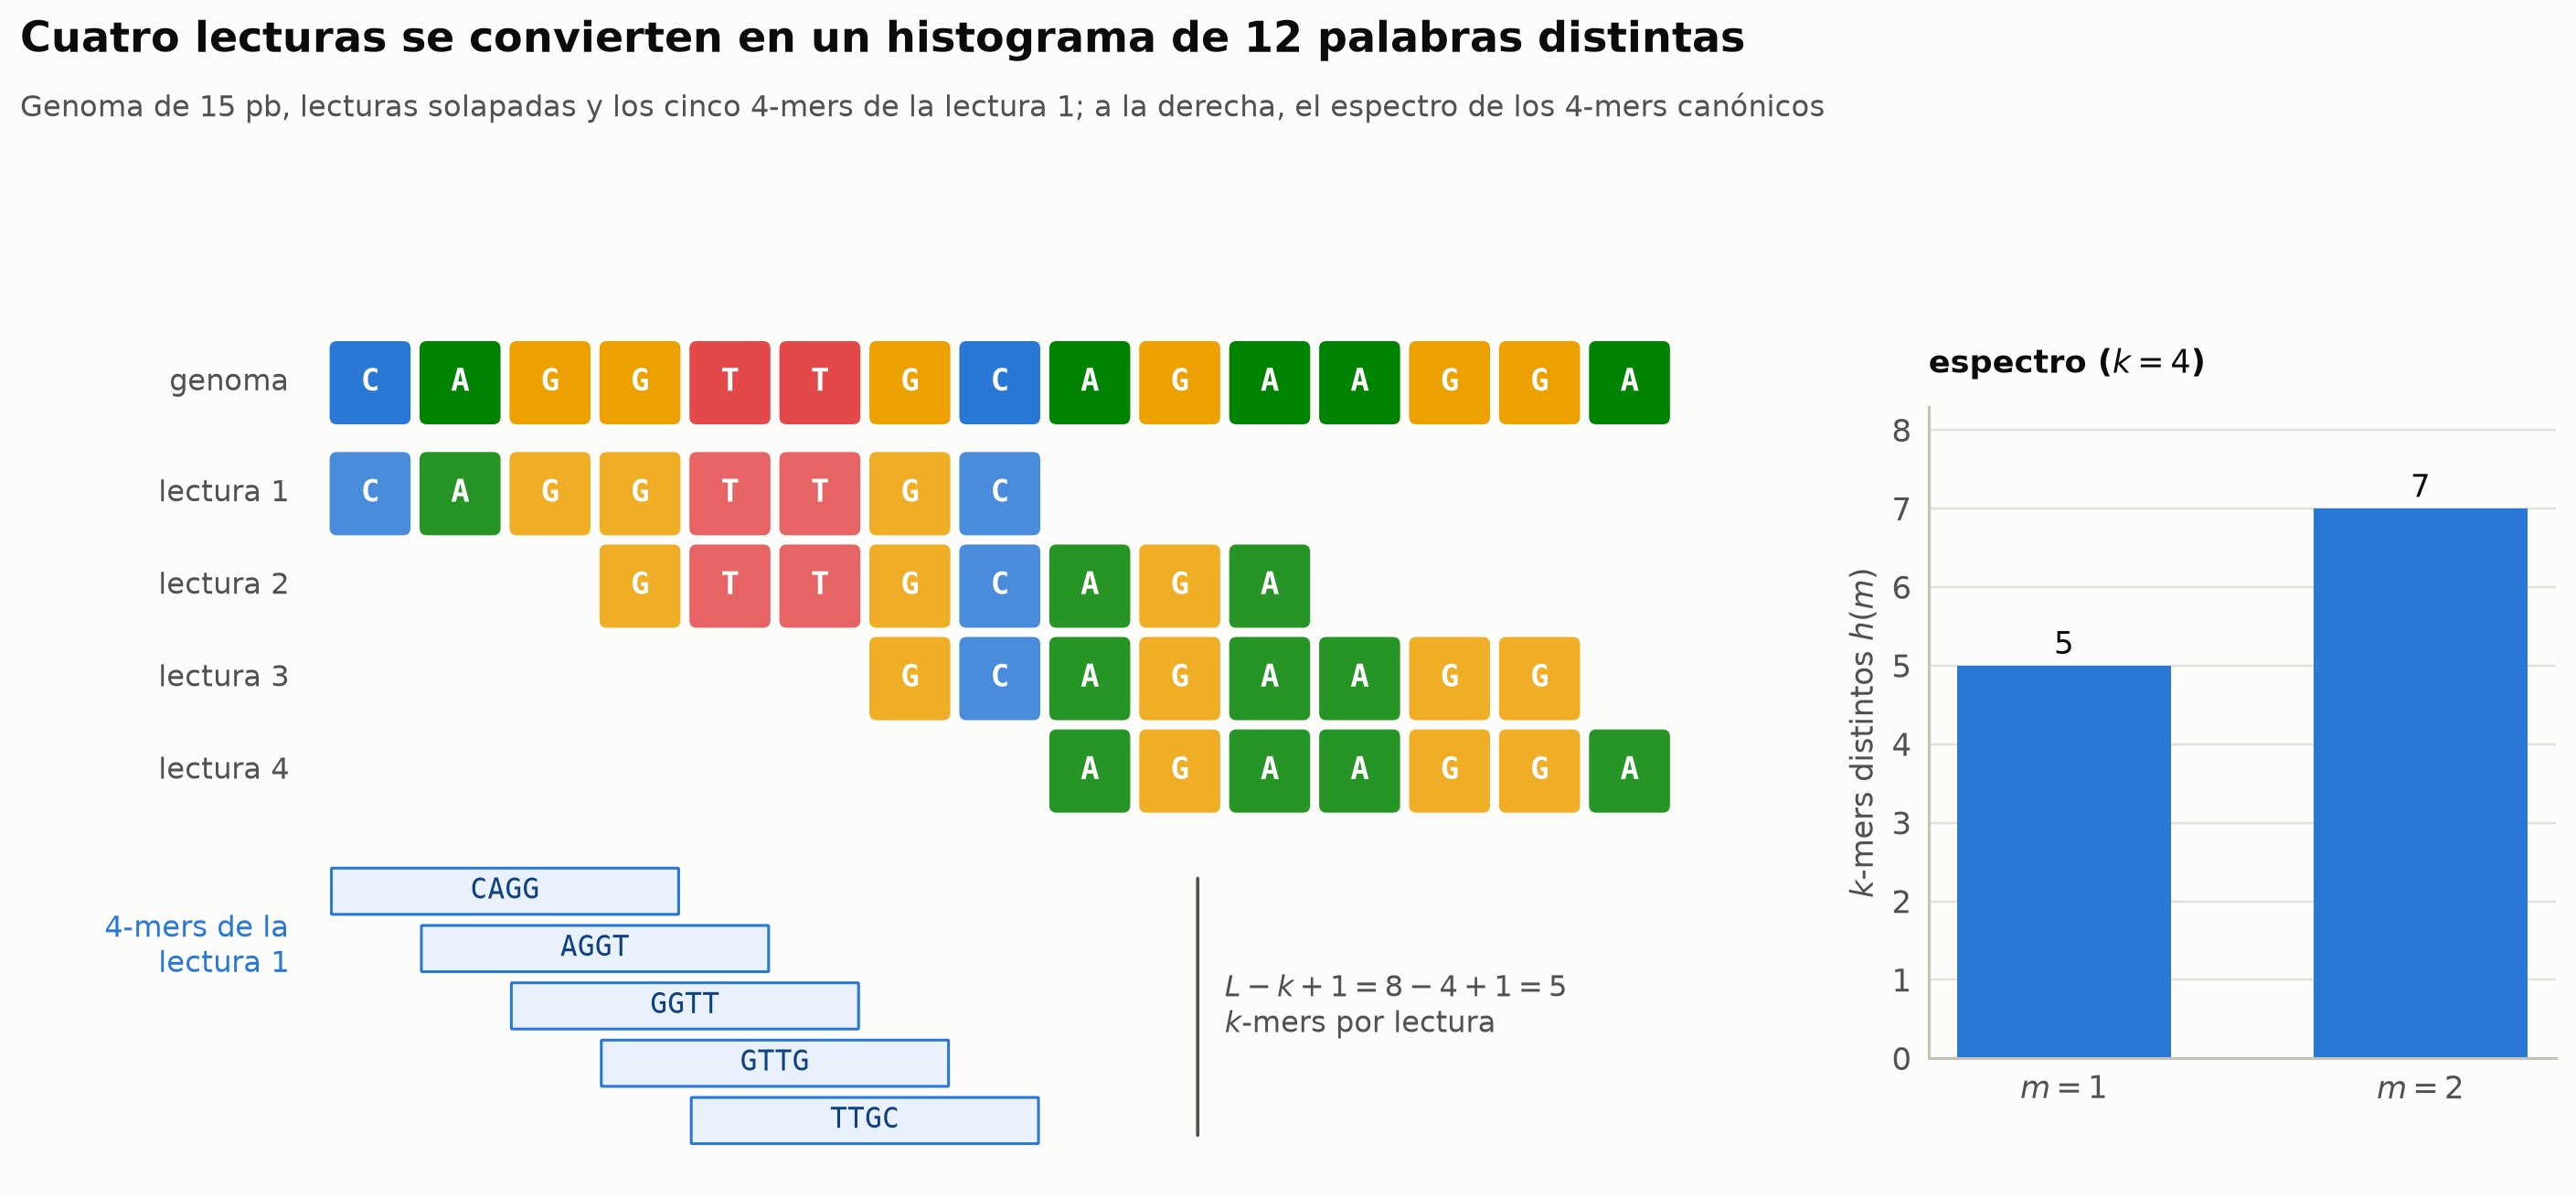

In [7]:
toy_starts = [0, 3, 6, 8]
fig = plt.figure(figsize=(13, 5.4))
ax = fig.add_axes([0.02, 0.05, 0.64, 0.80])
axs = fig.add_axes([0.74, 0.16, 0.24, 0.60])

def draw_base(ax, x, y, b, alpha=1.0, size=0.86):
    ax.add_patch(FancyBboxPatch((x - size / 2, y - size / 2), size, size, boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=ec.NUC_COLORS[b], ec="none", alpha=alpha))
    ax.text(x, y, b, ha="center", va="center", color="white", fontsize=11, fontweight="bold", family="monospace")

ax.text(-0.9, 0, "genoma", ha="right", va="center", fontsize=10.5, color=ec.INK_2)
for i, b in enumerate(toy_genome):
    draw_base(ax, i, 0, b)
for r, (st, s) in enumerate(zip(toy_starts, toy_reads)):
    ax.text(-0.9, -1.2 - r, f"lectura {r + 1}", ha="right", va="center", fontsize=10.5, color=ec.INK_2)
    for j, b in enumerate(s):
        draw_base(ax, st + j, -1.2 - r, b, alpha=0.85)
ax.text(-0.9, -6.1, "4-mers de la\nlectura 1", ha="right", va="center", fontsize=10.5, color=ec.BLUE)
for t, km in enumerate(kmers_of(toy_reads[0], 4)):
    y = -5.5 - 0.62 * t
    ax.add_patch(FancyBboxPatch((t - 0.42, y - 0.24), 3.84, 0.48, boxstyle="round,pad=0.01",
                                fc="#e8f1fc", ec=ec.BLUE, lw=1))
    ax.text(t + 1.5, y, km, ha="center", va="center", family="monospace", fontsize=10, color="#104281")
ax.annotate("", xy=(9.2, -5.3), xytext=(9.2, -8.2),
            arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=1.2))
ax.text(9.5, -6.75, "$L-k+1 = 8-4+1 = 5$\n$k$-mers por lectura", va="center", fontsize=10.5, color=ec.INK_2)
ax.set_xlim(-3.6, 15); ax.set_ylim(-8.6, 0.8); ax.axis("off")

h_toy = spectrum(toy_counts)
axs.bar([1, 2], [h_toy[1], h_toy[2]], color=ec.BLUE, width=0.6)
for m_, v_ in h_toy.items():
    axs.text(m_, v_ + 0.15, str(v_), ha="center", fontsize=11, color=ec.INK)
axs.set_xticks([1, 2], ["$m = 1$", "$m = 2$"]); axs.set_ylim(0, 8.3)
axs.set_ylabel("$k$-mers distintos $h(m)$"); axs.set_title("espectro ($k = 4$)", fontsize=11.5, loc="left")
ec.fig_title(fig, "Cuatro lecturas se convierten en un histograma de 12 palabras distintas",
             "Genoma de 15 pb, lecturas solapadas y los cinco 4-mers de la lectura 1; a la derecha, el espectro de los 4-mers canónicos")
plt.show()

> 🔎 **Qué observamos.** Las cuatro lecturas aportan $5 + 5 + 5 + 4 = 19$ $k$-mers leídos, pero sólo **12 distintos**:
> 7 se leyeron dos veces (están en la zona donde se solapan dos lecturas) y 5 una sola vez: los que cubre una sola
> lectura, casi todos en los extremos del genoma, pero también `TGCA`, en el interior, que sólo cabe entera en la lectura 2. Observe lo que **se perdió**: la información de *dónde* estaba cada $k$-mer. El espectro sólo guarda
> *cuántas veces* aparece. Aun así, veremos que eso basta para medir el genoma.

> ✅ **Compruebe su comprensión.** Si una quinta lectura repitiera exactamente la lectura 2 (`GTTGCAGA`), ¿cómo cambiaría
> el espectro? *(Respuesta: sus 5 $k$-mers suben una unidad; los que estaban en $m=2$ pasan a $m=3$ y los que estaban
> en $m=1$ pasan a $m=2$. La masa $\sum_m m\,h(m)$ sube de 19 a 24.)*

La animación siguiente hace el conteo paso a paso: la ventana de $k = 4$ recorre cada lectura, cada palabra se lleva a su
forma canónica, su contador sube, y el histograma se actualiza.

![Una ventana de k = 4 recorre las cuatro lecturas; cada 4-mer se convierte en canónico, su contador n(x) sube y el espectro h(m) se reconstruye en vivo hasta llegar a 5 k-mers con m = 1 y 7 con m = 2](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.1_ventana_espectro.gif)

*Una ventana de k = 4 recorre las cuatro lecturas; cada 4-mer se convierte en canónico, su contador n(x) sube y el espectro h(m) se reconstruye en vivo hasta llegar a 5 k-mers con m = 1 y 7 con m = 2*

In [8]:
steps = [(r, i) for r, s in enumerate(toy_reads) for i in range(len(s) - 3)]
fig = plt.figure(figsize=(13, 5.2))
axA = fig.add_axes([0.01, 0.04, 0.50, 0.84])
axB = fig.add_axes([0.53, 0.04, 0.17, 0.84])
axC = fig.add_axes([0.77, 0.18, 0.21, 0.62])

def update(f):
    for a in (axA, axB, axC):
        a.clear()
    t = min(f, len(steps) - 1)
    r, i = steps[t]
    seen = Counter()
    for rr, ii in steps[:t + 1]:
        seen[canonical(toy_reads[rr][ii:ii + 4])] += 1
    km = toy_reads[r][i:i + 4]
    cn = canonical(km)
    for rr, (st, s) in enumerate(zip(toy_starts, toy_reads)):
        axA.text(-0.9, -rr, f"lectura {rr + 1}", ha="right", va="center", fontsize=10, color=ec.INK_2)
        for j, b in enumerate(s):
            draw_base(axA, st + j, -rr, b, alpha=0.95 if rr == r else 0.35)
    axA.add_patch(Rectangle((toy_starts[r] + i - 0.5, -r - 0.55), 4, 1.1, fill=False, ec=ec.INK, lw=2.2))
    axA.text(-2.8, -4.6, f"4-mer leído: {km}   reverso compl.: {revcomp(km)}   →   canónico κ = {cn}",
             fontsize=11.5, family="monospace", color=ec.INK)
    axA.text(-2.8, -5.4, f"k-mers leídos: {t + 1} de {len(steps)}   ·   distintos: {len(seen)}",
             fontsize=10.5, color=ec.INK_2)
    axA.set_xlim(-3.2, 15); axA.set_ylim(-6, 0.8); axA.axis("off")
    axA.set_title("La ventana recorre las lecturas", loc="left", fontsize=12.5)
    # tabla de contadores
    items = sorted(seen.items())
    for q, (x, n) in enumerate(items):
        col = ec.ORANGE if x == cn else ec.INK_2
        axB.text(0.02, 1 - 0.075 * q, f"{x}  n = {n}", fontsize=10.5, family="monospace", color=col,
                 fontweight="bold" if x == cn else "normal", transform=axB.transAxes, va="top")
    axB.axis("off"); axB.set_title("contadores n(x)", loc="left", fontsize=12)
    # espectro
    hs = Counter(seen.values())
    ms = [1, 2]
    axC.bar(ms, [hs.get(1, 0), hs.get(2, 0)], color=ec.BLUE, width=0.6)
    for m_ in ms:
        axC.text(m_, hs.get(m_, 0) + 0.2, str(hs.get(m_, 0)), ha="center", fontsize=11)
    axC.set_xticks(ms, ["m = 1", "m = 2"]); axC.set_ylim(0, 13); axC.set_xlim(0.4, 2.6)
    axC.set_ylabel("k-mers distintos h(m)")
    axC.set_title("espectro h(m)", loc="left", fontsize=12)
    return []

ec.animate(fig, update, frames=len(steps) + 4, interval=650, name="8.1_ventana_espectro")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

## 3. Cobertura de $k$-mers: por qué el pico se corre a la izquierda

### 3.1 La intuición

En la Lección 6.3 definimos la **cobertura por bases** $c = NL/G$: cuántas lecturas cubren, en promedio, cada base.
Para los $k$-mers la cuenta cambia por dos razones, las dos intuitivas:

1. **Una lectura sólo «ve» un $k$-mer si lo contiene entero.** Una lectura que termina a mitad de la palabra cubre sus
   primeras bases, pero no aporta ese $k$-mer al conteo. Es como una foto de grupo: una persona sólo cuenta como
   «fotografiada» si sale **completa**, no si le cortaron media cara. De las $L$ bases de una lectura salen sólo $L-k+1$
   $k$-mers, así que la cobertura cae en el factor $(L-k+1)/L$.
2. **Un solo error estropea la palabra entera.** Si una de las $k$ bases está mal leída, la aparición ya no cuenta para el
   $k$-mer correcto: se convierte en un $k$-mer **distinto**, casi siempre nuevo y único. La probabilidad de que las $k$
   bases estén todas bien es $(1-e)^k$.

### 3.2 La fórmula

> **Teorema (cobertura de $k$-mers).** Con $N$ lecturas de longitud $L$ tomadas al azar de un genoma de tamaño $G$ y una
> tasa de error por base $e$ independiente entre posiciones, el número medio de veces que se observa **sin errores** un
> $k$-mer del genoma es

$$
\lambda_k \;=\; \underbrace{\frac{N\,(L-k+1)}{G}}_{c_k \,=\, c\,\frac{L-k+1}{L}}\;\cdot\;(1-e)^{k}
\qquad\text{(ecuación 08-ck del libro)}
$$

| Símbolo | Significado |
|---|---|
| $c$ | Cobertura por bases, $NL/G$ (Lección 6.3) |
| $c_k$ | Cobertura de $k$-mers sin tener en cuenta los errores |
| $e$ | Probabilidad de que una base de la lectura sea errónea |
| $(1-e)^k$ | Probabilidad de que las $k$ bases de una aparición del $k$-mer sean todas correctas |
| $\lambda_k$ | Cobertura efectiva de $k$-mers: la posición del pico principal del espectro |

**Derivación.** Una lectura contiene el $k$-mer que empieza en la posición $i$ del genoma si la lectura empieza en alguna
de las $L-k+1$ posiciones $i-(L-k), \dots, i$. Con $G$ posiciones de inicio equiprobables, cada lectura lo contiene con
probabilidad $(L-k+1)/G$, y el número esperado de lecturas que lo contienen es $N(L-k+1)/G = c\,(L-k+1)/L$. De esas
apariciones, sólo cuentan las que no tienen ningún error en sus $k$ bases, con probabilidad $(1-e)^k$. $\square$

**Ejemplo a mano (el del libro).** Lecturas de 150 pb, $e = 0.5\,\%$, $k = 21$ y cobertura $c = 20\times$:

$$
c_k = 20 \times \frac{150-21+1}{150} = 20 \times \frac{130}{150} = 17.33, \qquad
(1-e)^k = 0.995^{21} = 0.900, \qquad
\lambda_k = 17.33 \times 0.900 = 15.60 .
$$

**Uno de cada diez $k$-mers leídos contiene al menos un error.** Los dos factores castigan los $k$ grandes: el primero
decrece linealmente y el segundo geométricamente. Lo retomaremos al elegir $k$ (sección 8).

> 🤔 **Antes de ejecutar, prediga.** Vamos a simular un genoma haploide de 200 kb a $20\times$ con $e = 0.5\,\%$ y a
> contar, para cada 21-mer **verdadero** del genoma, cuántas veces aparece intacto en las lecturas. ¿Dónde caerá el
> promedio: cerca de 20, de 17.3 o de 15.6? ¿Y si no hubiera errores?

In [9]:
def simulate_reads(genome, cov, L=150, err=0.0, rng=rng):
    """Lecturas de longitud L con inicio uniforme, hebra al azar y errores de sustitución con tasa err.
    genome: arreglo 0..3. Devuelve una matriz n × L (el mismo esquema que usa el libro)."""
    n = int(cov * len(genome) / L)
    st = rng.integers(0, len(genome) - L + 1, n)
    R = genome[st[:, None] + np.arange(L)[None, :]]
    rc = rng.random(n) < 0.5                       # la mitad de las lecturas viene de la otra hebra
    R[rc] = (3 - R[rc])[:, ::-1]
    e = rng.random(R.shape) < err
    R[e] = (R[e] + rng.integers(1, 4, e.sum())) % 4   # cambia la base por una de las otras tres
    return R

def count_codes(R, k, chunk=20000):
    """k-mers canónicos de todas las lecturas, por bloques (para no llenar la memoria)."""
    return np.concatenate([kmers_canon(R[i:i + chunk], k) for i in range(0, len(R), chunk)])

def genome_kmer_counts(genome, codes, k):
    """Para cada posición del genoma, cuántas veces se leyó su k-mer canónico en las lecturas."""
    g_codes = kmers_canon(genome[None, :], k)
    u, cnt = np.unique(codes, return_counts=True)
    idx = np.clip(np.searchsorted(u, g_codes), 0, len(u) - 1)
    return np.where(u[idx] == g_codes, cnt[idx], 0)

t0 = time.time()
G_toy, K, L = 200_000, 21, 150
genome_toy = rng.integers(0, 4, G_toy).astype(np.uint8)
res_ck = {}
for err in (0.0, 0.005):
    codes = count_codes(simulate_reads(genome_toy, 20, L, err), K)
    res_ck[err] = genome_kmer_counts(genome_toy, codes, K)
c_k = 20 * (L - K + 1) / L
for err, n_true in res_ck.items():
    print(f"e = {err:.3f}: media observada = {n_true.mean():.2f} · teoría λ_k = {c_k * (1 - err) ** K:.2f}")
print(f"(cobertura por bases c = 20; c_k = {c_k:.2f}; tiempo {time.time() - t0:.1f} s)")

e = 0.000: media observada = 17.33 · teoría λ_k = 17.33
e = 0.005: media observada = 15.62 · teoría λ_k = 15.60
(cobertura por bases c = 20; c_k = 17.33; tiempo 0.7 s)


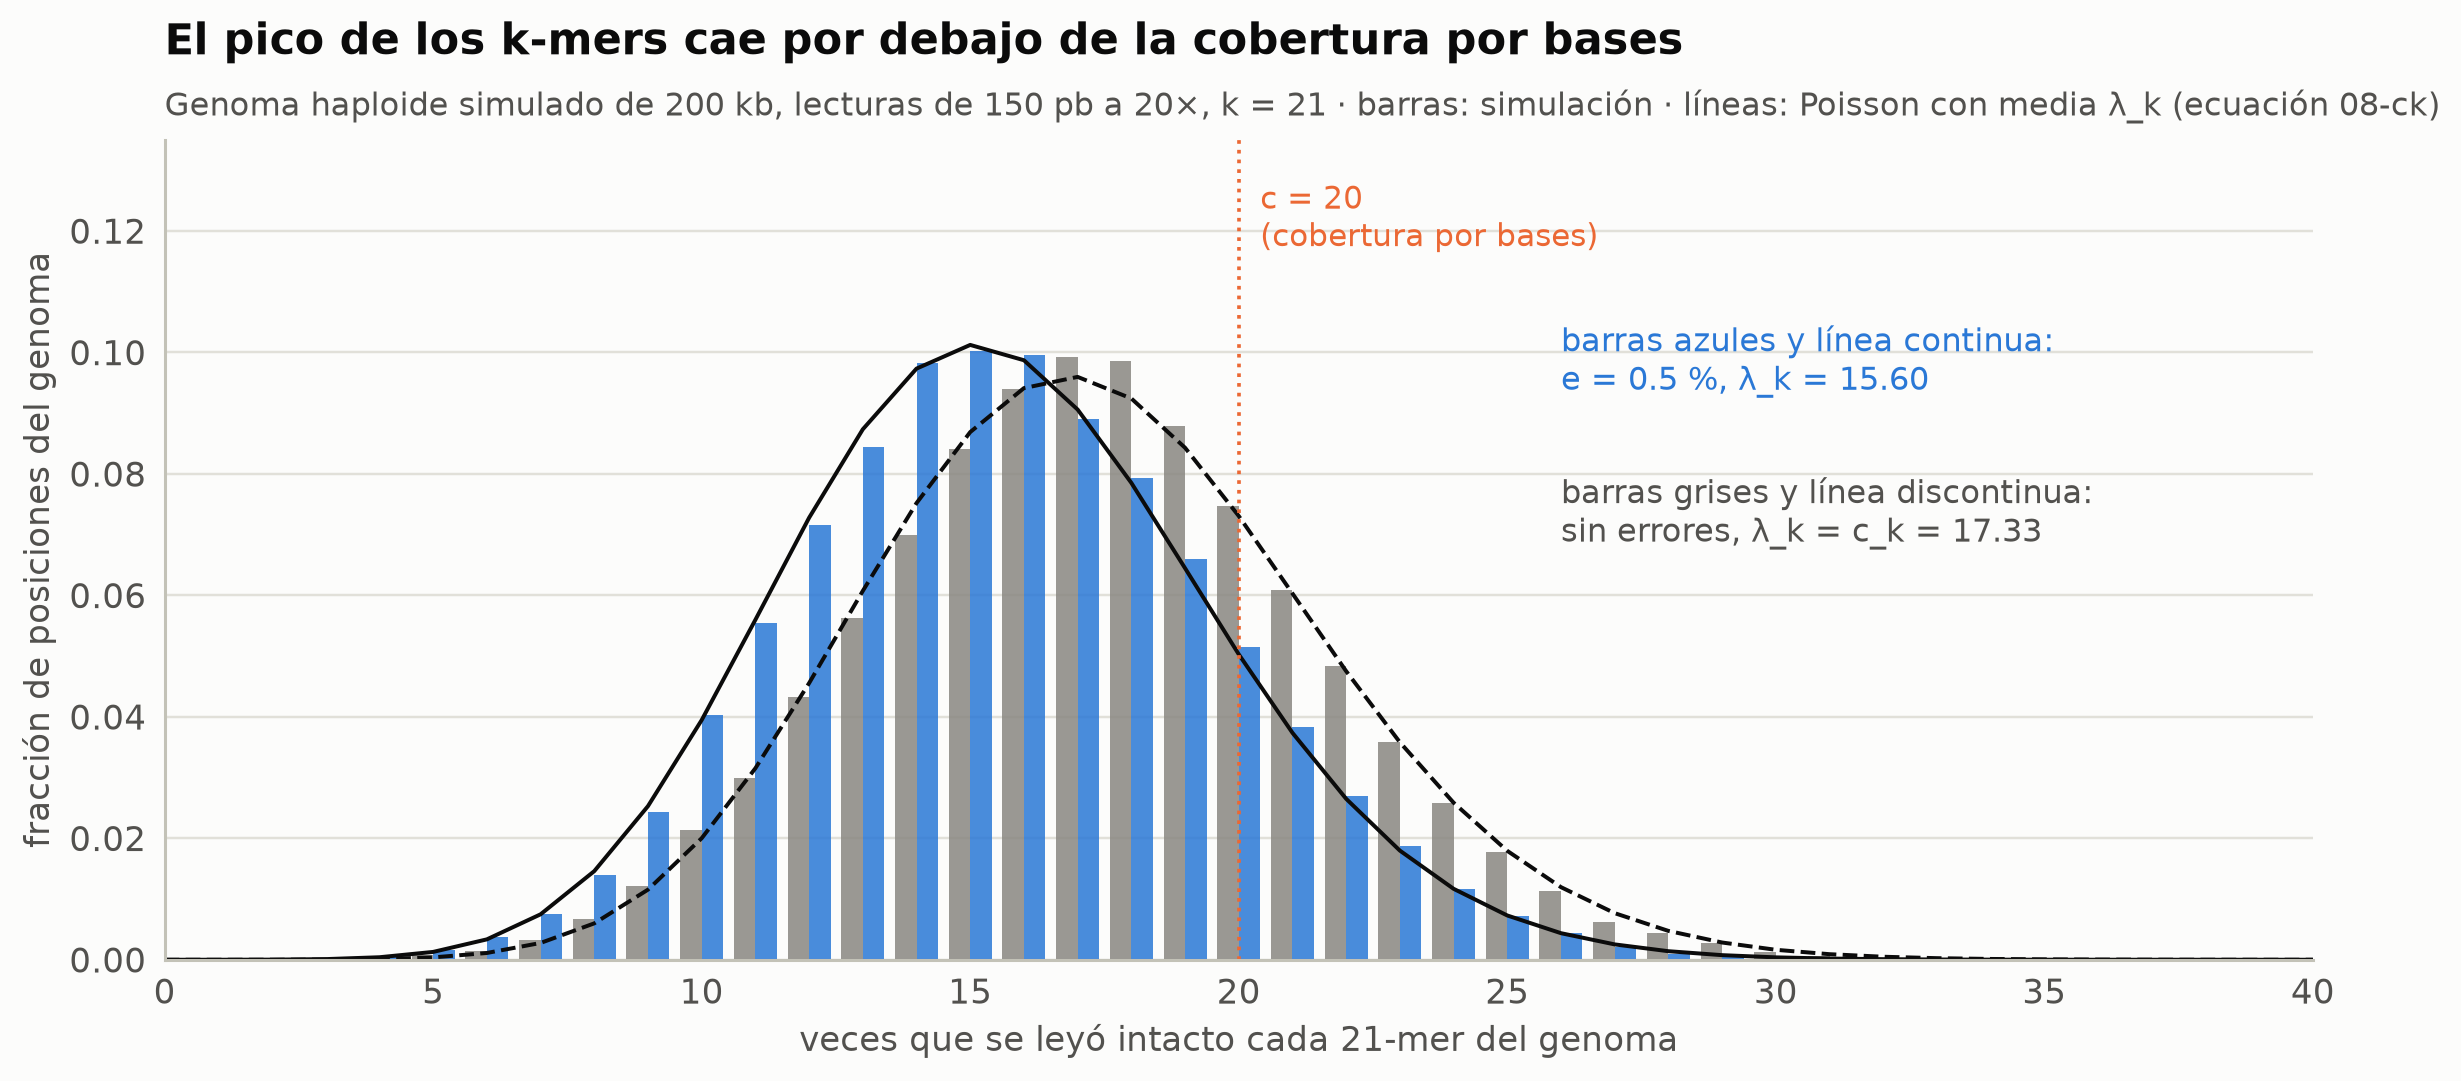

In [10]:
fig, ax = plt.subplots(figsize=(11.5, 4.8))
mm_ = np.arange(0, 41)
for (err, n_true), col, lab in zip(res_ck.items(), [ec.MUTED, ec.BLUE], ["sin errores", "e = 0.5 %"]):
    hh = np.bincount(n_true, minlength=41)[:41] / len(n_true)
    ax.bar(mm_ + (-0.2 if err == 0 else 0.2), hh, width=0.4, color=col, alpha=0.85)
    lam = c_k * (1 - err) ** K
    ax.plot(mm_, stats.poisson.pmf(mm_, lam), color=ec.INK, lw=1.3, ls="--" if err == 0 else "-")
    ax.text(26, 0.105 if err else 0.08, (f"barras azules y línea continua:\n{lab}, λ_k = {lam:.2f}" if err else
                                        f"barras grises y línea discontinua:\n{lab}, λ_k = c_k = {lam:.2f}"),
            fontsize=10.5, color=ec.BLUE if err else ec.INK_2, va="top")
ax.axvline(20, color=ec.ORANGE, lw=1.2, ls=":")
ax.text(20.4, 0.128, "c = 20\n(cobertura por bases)", color=ec.ORANGE, fontsize=10, va="top")
ax.set_xlim(0, 40); ax.set_ylim(0, 0.135)
ax.set_xlabel("veces que se leyó intacto cada 21-mer del genoma")
ax.set_ylabel("fracción de posiciones del genoma")
ec.title(ax, "El pico de los k-mers cae por debajo de la cobertura por bases",
         "Genoma haploide simulado de 200 kb, lecturas de 150 pb a 20×, k = 21 · barras: simulación · líneas: Poisson con media λ_k (ecuación 08-ck)")
plt.show()

> 🔎 **Qué observamos.** Aunque cada base está cubierta en promedio 20 veces, cada 21-mer se lee completo sólo unas 17.3
> veces (factor $130/150$), y **intacto** sólo unas 15.6 (factor $0.995^{21} = 0.90$). La simulación y la fórmula
> coinciden al primer decimal, y la forma de la campana es la de Poisson, como en el argumento de Lander y Waterman
> (Lección 6.3). Con datos reales, en la sección 7, esta cuenta nos ayudará a entender por qué el pico de SRR2584863
> está en 73 y no en 100.

> ✅ **Compruebe su comprensión.** Con lecturas de 100 pb, $k = 31$, $c = 30\times$ y $e = 1\,\%$, ¿dónde espera el pico?
> *(Respuesta: $c_k = 30 \times 70/100 = 21$; $(0.99)^{31} = 0.732$; $\lambda_k = 15.4$. La mitad de la cobertura se
> perdió por el camino.)*

## 4. El espectro de $k$-mers y sus tres firmas

### 4.1 La definición

> **Definición (espectro de $k$-mers).** Sea $n(x)$ el número de veces que el $k$-mer canónico $x$ aparece en el conjunto
> de lecturas. El **espectro de $k$-mers** es la función

$$
h(m) = \#\{\,x \;:\; n(x)=m\,\},\qquad m=1,2,3,\dots \qquad\text{(ecuación 08-espectro del libro)}
$$

> es decir, el número de $k$-mers **distintos** que aparecen exactamente $m$ veces. Su «masa» $\sum_m m\,h(m)$ es el
> número total de $k$-mers leídos.

| Símbolo | Significado |
|---|---|
| $n(x)$ | Multiplicidad del $k$-mer $x$: cuántas veces se leyó |
| $m$ | Multiplicidad (eje horizontal del espectro) |
| $h(m)$ | Número de $k$-mers distintos con multiplicidad $m$ (eje vertical) |

En el ejemplo de las cuatro lecturas: $h(1) = 5$, $h(2) = 7$, y la masa es $1\cdot5 + 2\cdot7 = 19$, exactamente los 19
$k$-mers leídos. Es como un censo de un pueblo que no dice quién vive en cada casa, sino **cuántas casas** tienen 1, 2, 3…
habitantes: sumando «casas × habitantes» se recupera la población total.

### 4.2 El caso ideal y los tres ingredientes reales

Si el genoma fuera **haploide, sin repeticiones y sin errores**, cada uno de sus $\approx G$ $k$-mers se leería un número
de veces aproximadamente de Poisson con media $\lambda_k$ (acabamos de verlo), y el espectro sería **una única campana**
centrada en $\lambda_k$ con área $G$. Los genomas reales añaden tres ingredientes, cada uno con una firma inconfundible:

* **Errores de secuenciación.** Cada error crea hasta $k$ $k$-mers que no existen en el genoma y que casi nunca se
  repiten. Forman un **pico enorme en $m = 1$–$3$** que decae muy deprisa.
* **Heterocigosidad.** En un diploide, los $k$-mers que cubren un sitio heterocigoto existen en **una sola** de las dos
  copias del cromosoma y se leen la mitad de veces que los demás. Forman un **segundo pico a la mitad** de la cobertura.
* **Repeticiones.** Un $k$-mer presente en $r$ copias del genoma se lee $r$ veces más. Forman **picos (o colas) en
  múltiplos** de la cobertura.

> 🤔 **Antes de ejecutar, prediga.** Con un 0.5 % de errores y $k = 21$, cerca del 10 % de los $k$-mers **leídos** son
> erróneos. ¿Qué fracción de los $k$-mers **distintos** cree que serán errores: 10 %, 30 % o más del 70 %?

Simulemos los cuatro casos por separado con un genoma de 200 kb para ver cada firma aislada.

In [11]:
t0 = time.time()
G4 = 200_000
base = rng.integers(0, 4, G4).astype(np.uint8)
# (d) repeticiones: un segmento de 10 kb en 2 copias y uno de 3 kb en 5 copias
rep = base.copy()
rep[50_000:60_000] = rep[10_000:20_000]
for d in (80_000, 110_000, 140_000, 170_000):
    rep[d:d + 3_000] = rep[30_000:33_000]
hapB = base.copy()                                 # (c) segundo haplotipo con 1 % de sitios distintos
snp4 = rng.random(G4) < 0.01
hapB[snp4] = (hapB[snp4] + rng.integers(1, 4, snp4.sum())) % 4

def spectrum_of(R, k=21):
    return count_spectrum(count_codes(R, k))

scenarios = {
    "a) haploide, sin errores ni repeticiones": spectrum_of(simulate_reads(base, 30)),
    "b) + errores de secuenciación (e = 0.5 %)": spectrum_of(simulate_reads(base, 30, err=0.005)),
    "c) diploide, h = 1 % (15× por haplotipo), e = 0.5 %": spectrum_of(np.vstack([
        simulate_reads(base, 15, err=0.005), simulate_reads(hapB, 15, err=0.005)])),
    "d) haploide con repeticiones de 2 y 5 copias, e = 0.5 %": spectrum_of(simulate_reads(rep, 30, err=0.005)),
}
for name, hs in scenarios.items():
    hs = hs.astype(float)
    mass = (np.arange(len(hs)) * hs).sum()
    print(f"{name:58s} distintos = {hs.sum():>9,.0f} · con m ≤ 3: {hs[1:4].sum() / hs.sum():6.1%} "
          f"de los distintos, {(np.arange(4) * hs[:4]).sum() / mass:5.1%} de los leídos")
print(f"({time.time() - t0:.1f} s)")

a) haploide, sin errores ni repeticiones                   distintos =   199,972 · con m ≤ 3:   0.0% de los distintos,  0.0% de los leídos
b) + errores de secuenciación (e = 0.5 %)                  distintos =   713,465 · con m ≤ 3:  72.0% de los distintos, 10.1% de los leídos
c) diploide, h = 1 % (15× por haplotipo), e = 0.5 %        distintos =   746,825 · con m ≤ 3:  68.1% de los distintos, 10.0% de los leídos
d) haploide con repeticiones de 2 y 5 copias, e = 0.5 %    distintos =   684,969 · con m ≤ 3:  74.0% de los distintos, 10.0% de los leídos
(1.9 s)


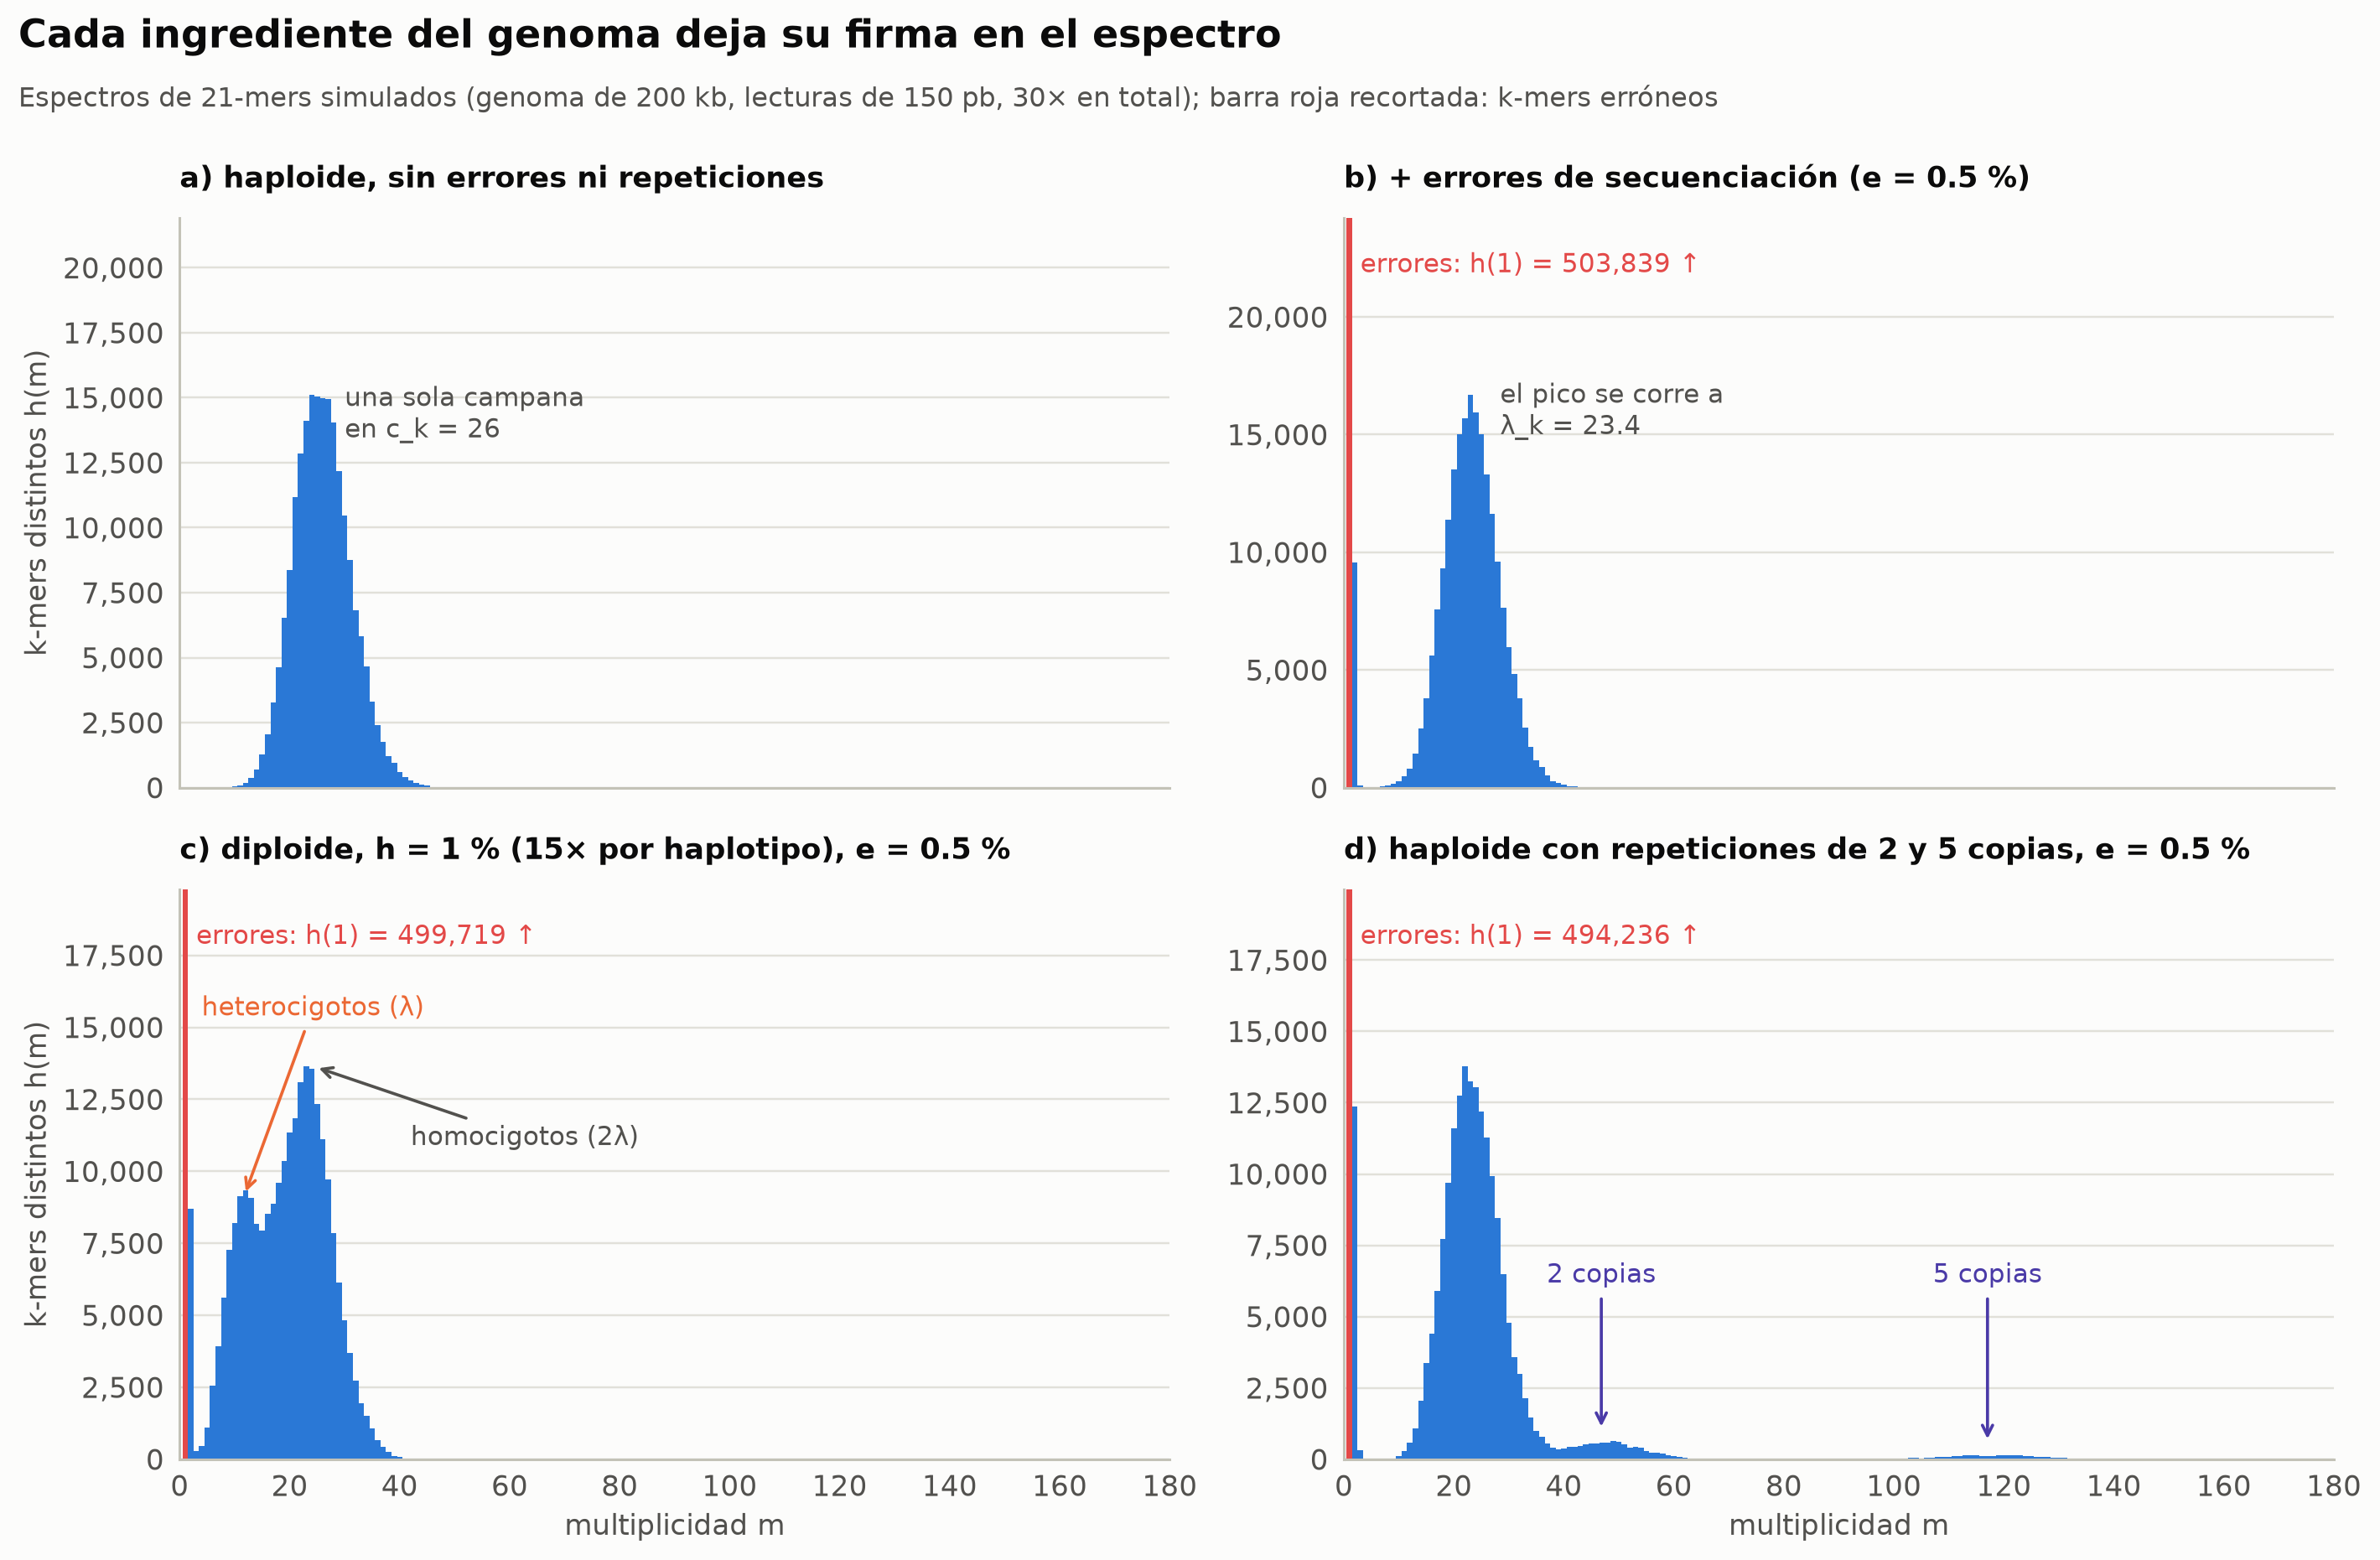

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.8), sharex=True)
lam30 = 30 * 130 / 150
for ax, (name, hs) in zip(axes.ravel(), scenarios.items()):
    m_ = np.arange(1, 181)
    y = np.zeros(180); y[:min(180, len(hs) - 1)] = hs[1:181]
    genomic_max = y[5:].max()
    ax.bar(m_, y, width=1.0, color=ec.BLUE, lw=0)
    ax.set_ylim(0, genomic_max * 1.45)
    if y[0] > genomic_max * 1.45:
        ax.bar(1, genomic_max * 1.45, width=1.0, color=ec.RED)
        ax.text(3, genomic_max * 1.33, f"errores: h(1) = {y[0]:,.0f} ↑", color=ec.RED, fontsize=10, va="center")
    ax.set_title(name, loc="left", fontsize=11.5)
    ax.set_xlim(0, 180)
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, p: f"{v:,.0f}"))
axes[0, 0].text(lam30 + 4, scenarios["a) haploide, sin errores ni repeticiones"][int(lam30)] * 0.9,
                f"una sola campana\nen c_k = {lam30:.0f}", fontsize=10, color=ec.INK_2)
lam_e = lam30 * 0.995 ** 21
axes[0, 1].text(lam_e + 5, scenarios["b) + errores de secuenciación (e = 0.5 %)"][int(lam_e)] * 0.9,
                f"el pico se corre a\nλ_k = {lam_e:.1f}", fontsize=10, color=ec.INK_2)
hc = scenarios["c) diploide, h = 1 % (15× por haplotipo), e = 0.5 %"]
axes[1, 0].annotate("heterocigotos (λ)", (lam_e / 2, hc[int(lam_e / 2)]), xytext=(4, hc[5:].max() * 1.13),
                    fontsize=10, color=ec.ORANGE, arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.ORANGE))
axes[1, 0].annotate("homocigotos (2λ)", (lam_e + 1, hc[int(lam_e)]), xytext=(42, hc[int(lam_e)] * 0.8),
                    fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.INK_2))
hd = scenarios["d) haploide con repeticiones de 2 y 5 copias, e = 0.5 %"]
for r_, lab in [(2, "2 copias"), (5, "5 copias")]:
    x_ = r_ * lam_e
    axes[1, 1].annotate(lab, (x_, hd[int(x_)] + hd[5:].max() * 0.03), xytext=(x_, hd[5:].max() * 0.45),
                        ha="center", fontsize=10, color=ec.VIOLET, arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.VIOLET))
for ax in axes[1]:
    ax.set_xlabel("multiplicidad m")
for ax in axes[:, 0]:
    ax.set_ylabel("k-mers distintos h(m)")
ec.fig_title(fig, "Cada ingrediente del genoma deja su firma en el espectro",
             "Espectros de 21-mers simulados (genoma de 200 kb, lecturas de 150 pb, 30× en total); barra roja recortada: k-mers erróneos")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.**
> * **a)** Sin errores ni repeticiones, el espectro es una campana limpia en $c_k = 26$ con área $\approx G$.
> * **b)** Un 0.5 % de errores basta para que los $k$-mers **distintos** con $m \le 3$ sean la gran mayoría (más del 70 %),
>   aunque son sólo el 10 % de los **leídos**. Es la firma más llamativa del espectro y la más fácil de separar: un valle
>   profundo la aísla del pico genómico, que además se corre de 26 a 23.4.
> * **c)** En el diploide aparece un **segundo pico** a la mitad de la cobertura: los $k$-mers que tocan un sitio
>   heterocigoto. Con sólo 1 % de sitios distintos, el pico heterocigoto ya es casi la mitad de alto que el homocigoto
>   (veremos por qué en la sección 5).
> * **d)** Las repeticiones forman picos pequeños en **múltiplos enteros** de la cobertura: 2λ y 5λ.

### 4.3 Cómo emergen los picos al secuenciar más

Un espectro con poca cobertura es engañoso: los picos genómicos se confunden con los errores. La animación siguiente
simula un genoma diploide de 100 kb ($h = 1\,\%$, $e = 0.5\,\%$) y añade lecturas poco a poco, de $1\times$ a
$25\times$ por haplotipo.

![Al aumentar la cobertura de 1× a 25× por haplotipo, los picos heterocigoto (λ) y homocigoto (2λ) se separan del muro de errores y se desplazan hacia la derecha, siempre en la proporción 1:2](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.1_cobertura_picos.gif)

*Al aumentar la cobertura de 1× a 25× por haplotipo, los picos heterocigoto (λ) y homocigoto (2λ) se separan del muro de errores y se desplazan hacia la derecha, siempre en la proporción 1:2*

In [13]:
G5 = 100_000
hapA5 = rng.integers(0, 4, G5).astype(np.uint8)
hapB5 = hapA5.copy()
s5 = rng.random(G5) < 0.01
hapB5[s5] = (hapB5[s5] + rng.integers(1, 4, s5.sum())) % 4
R5 = np.vstack([simulate_reads(hapA5, 25, err=0.005), simulate_reads(hapB5, 25, err=0.005)])
R5 = R5[rng.permutation(len(R5))]                 # mezclar: cada prefijo es una muestra al azar de ambos haplotipos
codes5 = count_codes(R5, 21)                       # 130 k-mers por lectura, en el orden de las lecturas
u5, inv5 = np.unique(codes5, return_inverse=True)  # se ordena UNA sola vez; cada cuadro sólo usa bincount
covs = np.round(np.geomspace(1, 25, 36), 2)
n_reads_frame = [int(c * 2 * G5 / 150) for c in covs]

fig, ax = plt.subplots(figsize=(11.5, 4.9))
final_cnt = np.bincount(inv5, minlength=len(u5))
final_h = np.bincount(final_cnt)
ymax = final_h[8:].max() * 1.5

def update(f):
    ax.clear()
    fi = min(f, len(covs) - 1)
    cnt = np.bincount(inv5[:n_reads_frame[fi] * 130], minlength=len(u5))
    hh = np.bincount(cnt[cnt > 0], minlength=91)[:91]
    ms_ = np.arange(1, 91)
    ax.bar(ms_, np.minimum(hh[1:], ymax), width=1.0, color=np.where(ms_ <= 3, ec.RED, ec.BLUE), lw=0)
    if hh[1] > ymax:
        ax.text(89, ymax * 0.93, f"barras rojas (m ≤ 3) recortadas · errores: h(1) = {hh[1]:,}",
                color=ec.RED, fontsize=10.5, ha="right")
    lam = covs[fi] * 130 / 150 * 0.995 ** 21
    for x_, lab, col, yy in [(lam, "λ", ec.ORANGE, 0.8), (2 * lam, "2λ", ec.INK_2, 0.7)]:
        ax.axvline(x_, color=col, ls="--", lw=1.1)
        ax.text(x_ + 0.6, ymax * yy, lab, color=col, fontsize=12)
    ax.set_xlim(0, 90); ax.set_ylim(0, ymax)
    ax.set_xlabel("multiplicidad m"); ax.set_ylabel("k-mers distintos h(m)")
    ax.set_title(f"Cobertura {covs[fi]:.1f}× por haplotipo ({2 * covs[fi]:.0f}× en total): "
                 f"{n_reads_frame[fi]:,} lecturas", loc="left", fontsize=12.5)
    return []

ec.animate(fig, update, frames=len(covs) + 4, interval=260, name="8.1_cobertura_picos")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Por debajo de unos $5\times$ por haplotipo no hay picos: todo es una pendiente que baja desde
> $m = 1$, y ningún programa podría separar errores de $k$-mers verdaderos. Al crecer la cobertura, el pico heterocigoto
> y el homocigoto se desprenden, se separan y avanzan hacia la derecha a velocidades distintas (uno a $\lambda$, el otro
> a $2\lambda$). Por eso GenomeScope recomienda al menos $\sim 15$–$25\times$ para un perfil fiable. El muro de errores
> también crece, pero **se queda en su sitio**, en $m \le 3$.

## 5. Un modelo para el espectro de un diploide

### 5.1 ¿Cuántos $k$-mers tocan un sitio heterocigoto?

Formalicemos la heterocigosidad, que es la parte más útil del modelo. Sea $h$ la **tasa de heterocigosidad**: la
probabilidad de que una posición del genoma difiera entre los dos haplotipos (el cromosoma heredado de la madre y el del
padre). Sea $\lambda$ la cobertura efectiva de $k$-mers **por haplotipo**, de modo que un $k$-mer presente en los dos
haplotipos se lee en promedio $2\lambda$ veces.

Piense en una ventana de $k$ letras que se desliza por el genoma. La ventana es «homocigota» sólo si **ninguna** de sus
$k$ posiciones es heterocigota. Cada posición lo evita con probabilidad $1-h$; las $k$ a la vez, con $(1-h)^k$. Así,

> **Teorema (espectro de un genoma diploide).** Un $k$-mer del genoma cubre al menos un sitio heterocigoto con
> probabilidad

$$
\alpha = 1-(1-h)^k \qquad\text{(ecuación 08-alfa)}
$$

> Si el genoma haploide tiene $G$ posiciones, hay en promedio $G(1-\alpha)$ $k$-mers **homocigotos**, con multiplicidad
> media $2\lambda$, y $2G\alpha$ $k$-mers **heterocigotos** (uno por haplotipo), con multiplicidad media $\lambda$.
> Ignorando repeticiones, el espectro es la mezcla

$$
h(m) \;\approx\; h_{\text{err}}(m) \;+\; 2G\alpha\; f(m;\lambda) \;+\; G(1-\alpha)\; f(m;2\lambda)
\qquad\text{(ecuación 08-mezcla)}
$$

> donde $f(\,\cdot\,;\mu)$ es una distribución de conteo de media $\mu$ (Poisson o, más realista, binomial negativa).

| Símbolo | Significado |
|---|---|
| $h$ | Tasa de heterocigosidad: fracción de sitios que difieren entre los dos haplotipos |
| $\alpha$ | Fracción de posiciones cuyo $k$-mer contiene al menos un sitio heterocigoto |
| $\lambda$ | Cobertura efectiva de $k$-mers de un haplotipo (el pico «$1\times$») |
| $h_{\text{err}}(m)$ | Contribución de los $k$-mers erróneos, concentrada en $m$ pequeños |
| $f(m;\mu)$ | Probabilidad de observar $m$ copias cuando la media es $\mu$ |

> ⚠️ **Dos «$h$» distintas.** Siguiendo al libro, $h(m)$ (con argumento) es el espectro y $h$ (sola) es la
> heterocigosidad. El contexto siempre las distingue.

**Ejemplo a mano.** Con $h = 1\,\%$ y $k = 21$: $\alpha = 1 - 0.99^{21} = 1 - 0.810 = 0.19$. **Casi uno de cada cinco
$k$-mers es heterocigoto**, aunque sólo uno de cada cien sitios lo es: cada SNP «contamina» las $k = 21$ ventanas que lo
contienen. Y como cada posición heterocigota aporta **dos** $k$-mers distintos (uno por alelo), el pico de $\lambda$
contiene $2G\alpha = 0.38\,G$ $k$-mers frente a $G(1-\alpha) = 0.81\,G$ del de $2\lambda$: **alrededor de la mitad**.

¿Por qué binomial negativa y no Poisson? La Poisson obliga a que la varianza sea igual a la media. En datos reales la
cobertura fluctúa más (sesgo por contenido GC, amplificación por PCR, regiones difíciles), y la binomial negativa
añade un parámetro de **sobredispersión** $r$: varianza $= \mu + \mu^2/r$. Cuando $r \to \infty$ vuelve a ser Poisson.

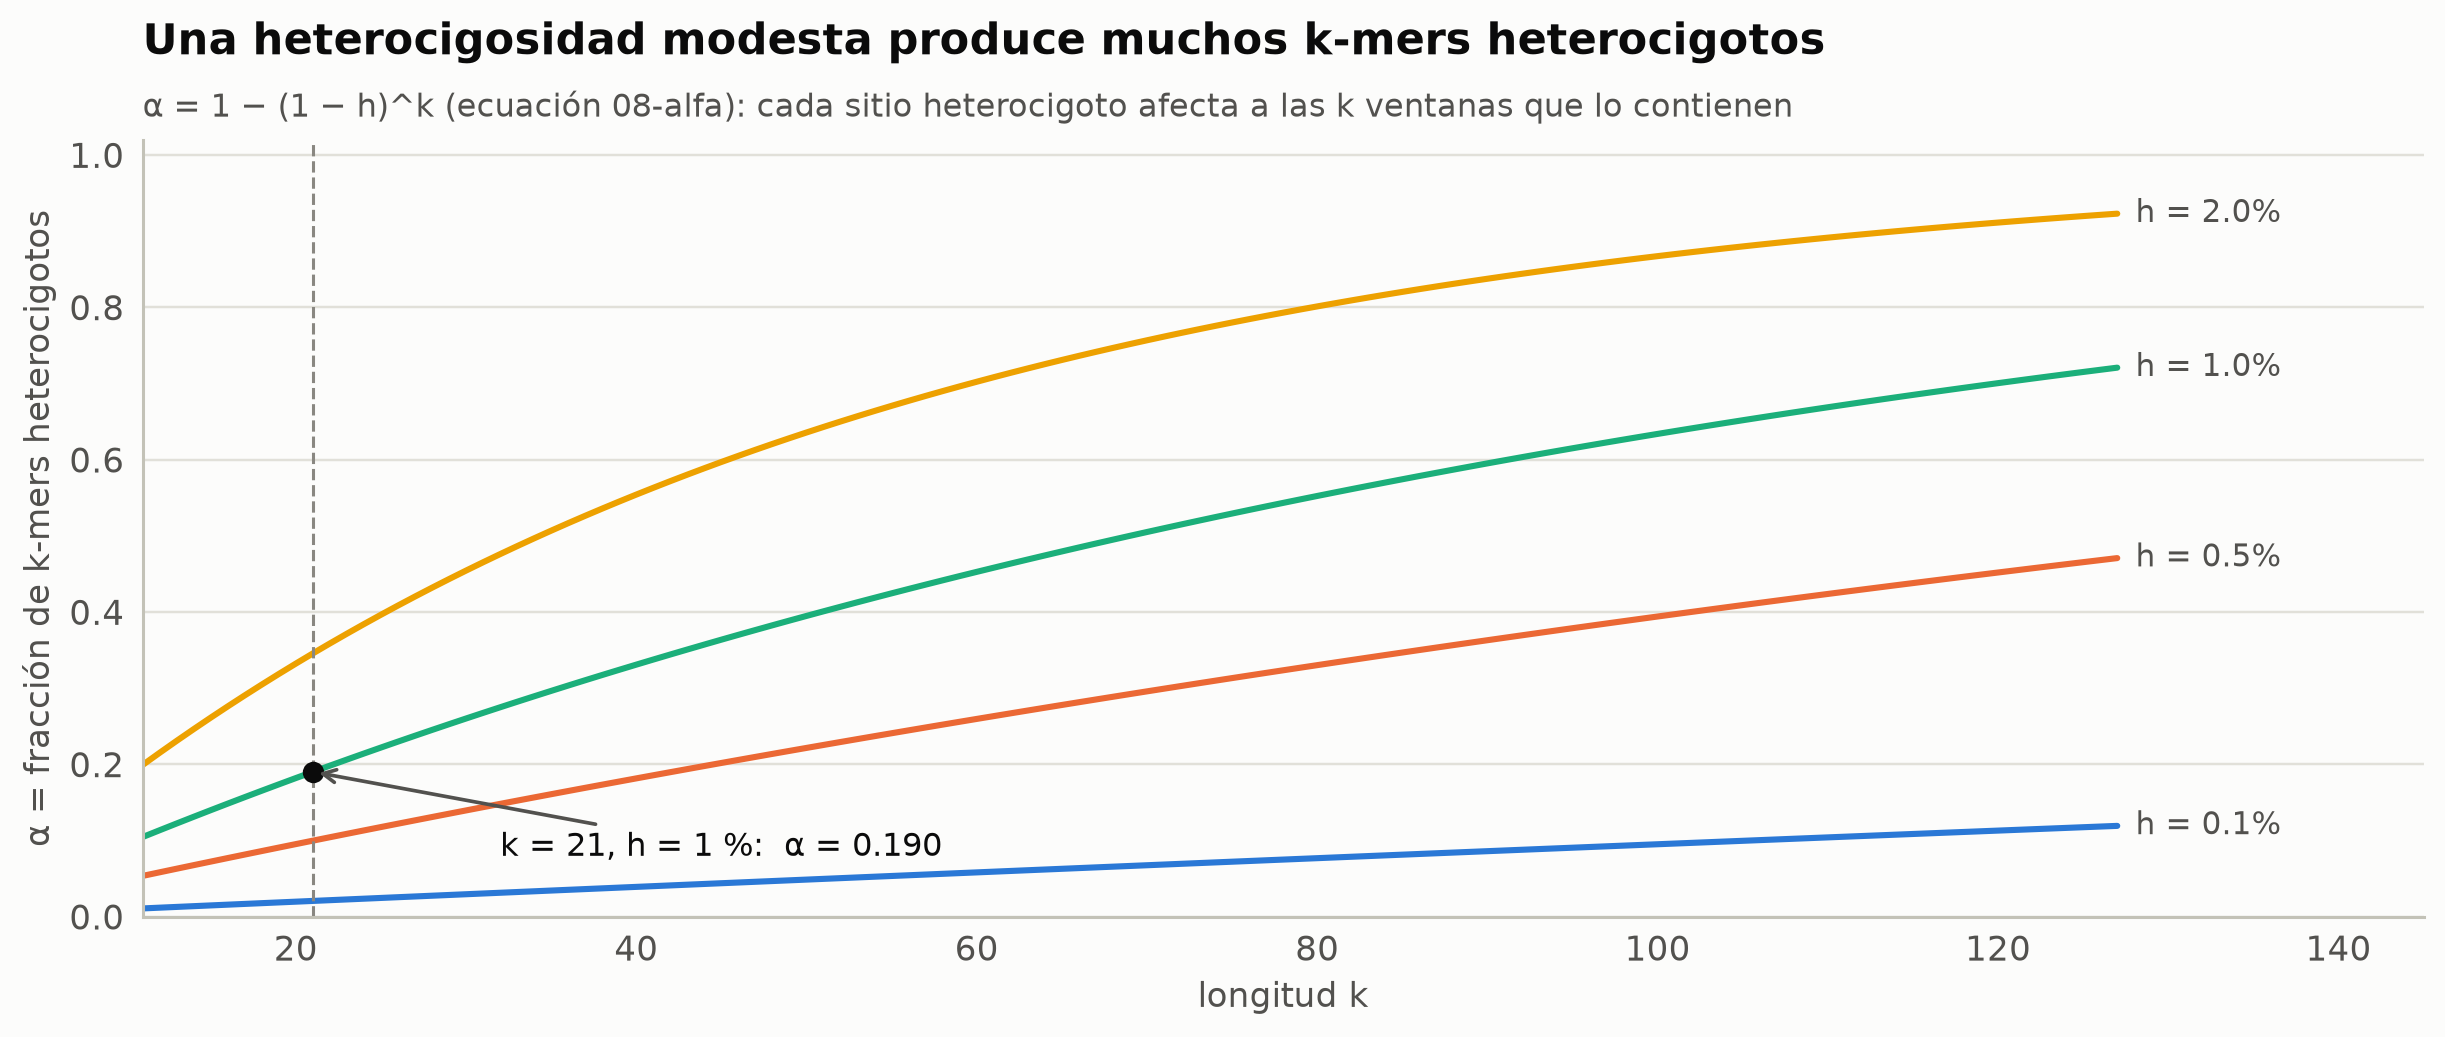

In [14]:
ks = np.arange(11, 128)
fig, ax = plt.subplots(figsize=(11, 4.6))
for hh_, col in zip([0.001, 0.005, 0.01, 0.02], ec.CATEGORICAL):
    a_ = 1 - (1 - hh_) ** ks
    ax.plot(ks, a_, color=col, lw=2)
    ec.label_end(ax, ks[-1], a_[-1], f"h = {hh_:.1%}")
ax.axvline(21, color=ec.MUTED, ls="--", lw=1)
ax.plot([21], [1 - 0.99 ** 21], "o", color=ec.INK, ms=6)
ax.annotate(f"k = 21, h = 1 %:  α = {1 - 0.99 ** 21:.3f}", (21, 1 - 0.99 ** 21), xytext=(32, 0.08),
            fontsize=10.5, color=ec.INK, arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.INK_2))
ax.set_xlim(11, 145); ax.set_ylim(0, 1.02)
ax.set_xlabel("longitud k"); ax.set_ylabel("α = fracción de k-mers heterocigotos")
ec.title(ax, "Una heterocigosidad modesta produce muchos k-mers heterocigotos",
         "α = 1 − (1 − h)^k (ecuación 08-alfa): cada sitio heterocigoto afecta a las k ventanas que lo contienen")
plt.show()

> 🔎 **Qué observamos.** El efecto crece con $k$: una palabra más larga tiene más oportunidades de tocar un sitio
> variable. Con $h = 1\,\%$ y $k = 77$ (un valor que usa SPAdes), más de la mitad de los $k$-mers ya son heterocigotos.
> Por eso los genomas muy heterocigotos (ostras, muchas plantas, insectos silvestres) son tan difíciles de ensamblar.

### 5.2 La masa del espectro da el tamaño del genoma

El modelo contiene un resultado de gran belleza práctica. Calculemos la **masa** total de los $k$-mers verdaderos (los
que no son errores): cada grupo aporta «número de $k$-mers × veces que se lee cada uno»:

$$
\underbrace{G(1-\alpha)\cdot 2\lambda}_{\text{homocigotos}} \;+\; \underbrace{2G\alpha\cdot\lambda}_{\text{heterocigotos}}
\;=\; 2G\lambda
\quad\Longrightarrow\quad
\widehat{G} \;=\; \frac{\sum_{m\ge v} m\,h(m)}{2\lambda}
\qquad\text{(ecuación 08-masa)}
$$

**La heterocigosidad $\alpha$ se cancela.** Basta sumar el espectro por encima del **valle** $v$ que lo separa de los
errores y dividir por la multiplicidad del pico homocigoto, $2\lambda$. Las repeticiones tampoco estorban: un $k$-mer con
$r$ copias aporta $r$ veces más masa, exactamente lo que le corresponde. Para un organismo **haploide** (como una
bacteria), el denominador es simplemente la posición del único pico, $\lambda$.

Es la cuenta de las fotocopias del principio: total de frases de la caja dividido por el número de fotocopias.

### 5.3 La heterocigosidad sale de los tamaños de los picos

Si ajustamos la mezcla y obtenemos los tamaños de los dos componentes, $N_{\text{het}} \approx 2G\alpha$ y
$N_{\text{hom}} \approx G(1-\alpha)$, despejamos

$$
\widehat{\alpha} = \frac{N_{\text{het}}}{N_{\text{het}} + 2N_{\text{hom}}},
\qquad
\widehat{h} = 1-(1-\widehat{\alpha})^{1/k}
\qquad\text{(ecuación 08-het)}
$$

| Símbolo | Significado |
|---|---|
| $v$ | Multiplicidad del valle entre el pico de errores y el primer pico genómico |
| $\widehat{G}$ | Tamaño estimado del genoma haploide |
| $N_{\text{het}},\ N_{\text{hom}}$ | Número de $k$-mers distintos asignados a cada componente del ajuste |

Comprobación rápida con los valores esperados: $N_{\text{het}} = 2G\alpha$ y $N_{\text{hom}} = G(1-\alpha)$ dan
$\frac{2G\alpha}{2G\alpha + 2G(1-\alpha)} = \alpha$. ✔

Este es, en esencia, el modelo de **GenomeScope** (Vurture *et al.*, 2017), que ajusta por mínimos cuadrados no
lineales una mezcla de binomiales negativas en $\lambda$, $2\lambda$, $3\lambda$ y $4\lambda$ (estas últimas para
capturar las repeticiones de dos copias) y devuelve el tamaño, la heterocigosidad, la fracción repetitiva y la tasa de
error a partir de lecturas sin procesar. **GenomeScope 2.0** (Ranallo-Benavidez *et al.*, 2020) generalizó el modelo a
poliploides y lo acompañó de **Smudgeplot**, que estima la ploidía a partir de pares de $k$-mers heterocigotos.

### 5.4 🧪 La simulación del libro, paso a paso

Reproducimos **exactamente** el experimento del libro (misma semilla, mismo orden de sorteos, así que obtendremos las
mismas cifras):

| Parámetro | Valor |
|---|---|
| Genoma haploide $G$ | 1 000 000 pb, con 15 duplicaciones segmentarias de 2 kb |
| Heterocigosidad $h$ | 1 % (sitios que difieren entre haplotipos A y B) |
| Lecturas | $L = 150$ pb, $20\times$ **por haplotipo**, hebra al azar |
| Tasa de error $e$ | 0.5 % por base (sustituciones) |
| $k$ | 21 |

Contamos casi 35 millones de $k$-mers con la codificación de 2 bits en NumPy. Tarda unos segundos.

> 🤔 **Antes de ejecutar, prediga.** ¿Dónde estará el pico homocigoto? *(Pista: $2\lambda$ con $\lambda$ de la ecuación
> 08-ck y 20× por haplotipo.)* ¿Qué altura relativa tendrá el pico heterocigoto?

In [15]:
t0 = time.time()
rng_sim = np.random.default_rng(8)                 # la semilla del libro (figuras/cap08/generar.py)
G, K, L = 1_000_000, 21, 150
HET, ERR, COV_HAP = 0.01, 0.005, 20
genA = rng_sim.integers(0, 4, G).astype(np.uint8)
ndup, ldup = 15, 2000                              # duplicaciones segmentarias: 15 segmentos de 2 kb copiados
src = rng_sim.choice(G - ldup, ndup, replace=False)
dst = rng_sim.choice(G - ldup, ndup, replace=False)
for s_, d_ in zip(src, dst):
    genA[d_:d_ + ldup] = genA[s_:s_ + ldup]
genB = genA.copy()                                 # haplotipo B = A con 1 % de sitios cambiados
snp = rng_sim.random(G) < HET
genB[snp] = (genB[snp] + rng_sim.integers(1, 4, snp.sum())) % 4

codes_sim = np.concatenate([count_codes(simulate_reads(gen, COV_HAP, L, ERR, rng=rng_sim), K)
                            for gen in (genA, genB)])
_, cnt_sim = np.unique(codes_sim, return_counts=True)
hist_sim = np.bincount(cnt_sim, minlength=122)
print(f"SNPs: {snp.sum():,} · k-mers leídos: {codes_sim.size:,} · distintos: {cnt_sim.size:,} "
      f"· con multiplicidad 1: {hist_sim[1]:,}")
print(f"Tiempo de simulación y conteo: {time.time() - t0:.1f} s")
del codes_sim                                      # liberar ~280 MB

SNPs: 9,952 · k-mers leídos: 34,666,580 · distintos: 4,535,463 · con multiplicidad 1: 3,297,024
Tiempo de simulación y conteo: 3.4 s


Ahora el ajuste, al estilo de GenomeScope, con `scipy.optimize.least_squares`:

1. **Valle** $v$: el mínimo de $h(m)$ entre el muro de errores y el primer pico (buscamos en $m = 3, \dots, 12$).
2. **Modelo**: $a_1 f(m;\lambda) + a_2 f(m;2\lambda) + a_3 f(m;3\lambda) + a_4 f(m;4\lambda)$ con $f$ binomial negativa de
   media $\mu$ y sobredispersión $r$ común. Seis parámetros: $\lambda, a_1, a_2, a_3, a_4, r$. Aquí $a_1 = N_{\text{het}}$
   y $a_2 = N_{\text{hom}}$.
3. **Residuos ponderados** $(\text{modelo} - h(m))/\sqrt{h(m) + 10}$, para que los picos altos no dominen el ajuste
   (el error de un conteo crece como su raíz cuadrada).

In [16]:
def nbinom_pmf(m, mu, r):
    """Binomial negativa parametrizada por la media mu y la sobredispersión r (varianza = mu + mu²/r)."""
    return stats.nbinom.pmf(m, r, r / (r + mu))

def mixture(par, m):
    """Mezcla de binomiales negativas en λ, 2λ, 3λ y 4λ (modelo del libro / GenomeScope)."""
    lam, a1, a2, a3, a4, r = par
    return (a1 * nbinom_pmf(m, lam, r) + a2 * nbinom_pmf(m, 2 * lam, r)
            + a3 * nbinom_pmf(m, 3 * lam, r) + a4 * nbinom_pmf(m, 4 * lam, r))

M = 100
mm = np.arange(1, M + 1)
h_obs = hist_sim[1:M + 1].astype(float)            # h_obs[i] = h(i + 1)
valley = int(np.argmin(h_obs[2:12])) + 3           # mínimo de h(m) para m = 3..12
lam_theo = COV_HAP * (L - K + 1) / L
sel = mm >= valley
par0 = [lam_theo * 0.9, h_obs[sel].max() * 10, h_obs[sel].max() * 30, 1e3, 1e3, 20]
fit = optimize.least_squares(lambda p: (mixture(p, mm[sel]) - h_obs[sel]) / np.sqrt(h_obs[sel] + 10), par0,
                             bounds=([5, 0, 0, 0, 0, 1], [40, 1e8, 1e8, 1e8, 1e8, 1e4]))
lam, N_het, N_hom, N3, N4, r_nb = fit.x
alpha_hat = N_het / (N_het + 2 * N_hom)
h_hat = 1 - (1 - alpha_hat) ** (1 / K)
mass_true = (mm[sel] * h_obs[sel]).sum() + sum(m * hist_sim[m] for m in range(M + 1, len(hist_sim)))
G_hat = mass_true / (2 * lam)

book = {"valle v": (valley, 4), "h(v)": (hist_sim[valley], 166), "λ ajustada": (lam, 15.60), "N_het": (N_het, 367_251), "N_hom": (N_hom, 765_306),
        "masa Σ_{m≥v} m h(m)": (mass_true, 31_213_016), "Ĝ (pb)": (G_hat, 1_000_409),
        "α̂": (alpha_hat, 0.1935), "ĥ (%)": (100 * h_hat, 1.02)}
print(f"{'cantidad':22s} {'este cuaderno':>16s} {'libro':>14s}")
for k_, (v_, b_) in book.items():
    fmt = "{:,.0f}" if abs(b_) > 100 else "{:.4g}"
    print(f"{k_:22s} {fmt.format(v_):>16s} {fmt.format(b_):>14s}")
print(f"\nTeoría: λ = {lam_theo:.2f} × 0.995^21 = {lam_theo * (1 - ERR) ** K:.2f} · α = 1 − 0.99^21 = {1 - 0.99 ** K:.4f}")
print(f"Sobredispersión ajustada r = {r_nb:,.0f} (el límite superior): la simulación es Poisson, sin sesgos de cobertura")

cantidad                  este cuaderno          libro
valle v                               4              4
h(v)                                166            166
λ ajustada                         15.6           15.6
N_het                           367,251        367,251
N_hom                           765,306        765,306
masa Σ_{m≥v} m h(m)          31,213,016     31,213,016
Ĝ (pb)                        1,000,409      1,000,409
α̂                               0.1935         0.1935
ĥ (%)                             1.019           1.02

Teoría: λ = 17.33 × 0.995^21 = 15.60 · α = 1 − 0.99^21 = 0.1903
Sobredispersión ajustada r = 10,000 (el límite superior): la simulación es Poisson, sin sesgos de cobertura


> 🔎 **Qué observamos.** Coincidimos con el libro cifra a cifra. Repasemos el **perfil del genoma** como lo haría un
> analista, sin haber alineado una sola lectura:
>
> 1. **Valle** en $v = 4$, con $h(4) = 166$ $k$-mers: casi nada entre el pico de errores y el genómico.
> 2. **Cobertura.** El ajuste da $\lambda = 15.60$. La ecuación 08-ck predice $20 \times \frac{130}{150} \times 0.995^{21}
>    = 17.33 \times 0.900 = 15.60$: la coincidencia confirma que el desplazamiento del pico respecto de $c_k$ se debe a
>    los errores.
> 3. **Tamaño.** $\widehat{G} = 31\,213\,016 / (2 \times 15.60) = 1\,000\,409$ pb, a menos de un 0.05 % del valor real.
> 4. **Heterocigosidad.** $\widehat{\alpha} = 367\,251 / (367\,251 + 2 \times 765\,306) = 0.1935$ y
>    $\widehat{h} = 1 - (1 - 0.1935)^{1/21} = 1.02\,\%$, frente al 1.00 % simulado.
>
> La sobredispersión $r$ quedó en su tope (10 000): la binomial negativa se volvió Poisson, porque la simulación toma
> los inicios de lectura de forma perfectamente uniforme. **Recuerde este detalle**: con los datos reales (sección 7)
> $r$ será pequeño y eso tendrá consecuencias.

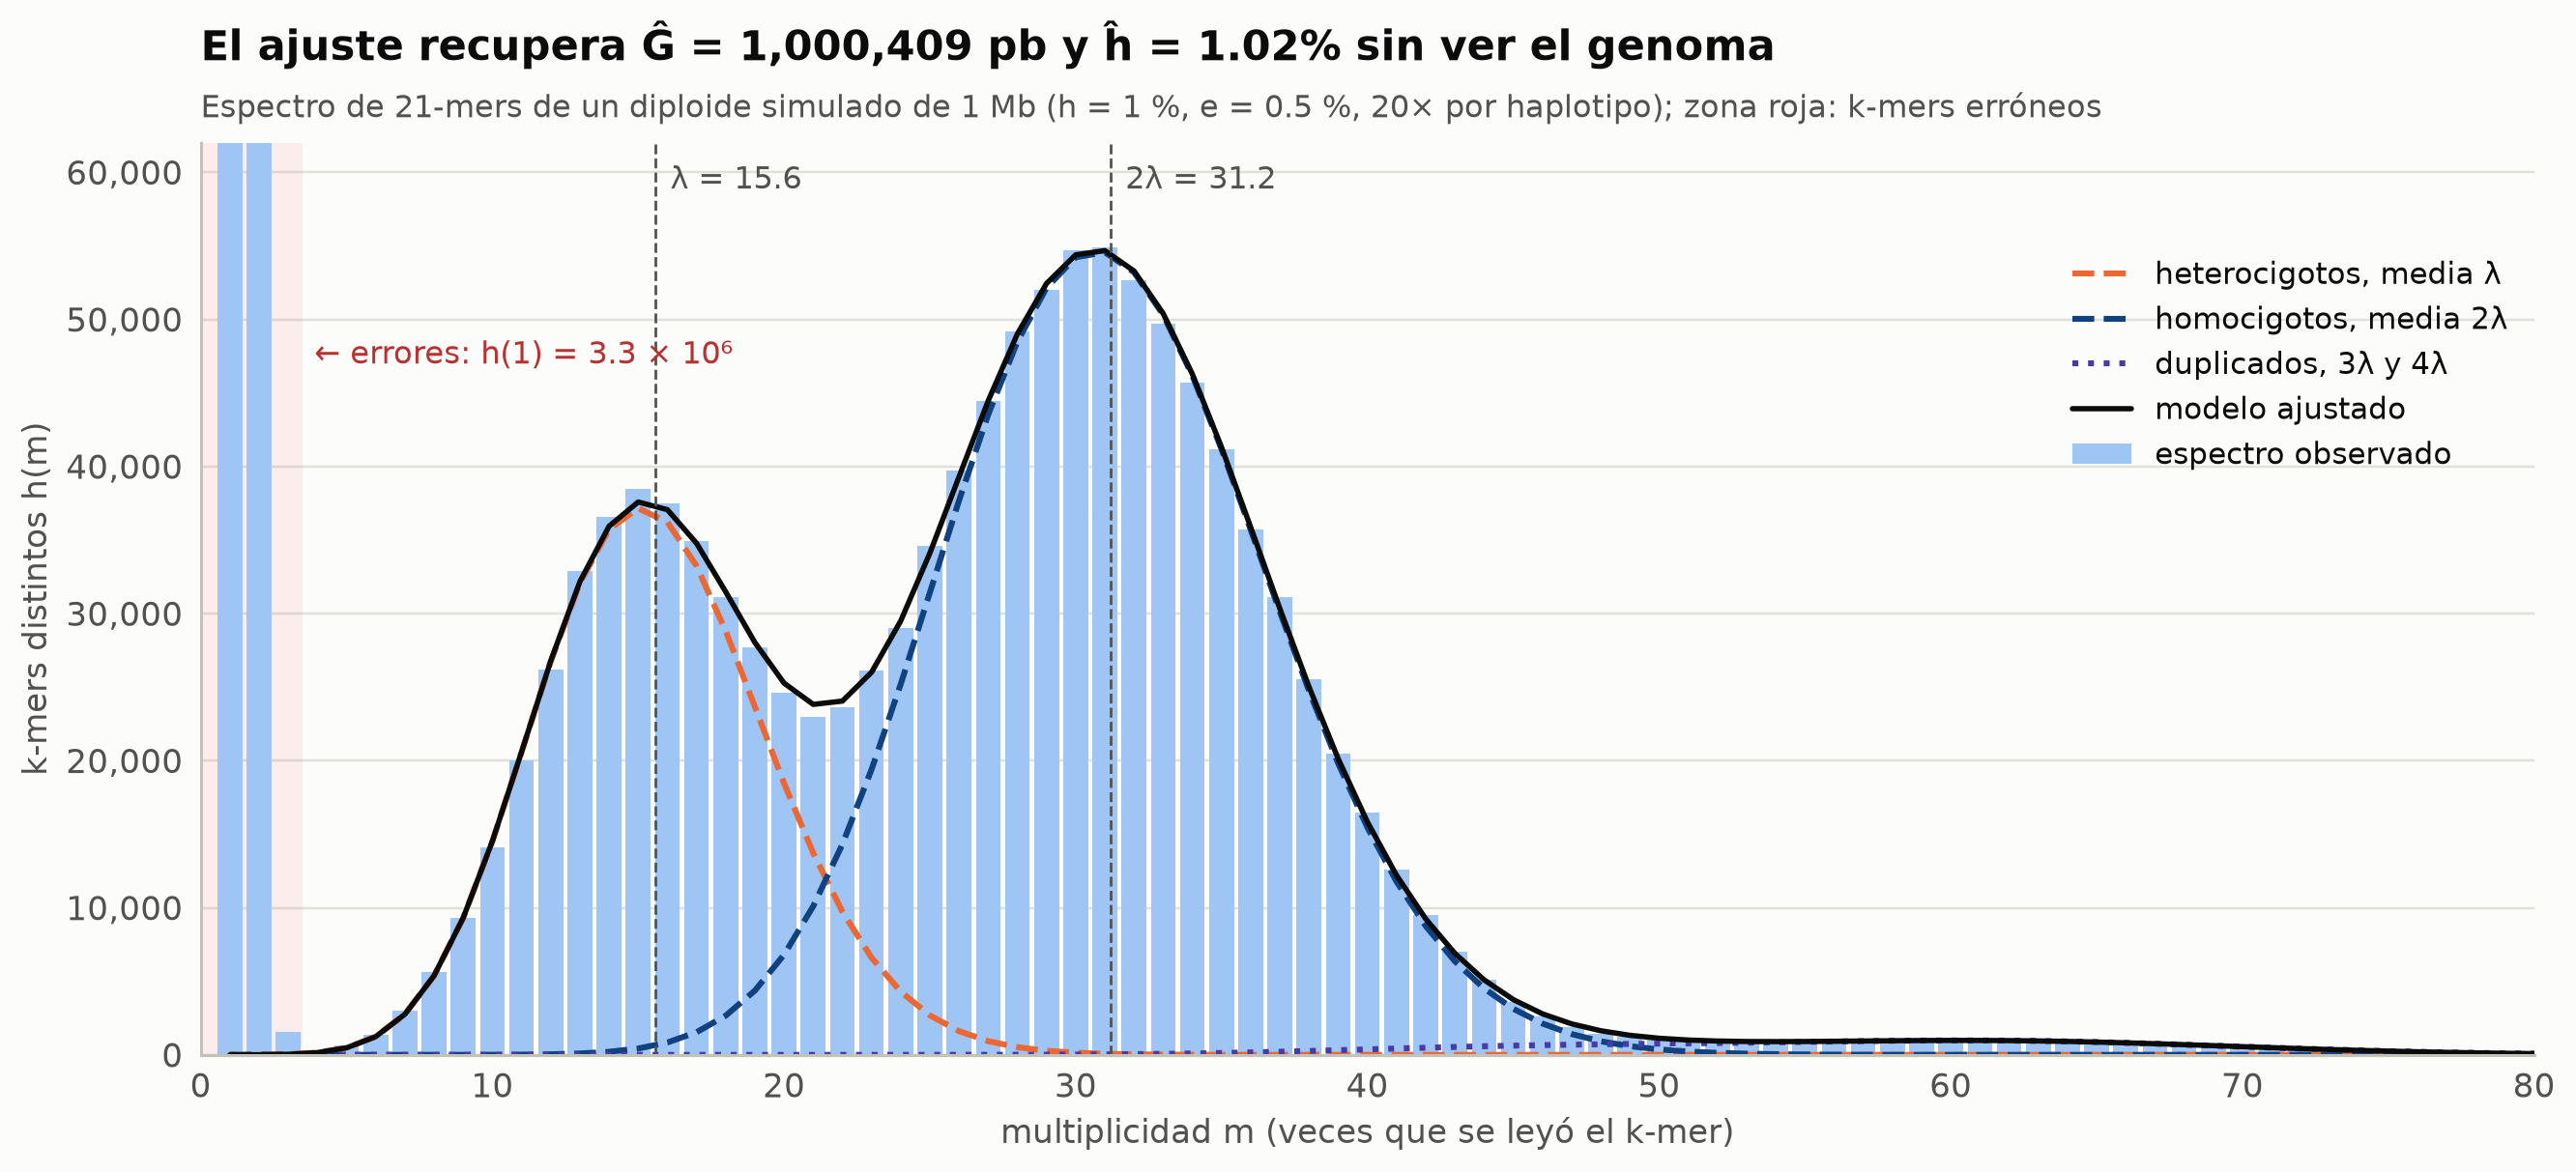

In [17]:
comp_het = N_het * nbinom_pmf(mm, lam, r_nb)
comp_hom = N_hom * nbinom_pmf(mm, 2 * lam, r_nb)
comp_dup = N3 * nbinom_pmf(mm, 3 * lam, r_nb) + N4 * nbinom_pmf(mm, 4 * lam, r_nb)
model_all = mixture(fit.x, mm)

fig, ax = plt.subplots(figsize=(12, 5.4))
ax.axvspan(0, valley - 0.5, color=ec.RED, alpha=0.08, lw=0)
ax.bar(mm, h_obs, width=0.85, color="#9ec5f4", lw=0, label="espectro observado")
ax.plot(mm, comp_het, color=ec.ORANGE, lw=2, ls="--", label="heterocigotos, media λ")
ax.plot(mm, comp_hom, color="#104281", lw=2, ls="--", label="homocigotos, media 2λ")
ax.plot(mm, comp_dup, color=ec.VIOLET, lw=2, ls=":", label="duplicados, 3λ y 4λ")
ax.plot(mm, model_all, color=ec.INK, lw=1.8, label="modelo ajustado")
for x_, lab in [(lam, f"λ = {lam:.1f}"), (2 * lam, f"2λ = {2 * lam:.1f}")]:
    ax.axvline(x_, color=ec.INK_2, ls="--", lw=0.9)
    ax.text(x_ + 0.5, 60_500, lab, fontsize=10.5, color=ec.INK_2, va="top")
ax.text(3.9, 47_000, f"← errores: h(1) = {hist_sim[1] / 1e6:.1f} × 10⁶", color="#b8302f", fontsize=10.5)
ax.set_xlim(0, 80); ax.set_ylim(0, 62_000)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, p: f"{v:,.0f}"))
ax.set_xlabel("multiplicidad m (veces que se leyó el k-mer)"); ax.set_ylabel("k-mers distintos h(m)")
ax.legend(loc="upper right", frameon=False, bbox_to_anchor=(1.0, 0.9))
ec.title(ax, f"El ajuste recupera Ĝ = {G_hat:,.0f} pb y ĥ = {h_hat:.2%} sin ver el genoma",
         "Espectro de 21-mers de un diploide simulado de 1 Mb (h = 1 %, e = 0.5 %, 20× por haplotipo); zona roja: k-mers erróneos")
plt.show()

La misma figura, interactiva. Pase el cursor por cada barra: verá cuántos $k$-mers distintos hay con esa multiplicidad,
qué componente del modelo los explica y qué fracción de la **masa** aportan. Con los botones puede cambiar a escala
logarítmica para ver el muro de errores completo.

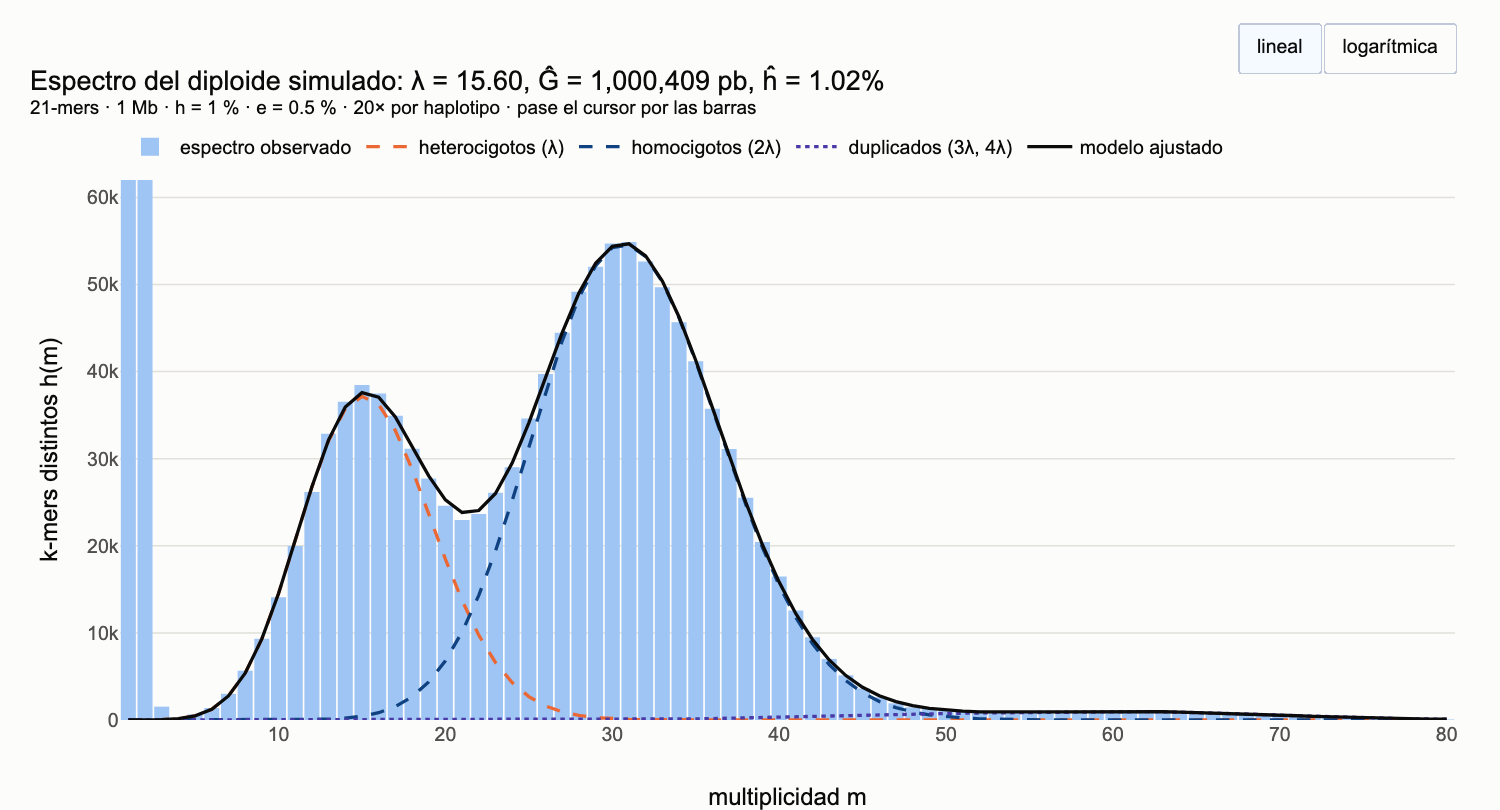

In [18]:
mm_plot = np.arange(1, 81)
obs80 = hist_sim[1:81].astype(float)
comps = np.vstack([comp_het[:80], comp_hom[:80], comp_dup[:80]])
names_c = ["heterocigotos (λ)", "homocigotos (2λ)", "duplicados (3λ, 4λ)"]
total_mass = (np.arange(len(hist_sim)) * hist_sim).sum()
dominant = []
for i, m_ in enumerate(mm_plot):
    if m_ < valley:
        dominant.append("errores de secuenciación: k-mers que no existen en el genoma")
    else:
        dominant.append(f"sobre todo {names_c[int(np.argmax(comps[:, i]))]} "
                        f"({comps[:, i].max() / max(model_all[i], 1e-9):.0%} del modelo)")
custom = np.column_stack([model_all[:80], 100 * mm_plot * obs80 / total_mass, dominant])
fig = go.Figure()
fig.add_bar(x=mm_plot, y=obs80, name="espectro observado", marker_color="#9ec5f4", customdata=custom,
            hovertemplate="<b>m = %{x}</b><br>h(m) = %{y:,.0f} k-mers distintos<br>modelo: %{customdata[0]:,.0f}"
                          "<br>masa de esta barra: %{customdata[1]:.2f} % de los k-mers leídos<br>%{customdata[2]}<extra></extra>")
for y_, nm, col, dash in [(comp_het, names_c[0], ec.ORANGE, "dash"), (comp_hom, names_c[1], "#104281", "dash"),
                          (comp_dup, names_c[2], ec.VIOLET, "dot"), (model_all, "modelo ajustado", ec.INK, "solid")]:
    fig.add_scatter(x=mm_plot, y=y_[:80], name=nm, mode="lines", line=dict(color=col, dash=dash, width=2.2),
                    hovertemplate=f"{nm}<br>m = %{{x}}: %{{y:,.0f}}<extra></extra>")
fig.update_layout(
    title=dict(text=f"Espectro del diploide simulado: λ = {lam:.2f}, Ĝ = {G_hat:,.0f} pb, ĥ = {h_hat:.2%}"
                    "<br><sup>21-mers · 1 Mb · h = 1 % · e = 0.5 % · 20× por haplotipo · pase el cursor por las barras</sup>"),
    xaxis_title="multiplicidad m", yaxis=dict(title="k-mers distintos h(m)", range=[0, 62_000]),
    height=540, margin=dict(t=120, l=80, r=30, b=60), bargap=0.1,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    updatemenus=[dict(type="buttons", direction="left", x=1.0, xanchor="right", y=1.2, yanchor="bottom",
                      buttons=[dict(label="lineal", method="relayout", args=[{"yaxis.type": "linear", "yaxis.range": [0, 62_000]}]),
                               dict(label="logarítmica", method="relayout", args=[{"yaxis.type": "log", "yaxis.range": [0, 6.8]}])])])
fig.show()

> 🔎 **Qué observamos.** En escala logarítmica se aprecia la verdadera dimensión del muro de errores: 3.3 millones de
> $k$-mers distintos en $m = 1$, frente a unos 57 000 en la cima del pico homocigoto. Sin embargo, la masa de
> todas las barras con $m < 4$ es sólo el 10 % de los $k$-mers leídos: **los errores son muchos en variedad, pocos en
> volumen.** Entre $m \approx 25$ y $m \approx 45$ domina el componente homocigoto; entre 8 y 22, el heterocigoto; y más
> allá de 50 sólo quedan los duplicados.

> ⚠️ **Cuidado: confundir los picos duplica el genoma.** Si la heterocigosidad es alta o la cobertura baja, el pico
> heterocigoto puede ser **más alto** que el homocigoto. Un análisis ingenuo que tome el pico más alto como «la
> cobertura» usará $\lambda$ en lugar de $2\lambda$ en la ecuación 08-masa y estimará un genoma del **doble** de tamaño.
> Con nuestros números: $31\,213\,016 / 15.60 = 2.0$ Mb en lugar de 1.0 Mb. Otros motivos de espectros engañosos son la
> contaminación (un tercer pico ajeno, a otra cobertura), la amplificación del genoma completo (picos anchos y
> deformados) y las muestras de varios individuos mezclados. **Mire siempre el espectro completo**, no sólo los números
> que devuelve el programa. (El Ejercicio 2 le pide provocar este error a propósito.)

> ✅ **Compruebe su comprensión.** Si repitiéramos la simulación con $h = 0.1\,\%$, ¿qué pasaría con el pico
> heterocigoto? *(Respuesta: $\alpha = 1 - 0.999^{21} = 0.021$; habría $2G\alpha \approx 42\,000$ $k$-mers
> heterocigotos repartidos en una campana ancha: un «hombro» apenas visible a la izquierda del pico homocigoto.)*

## 6. Contar miles de millones de $k$-mers

### 6.1 El problema es la escala

Contar $k$-mers parece trivial, y en principio lo es: basta un diccionario, como hicimos con las cuatro lecturas. El
problema es el tamaño. Hagamos la cuenta del libro para un genoma humano a $30\times$ con lecturas de 150 pb y $k = 31$:

| Magnitud | Cuenta | Valor |
|---|---|---|
| Lecturas | $N = cG/L = 30 \times 3.1\times10^9 / 150$ | $6.2 \times 10^8$ |
| $k$-mers leídos | $N(L-k+1) = 6.2\times10^8 \times 120$ | $\approx 8 \times 10^{10}$ |
| $k$-mers distintos (inflados por los errores) | | $> 5 \times 10^{9}$ |
| Memoria de un diccionario de Python (≈ 100–200 bytes por entrada) | | **cientos de GB** |

Midamos cuánto ocupa de verdad un `Counter` de Python con lecturas **reales**: las 34 000 parejas de SRR2584863 que
cayeron en la región 3 950 001–4 200 000 de REL606 (250 kb), que usaremos en la Lección 8.3 para ensamblar.

In [19]:
import tracemalloc
reg_seqs = (read_fastq_seqs("REL606_3950k-4200k_reads_1.fastq.gz")
            + read_fastq_seqs("REL606_3950k-4200k_reads_2.fastq.gz"))
print(f"Lecturas reales de la región: {len(reg_seqs):,} · longitudes: {sorted(set(map(len, reg_seqs)))}")

# 1) diccionario de Python con cadenas (sólo 5 000 lecturas: es lento)
sub = [s.decode() for s in reg_seqs[:5000]]
tracemalloc.start()
t0 = time.perf_counter()
cnt_dict = count_kmers(sub, k=21)
t_dict = time.perf_counter() - t0
mem_dict = tracemalloc.get_traced_memory()[0]
tracemalloc.stop()
bytes_per_entry = mem_dict / len(cnt_dict)
print(f"Counter de Python: {len(cnt_dict):,} k-mers distintos · {mem_dict / 1e6:.0f} MB "
      f"({bytes_per_entry:.0f} bytes por k-mer) · {5000 * 130 / t_dict / 1e6:.2f} millones de k-mers/s")
del cnt_dict

# 2) NumPy con enteros de 2 bits: TODAS las lecturas
t0 = time.perf_counter()
R_reg = LUT[np.frombuffer(b"".join(reg_seqs), dtype=np.uint8)].reshape(len(reg_seqs), 150)
codes_reg = count_codes(R_reg, 21)
u_reg, c_reg = np.unique(codes_reg, return_counts=True)
t_np = time.perf_counter() - t0
hist_reg = np.bincount(c_reg)
print(f"NumPy (2 bits, ordenar y contar): {codes_reg.size:,} k-mers leídos, {u_reg.size:,} distintos · "
      f"{codes_reg.size / t_np / 1e6:.1f} millones de k-mers/s · {12 * u_reg.size / 1e6:.0f} MB (8 + 4 bytes por k-mer)")
print(f"Proyección humana (5 × 10⁹ distintos): dict ≈ {5e9 * bytes_per_entry / 1e9:,.0f} GB · "
      f"enteros de 2 bits ≈ {5e9 * 12 / 1e9:,.0f} GB")

Lecturas reales de la región: 68,000 · longitudes: [150]


Counter de Python: 252,124 k-mers distintos · 23 MB (93 bytes por k-mer) · 0.69 millones de k-mers/s


NumPy (2 bits, ordenar y contar): 8,832,354 k-mers leídos, 1,086,346 distintos · 12.0 millones de k-mers/s · 13 MB (8 + 4 bytes por k-mer)
Proyección humana (5 × 10⁹ distintos): dict ≈ 463 GB · enteros de 2 bits ≈ 60 GB


> 🔎 **Qué observamos.** El diccionario de Python gasta del orden de **un centenar de bytes por $k$-mer** (la cadena, su
> objeto, el entero del contador y la tabla del propio diccionario) y procesa apenas un millón de $k$-mers por segundo.
> La codificación de 2 bits guarda cada $k$-mer en 8 bytes y NumPy procesa decenas de millones por segundo. Para un
> humano eso separa «imposible» de «un servidor con mucha memoria». Las herramientas profesionales van más allá con
> dos ideas.

### 6.2 Jellyfish: una tabla *hash* que no se bloquea

Una **tabla *hash*** es un armario con millones de casilleros numerados. Para guardar un $k$-mer se calcula un número a
partir de él (su *hash*) que dice en qué casillero va; si está ocupado por otro $k$-mer, se prueba el siguiente
(**direccionamiento abierto**). Buscar o sumar uno al contador cuesta, en promedio, un par de accesos.

**Jellyfish** (Marçais y Kingsford, 2011) resolvió el problema de hacerlo **en paralelo**. Si dos hilos del procesador
quieren incrementar el mismo casillero a la vez, lo normal sería poner un candado (*lock*) y que uno espere. Jellyfish usa
una instrucción atómica del procesador, *compare-and-swap* («cambia el valor sólo si sigue siendo el que yo leí; si no,
reintenta»), de modo que muchos hilos insertan en la misma tabla **sin bloquearla** (*lock-free*) y el conteo escala casi
linealmente con el número de núcleos. La versión original admitía $k \le 31$, la longitud que cabe en 62 bits; además
guarda en cada casillero sólo parte de los bits del $k$-mer, porque el resto se deduce de la posición del casillero.

### 6.3 KMC: repartir en cajas y ordenar

**KMC 3** (Kokot *et al.*, 2017) adoptó la estrategia complementaria, parecida a cómo se clasifica el correo: primero se
reparten las cartas en sacas por código postal y después cada saca se ordena por separado. KMC agrupa los $k$-mers
consecutivos de una lectura que comparten el mismo *minimizer* (Lección 7.2) en «super-$k$-mers», los envía a cientos
de **particiones en disco** según ese *minimizer* y después **ordena y cuenta** cada partición por separado en memoria.
La memoria necesaria es la de una partición, no la de toda la tabla. KMC incluye además `kmc_tools` para operar con
conjuntos de $k$-mers (intersecciones, diferencias, filtros por multiplicidad, histogramas).

Nuestra función `count_spectrum` usa la misma idea de fondo que KMC: **ordenar y contar repeticiones consecutivas**
(`np.unique`), sólo que sin particiones porque nuestros datos caben en memoria.

### 6.4 El filtro de Bloom: no gastar memoria en los errores

Recuerde que más del 70 % de los $k$-mers distintos aparecen **una sola vez** (casi todos, errores). ¿Y si no los
guardáramos? El problema es que, la primera vez que vemos un $k$-mer, no sabemos si volverá a aparecer.

Un **filtro de Bloom** (Bloom, 1970) es una memoria «de portero de discoteca»: no recuerda los nombres, sólo marca unas
cuantas casillas en una lista de $B$ bits. Para cada $k$-mer se calculan $\eta$ funciones *hash* y se encienden esos $\eta$
bits. Para preguntar «¿ya vi este $k$-mer?» se miran sus $\eta$ bits: si alguno está apagado, **seguro que no**; si todos
están encendidos, **probablemente sí** (pueden haberlos encendido otros $k$-mers). Nunca da falsos negativos, y su tasa
de **falsos positivos** con $n$ elementos insertados es aproximadamente

$$
\text{FPR} \approx \left(1 - e^{-\eta n / B}\right)^{\eta}.
$$

| Símbolo | Significado |
|---|---|
| $B$ | Número de bits del filtro |
| $\eta$ | Número de funciones *hash* por elemento (no confundir con $k$, la longitud del $k$-mer) |
| $n$ | Número de $k$-mers distintos insertados |

**Ejemplo a mano.** Con $n = 1.09$ millones de $k$-mers distintos (los de la región real), $B = 8$ millones de bits
(1 MB) y $\eta = 4$: $\eta n / B = 0.545$, $1 - e^{-0.545} = 0.42$ y $\text{FPR} \approx 0.42^4 = 0.031$. Un 3 %.

**BFCounter** (Melsted y Pritchard, 2011) usa el filtro así: la primera vez que ve un $k$-mer sólo lo marca en el filtro;
si lo vuelve a ver (el filtro dice «ya estaba»), entonces sí le abre un casillero en la tabla *hash*. Los $k$-mers únicos
se quedan en el filtro (1 byte cada 8 bits) y casi nunca llegan a la tabla. Implementémoslo con NumPy sobre las lecturas
reales.

In [20]:
def mix64(x):
    """Mezclador de bits (splitmix64): convierte un código de k-mer en un hash de 64 bits bien repartido."""
    x = x.astype(np.uint64)
    with np.errstate(over="ignore"):
        x ^= x >> np.uint64(30); x *= np.uint64(0xBF58476D1CE4E5B9)
        x ^= x >> np.uint64(27); x *= np.uint64(0x94D049BB133111EB)
        x ^= x >> np.uint64(31)
    return x

class BloomFilter:
    """Filtro de Bloom con B bits y eta funciones hash (doble hash de Kirsch–Mitzenmacher)."""
    def __init__(self, B, eta):
        self.B, self.eta = B, eta
        self.bits = np.zeros(B, dtype=bool)          # un booleano por bit (en C serían bits de verdad: B/8 bytes)
    def _positions(self, codes):
        h1 = mix64(codes)
        h2 = mix64(codes ^ np.int64(0x5DEECE66D)) | np.uint64(1)
        with np.errstate(over="ignore"):
            return [((h1 + np.uint64(i) * h2) % np.uint64(self.B)).astype(np.int64) for i in range(self.eta)]
    def add(self, codes):
        for p in self._positions(codes):
            self.bits[p] = True
    def contains(self, codes):
        ok = np.ones(len(codes), dtype=bool)
        for p in self._positions(codes):
            ok &= self.bits[p]
        return ok

B_bits, eta = 8_000_000, 4
bloom = BloomFilter(B_bits, eta)
table_keys = []
chunk_reads = 5000
for i in range(0, len(R_reg), chunk_reads):         # las lecturas llegan por lotes, como en un archivo real
    c_ = count_codes(R_reg[i:i + chunk_reads], 21)
    uc, nc = np.unique(c_, return_counts=True)
    repeated = (nc >= 2) | bloom.contains(uc)       # visto dos veces en el lote o ya marcado en el filtro
    table_keys.append(uc[repeated])
    bloom.add(uc)
table_keys = np.unique(np.concatenate(table_keys))

truly_repeated = u_reg[c_reg >= 2]
false_pos = np.setdiff1d(table_keys, truly_repeated).size
singletons = (c_reg == 1).sum()
fpr_theory = (1 - np.exp(-eta * u_reg.size / B_bits)) ** eta
print(f"k-mers distintos: {u_reg.size:,} · únicos (m = 1): {singletons:,} · repetidos (m ≥ 2): {truly_repeated.size:,}")
print(f"Claves que llegaron a la tabla: {table_keys.size:,} (todos los repetidos: "
      f"{np.isin(truly_repeated, table_keys).all()} + {false_pos:,} únicos colados por falsos positivos)")
print(f"Falsos positivos entre los únicos: {false_pos / singletons:.2%} · teoría (fin del conteo) ≈ {fpr_theory:.2%}")
mem = {"diccionario de Python\n(todas las claves)": u_reg.size * bytes_per_entry,
       "tabla de enteros 2 bits\n(todas las claves)": u_reg.size * 12,
       "filtro de Bloom + tabla\n(sólo m ≥ 2)": B_bits / 8 + table_keys.size * 12}
for k_, v_ in mem.items():
    print(f"  {k_.replace(chr(10), ' '):45s} {v_ / 1e6:7.1f} MB")

k-mers distintos: 1,086,346 · únicos (m = 1): 808,993 · repetidos (m ≥ 2): 277,353
Claves que llegaron a la tabla: 284,008 (todos los repetidos: True + 6,655 únicos colados por falsos positivos)
Falsos positivos entre los únicos: 0.82% · teoría (fin del conteo) ≈ 3.09%
  diccionario de Python (todas las claves)        100.5 MB
  tabla de enteros 2 bits (todas las claves)       13.0 MB
  filtro de Bloom + tabla (sólo m ≥ 2)              4.4 MB


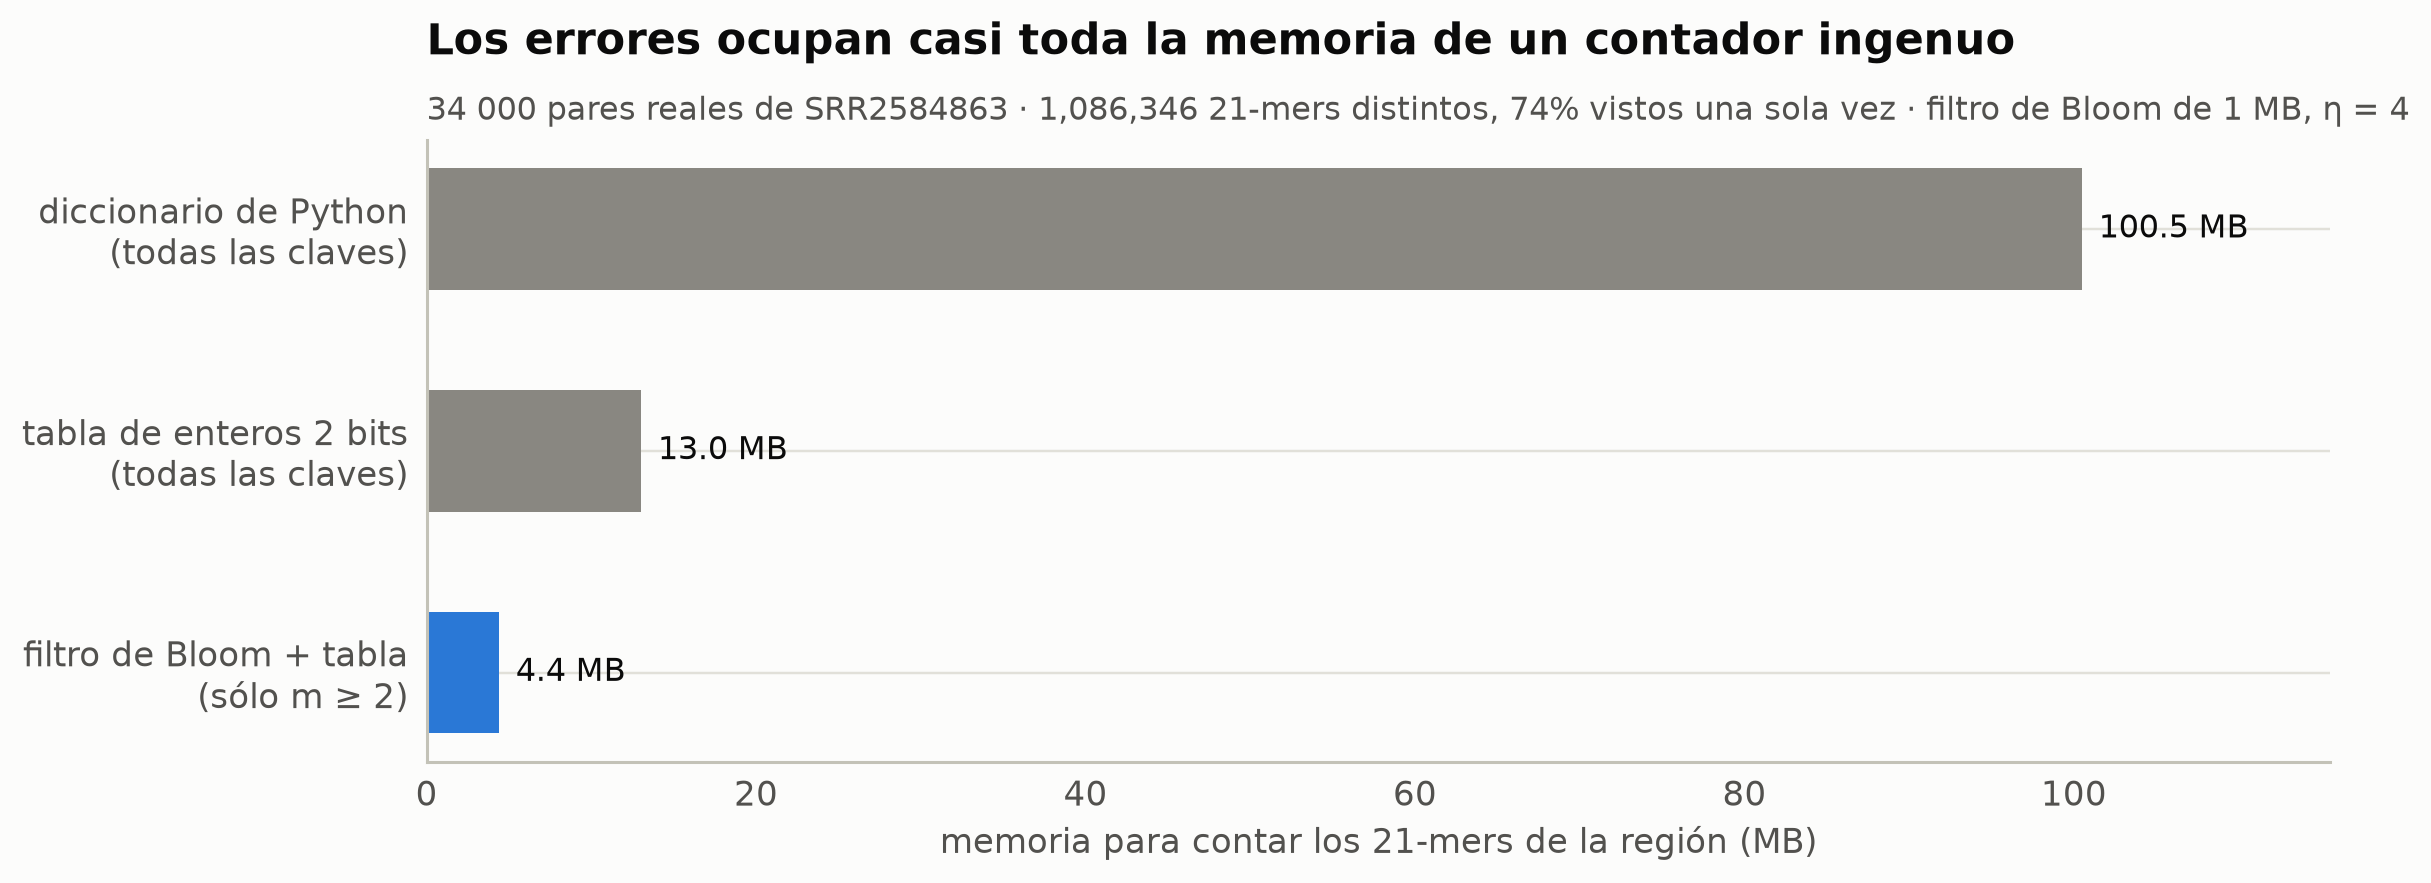

In [21]:
fig, ax = plt.subplots(figsize=(11, 3.9))
labels_m = list(mem)[::-1]; vals_m = [mem[k_] / 1e6 for k_ in labels_m]
ax.barh(labels_m, vals_m, color=[ec.BLUE, ec.MUTED, ec.MUTED], height=0.55)
for y_, v_ in enumerate(vals_m):
    ax.text(v_ + max(vals_m) * 0.01, y_, f"{v_:.1f} MB", va="center", fontsize=10.5)
ax.set_xlim(0, max(vals_m) * 1.15); ax.set_xlabel("memoria para contar los 21-mers de la región (MB)")
ec.title(ax, "Los errores ocupan casi toda la memoria de un contador ingenuo",
         f"34 000 pares reales de SRR2584863 · {u_reg.size:,} 21-mers distintos, {singletons / u_reg.size:.0%} vistos una sola vez · filtro de Bloom de 1 MB, η = 4")
plt.show()

> 🔎 **Qué observamos.** Todos los $k$-mers repetidos llegaron a la tabla (un filtro de Bloom nunca da falsos negativos),
> y sólo un 1 % de los únicos se colaron, menos que el 3 % de la fórmula: la fórmula describe el filtro **lleno**, al
> final del conteo, pero cada consulta se hace cuando el filtro aún está a medio llenar. La memoria cae varias veces, y la ganancia es mayor cuanto más
> errores hay. Hagamos la cuenta para un genoma humano a $30\times$: unos $5\times10^{9}$ $k$-mers distintos, de los que
> sólo unos $3\times10^{9}$ son del genoma (y se repiten). Un diccionario de Python necesitaría
> $5\times10^{9} \times 93\ \text{B} \approx 460$ GB; la tabla de enteros de 2 bits, $5\times10^{9} \times 12\ \text{B} = 60$ GB;
> con el filtro (1 byte por $k$-mer distinto, como aquí: $\approx 5$ GB) la tabla sólo guarda los repetidos,
> $3\times10^{9} \times 12\ \text{B} = 36$ GB, y el total baja a unos 41 GB. El precio: perdemos el conteo exacto de $h(1)$, que es precisamente la parte del espectro que
> no necesitamos para estimar el tamaño del genoma.

### 6.5 🧪 El espectro de las lecturas reales de la región

Con los conteos que ya tenemos, construimos el espectro de la región de 250 kb. Las lecturas se **reclutaron por mapeo**
(minimap2) contra la región 3 950 001–4 200 000 de REL606, que contiene 3 de los 7 operones de ARN ribosómico (*rrn*,
unos 5 kb cada uno).

> 🤔 **Antes de ejecutar, prediga.** Las 34 000 parejas dan $c \approx 68\,000 \times 150 / 250\,000 \approx 41\times$.
> ¿Dónde espera el pico con $k = 21$? ¿Saldrá $\widehat{G}$ igual a 250 kb?

In [22]:
def find_valley(hist, lo=2, hi=40):
    """Primer mínimo del espectro entre el muro de errores y el primer pico genómico."""
    return int(np.argmin(hist[lo:hi])) + lo

def fit_haploid(hist, valley, m_max, lam0, r0=20):
    """Ajuste de la mezcla en λ, 2λ, 3λ, 4λ a un espectro haploide (mismo modelo que el libro)."""
    m_ = np.arange(valley, m_max + 1)
    y_ = hist[valley:m_max + 1].astype(float)
    p0 = [lam0, y_.max() * lam0, y_.max(), y_.max() / 10, y_.max() / 10, r0]
    res = optimize.least_squares(lambda p: (mixture(p, m_) - y_) / np.sqrt(y_ + 10), p0,
                                 bounds=([lam0 / 3, 0, 0, 0, 0, 0.5], [lam0 * 3, 1e9, 1e9, 1e9, 1e9, 1e4]))
    return res.x

v_reg = find_valley(hist_reg)
peak_reg = v_reg + int(np.argmax(hist_reg[v_reg:200]))
mass_reg = (np.arange(len(hist_reg)) * hist_reg)[v_reg:].sum()
par_reg = fit_haploid(hist_reg, v_reg, 150, peak_reg)
lam_reg = par_reg[0]
c_reg_cov = len(reg_seqs) * 150 / 250_000
print(f"Cobertura por bases (si la región midiera 250 kb): c = {c_reg_cov:.1f}× → c_k = {c_reg_cov * 130 / 150:.1f}")
print(f"Valle v = {v_reg} · pico (moda) = {peak_reg} · λ ajustada (media) = {lam_reg:.1f} · r = {par_reg[5]:.1f}")
print(f"Masa Σ_(m≥v) m·h(m) = {mass_reg:,} k-mers")
print(f"Ĝ = masa/pico = {mass_reg / peak_reg:,.0f} pb · Ĝ = masa/λ = {mass_reg / lam_reg:,.0f} pb · región: 250 000 pb")
rrn_lo, rrn_hi = int(2.5 * lam_reg), int(5 * lam_reg)
rrn_peak = rrn_lo + int(np.argmax(hist_reg[rrn_lo:rrn_hi]))
print(f"Joroba de alta multiplicidad: máximo en m = {rrn_peak} ({rrn_peak / lam_reg:.2f} λ)")
hi_mass = (np.arange(len(hist_reg)) * hist_reg)[int(1.6 * lam_reg):].sum()
print(f"k-mers con m ≥ 1.6λ: {hist_reg[int(1.6 * lam_reg):].sum():,} distintos, "
      f"que aportan {hi_mass / lam_reg:,.0f} pb «equivalentes» de secuencia")

Cobertura por bases (si la región midiera 250 kb): c = 40.8× → c_k = 35.4
Valle v = 8 · pico (moda) = 29 · λ ajustada (media) = 30.2 · r = 19.6
Masa Σ_(m≥v) m·h(m) = 7,938,115 k-mers
Ĝ = masa/pico = 273,728 pb · Ĝ = masa/λ = 262,676 pb · región: 250 000 pb
Joroba de alta multiplicidad: máximo en m = 103 (3.41 λ)
k-mers con m ≥ 1.6λ: 13,418 distintos, que aportan 38,768 pb «equivalentes» de secuencia


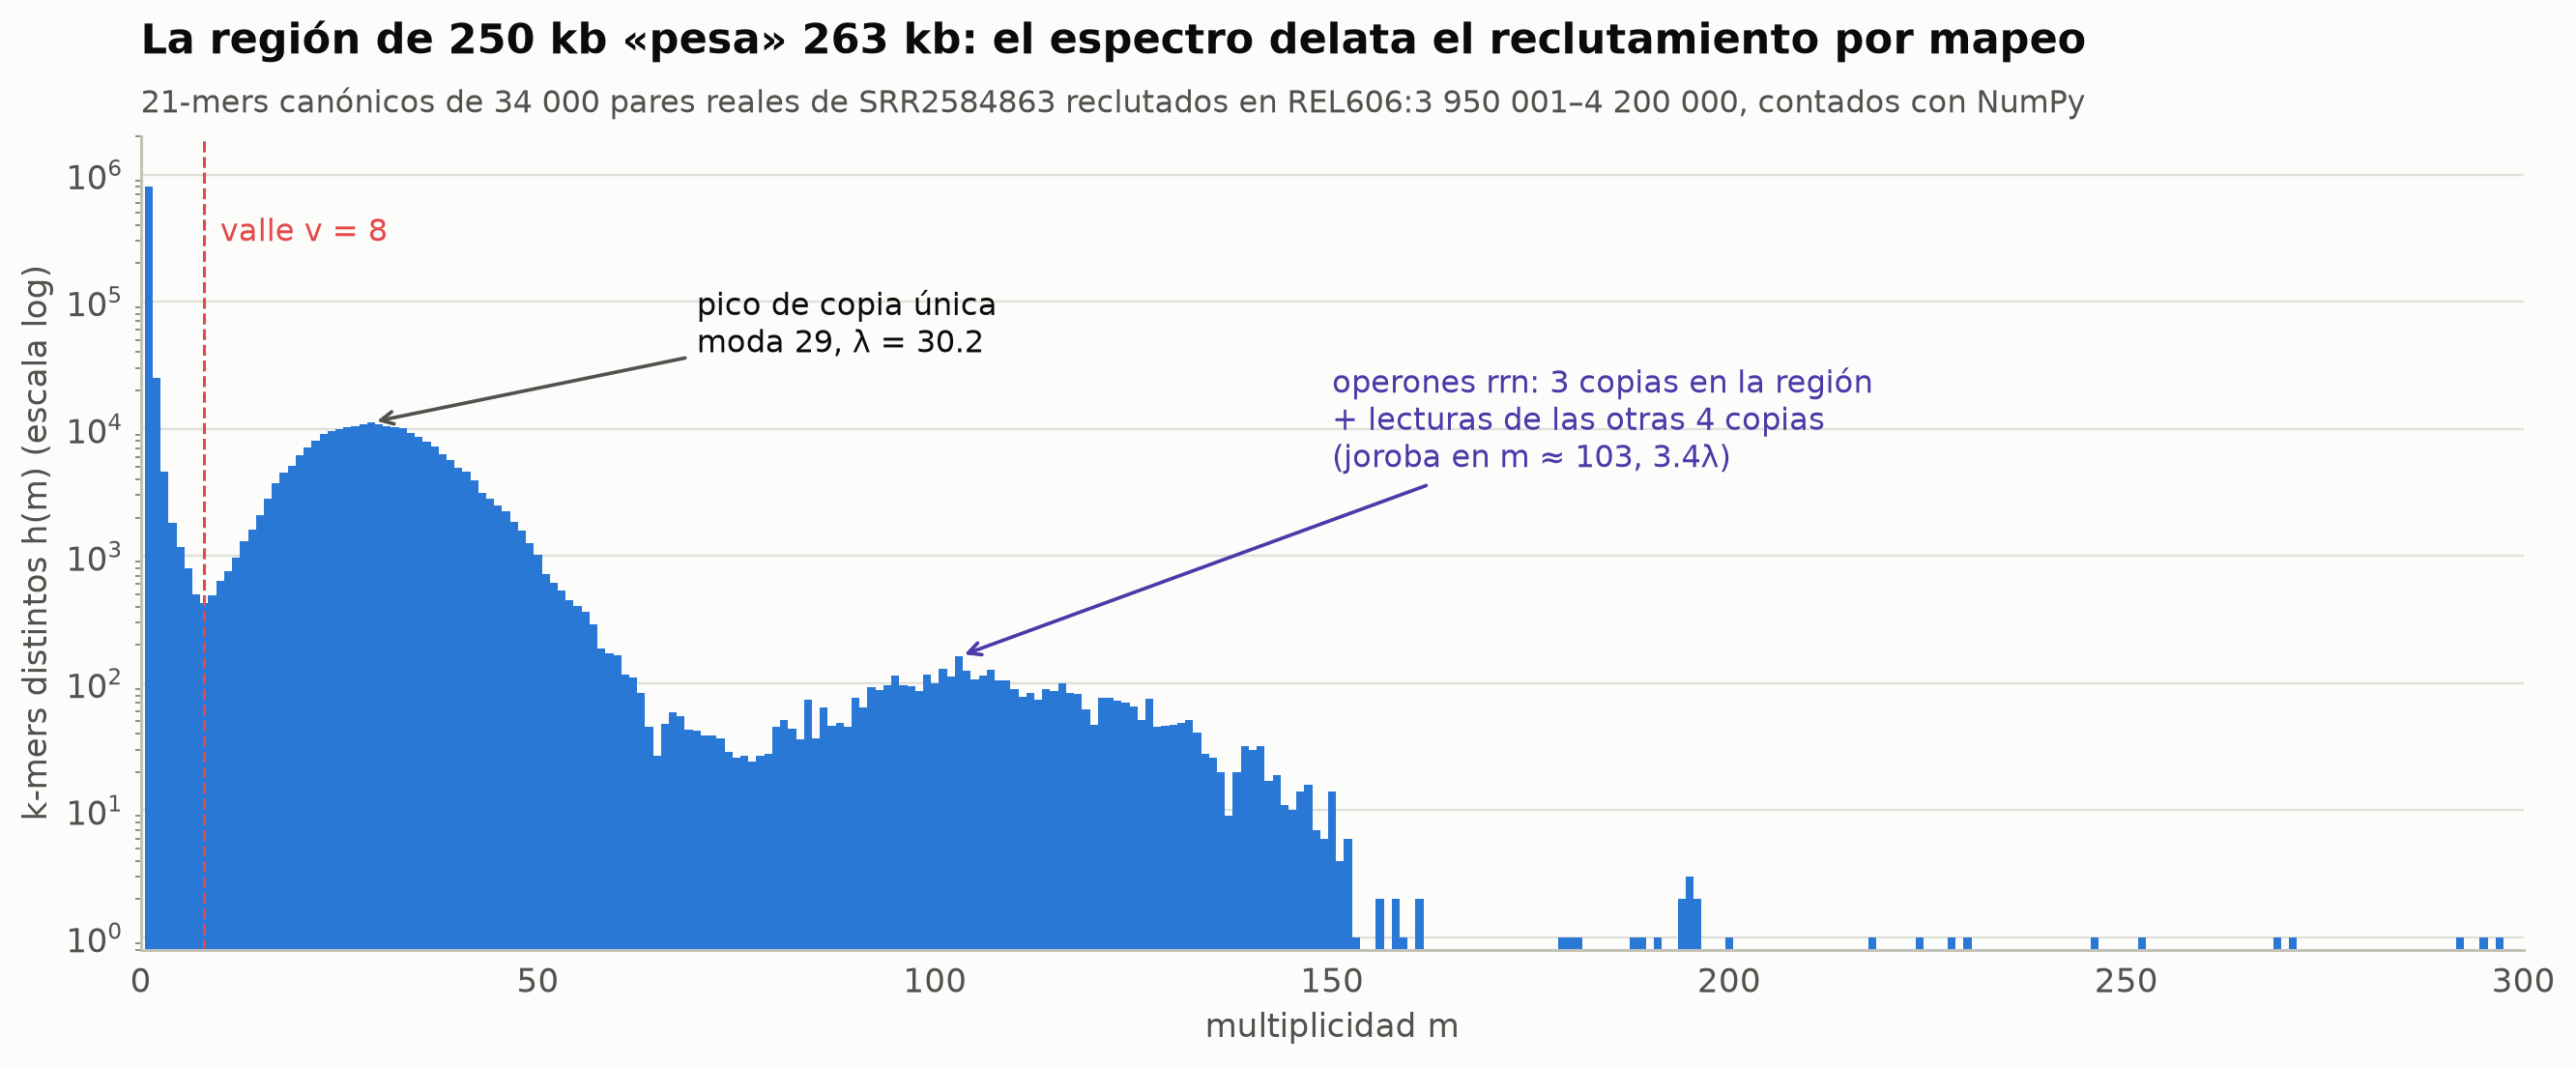

In [23]:
fig, ax = plt.subplots(figsize=(12, 4.9))
m_ = np.arange(1, 301)
y_ = np.zeros(300); n_ = min(300, len(hist_reg) - 1); y_[:n_] = hist_reg[1:n_ + 1]
ax.bar(m_, y_, width=1.0, color=ec.BLUE, lw=0)
ax.set_yscale("log"); ax.set_xlim(0, 300); ax.set_ylim(0.8, 2e6)
ax.axvline(v_reg, color=ec.RED, ls="--", lw=1)
ax.text(v_reg + 2, 3e5, f"valle v = {v_reg}", color=ec.RED, fontsize=10.5)
ax.annotate(f"pico de copia única\nmoda {peak_reg}, λ = {lam_reg:.1f}", (peak_reg, hist_reg[peak_reg]),
            xytext=(70, 4e4), fontsize=10.5, color=ec.INK, arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.INK_2))
ax.annotate(f"operones rrn: 3 copias en la región\n+ lecturas de las otras 4 copias\n(joroba en m ≈ {rrn_peak}, {rrn_peak / lam_reg:.1f}λ)",
            (rrn_peak, hist_reg[rrn_peak]), xytext=(150, 5e3), fontsize=10.5,
            color=ec.VIOLET, arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.VIOLET))
ax.set_xlabel("multiplicidad m"); ax.set_ylabel("k-mers distintos h(m) (escala log)")
ec.title(ax, f"La región de 250 kb «pesa» {mass_reg / lam_reg / 1000:,.0f} kb: el espectro delata el reclutamiento por mapeo",
         "21-mers canónicos de 34 000 pares reales de SRR2584863 reclutados en REL606:3 950 001–4 200 000, contados con NumPy")
plt.show()

> 🔎 **Qué observamos.** El pico de copia única está donde predice la ecuación 08-ck (≈ 30, por debajo de
> $c_k \approx 35$). Hay una **joroba** a algo más de $3\lambda$: son los $k$-mers de los tres operones *rrn* de la
> región, casi idénticos entre sí, que se leen tres veces más. Pero $\widehat{G}$ sale **mayor** que los 250 kb de la
> región. ¿Error del método? No: es una lección real sobre cómo se prepararon los datos. Las lecturas se eligieron por
> **mapeo**: todas las lecturas que minimap2 colocó en la región. Las de los operones *rrn* son iguales en las 7 copias
> del genoma, así que también cayeron aquí lecturas de **las otras cuatro copias** (fuera de la región): la profundidad
> en los *rrn* sube y la joroba se corre por encima de $3\lambda$. A eso se suman las lecturas de los bordes, cuya
> mitad sobresale de la región. El espectro «ve» más secuencia de la que hay en la región, y lo dice. En la Lección 8.3 veremos que algunos contigs del ensamblaje de esta región provienen, por la misma
> razón, de otras partes del genoma.

### 6.6 La herramienta profesional: KMC (y Jellyfish)

El flujo típico con datos reales es **contar, construir el histograma y ajustarlo**:

```bash
# 1) contar 21-mers canónicos (-C) con 8 hilos
jellyfish count -C -m 21 -s 1G -t 8 -o k21.jf \
    <(zcat lect_R1.fq.gz) <(zcat lect_R2.fq.gz)
jellyfish histo -t 8 k21.jf > k21.histo

# alternativa con KMC: contar e histograma
kmc -k21 -t8 -ci1 -cs100000 @archivos.txt k21 tmp/
kmc_tools transform k21 histogram k21.histo -cx100000

# 2) ajustar el modelo (diploide: -p 2)
genomescope2 -i k21.histo -o perfil/ -k 21 -p 2
```

La opción `-ci1` conserva los $k$-mers vistos una vez (por defecto KMC los descarta) y `-cs100000` sube el tope del
contador, para que los $k$-mers muy repetidos no se «saturen». La celda siguiente ejecuta KMC sobre las mismas lecturas
de la región si está disponible (en Colab lo instala con `apt-get`) y compara su histograma con el nuestro. Todo se
escribe en un directorio temporal.

In [24]:
kmc_bin = shutil.which("kmc")
if kmc_bin is None and IN_COLAB:
    subprocess.run("apt-get -qq update > /dev/null && apt-get -qq install -y kmc > /dev/null", shell=True)
    kmc_bin = shutil.which("kmc")

if kmc_bin is None:
    print("KMC no está disponible en este entorno: seguimos con el conteo de NumPy (idéntico en lo que importa).")
else:
    tmp = tempfile.mkdtemp(prefix="kmc81_")
    fq = [os.path.abspath(course_file(f"REL606_3950k-4200k_reads_{i}.fastq.gz")) for i in (1, 2)]
    open(os.path.join(tmp, "lista.txt"), "w").write("\n".join(fq) + "\n")
    t0 = time.time()
    run = subprocess.run(f"kmc -k21 -ci1 -cs100000 -t2 @{tmp}/lista.txt {tmp}/k21 {tmp} && "
                         f"kmc_tools transform {tmp}/k21 histogram {tmp}/k21.histo -cx100000",
                         shell=True, capture_output=True, text=True)
    stats_lines = [l.strip() for l in run.stdout.splitlines() if "No. of" in l or "Total no." in l]
    print(f"KMC terminó en {time.time() - t0:.1f} s")
    print("\n".join(stats_lines))
    kmc_hist = np.loadtxt(f"{tmp}/k21.histo", dtype=np.int64)
    kmc_h = np.zeros(max(len(hist_reg), kmc_hist[:, 0].max() + 1), dtype=np.int64)
    kmc_h[kmc_hist[:, 0]] = kmc_hist[:, 1]
    ours = np.zeros_like(kmc_h); ours[:len(hist_reg)] = hist_reg
    print("\n  m   KMC       NumPy")
    for m in [1, 2, 3, 10, 20, 30, 40, 70]:
        print(f"{m:3d}  {kmc_h[m]:>8,}  {ours[m]:>8,}")
    print(f"Multiplicidades con diferencias: {(kmc_h != ours).sum()} de {len(ours)}")
    shutil.rmtree(tmp, ignore_errors=True)

KMC terminó en 1.3 s
No. of k-mers below min. threshold :            0
No. of k-mers above max. threshold :            0
No. of unique k-mers               :      1086346
No. of unique counted k-mers       :      1086346
Total no. of k-mers                :      8832354
Total no. of reads                 :        68000
Total no. of super-k-mers          :      1298284

  m   KMC       NumPy
  1   808,993   808,993
  2    24,932    24,932
  3     4,613     4,613
 10       638       638
 20     6,168     6,168
 30    10,814    10,814
 40     4,940     4,940
 70        42        42
Multiplicidades con diferencias: 0 de 100001


> 🔎 **Qué observamos.** KMC y nuestro contador en NumPy producen **el mismo histograma**: los mismos 8.8 millones de
> $k$-mers leídos y el mismo 1.09 millones de distintos. No hay magia en las herramientas: hacen lo que acabamos de
> programar, sólo que en C++, en paralelo y sin que la memoria dependa del tamaño del problema.

## 7. 🧪 El clon del LTEE: el tamaño del genoma **antes** de ensamblar

Volvamos al laboratorio que recibe el clon. Tenemos las lecturas completas de **SRR2584863** y ninguna referencia.
Primero, lo que dice el archivo público (la tabla del ENA que ya consultamos en la Lección 6.2):

In [25]:
RUN = "SRR2584863"
ENA_FIELDS = ("run_accession,study_accession,sample_accession,scientific_name,instrument_model,library_layout,"
              "library_strategy,library_source,library_selection,read_count,base_count,fastq_ftp,fastq_bytes,fastq_md5")
ENA_URL = (f"https://www.ebi.ac.uk/ena/portal/api/filereport?accession={RUN}"
           f"&result=read_run&fields={ENA_FIELDS}&format=tsv")
meta = pd.read_csv(io.StringIO(course_bytes(f"api_cache/ena_filereport_{RUN}.tsv", live_url=ENA_URL).decode()),
                   sep="\t").iloc[0]
n_pairs, n_bases = int(meta.read_count), int(meta.base_count)
print(f"{meta.run_accession}: {meta.scientific_name} · {meta.instrument_model} · {meta.library_layout}")
print(f"Pares: {n_pairs:,} · lecturas: {2 * n_pairs:,} · bases: {n_bases:,} · longitud media: {n_bases / (2 * n_pairs):.0f} pb")
print("¿Cobertura? c = bases / G … ¡pero G es justamente lo que no sabemos!")

SRR2584863: Escherichia coli B str. REL606 · Illumina HiSeq 2500 · PAIRED
Pares: 1,553,259 · lecturas: 3,106,518 · bases: 465,977,700 · longitud media: 150 pb
¿Cobertura? c = bases / G … ¡pero G es justamente lo que no sabemos!


La cobertura $c = NL/G$ depende del tamaño del genoma, que es lo que queremos averiguar. El espectro rompe ese círculo:
**la posición del pico nos da la cobertura y la masa nos da el tamaño.**

Contar los 21-mers de las 3.1 millones de lecturas con KMC tarda un par de minutos y necesita descargar 375 MB, así que
el curso guarda el histograma resultante (`data/SRR2584863_k21.histo`, producido con `kmc -k21 -ci1` sobre **todas**
las lecturas; al final de esta sección hay una celda opcional para recalcularlo en Colab). Es un archivo de texto de dos
columnas: multiplicidad $m$ y $h(m)$.

In [26]:
histo_txt = course_bytes("SRR2584863_k21.histo").decode()
print("\n".join(histo_txt.splitlines()[:6]), "\n…")
arr = np.loadtxt(io.StringIO(histo_txt), comments="#", dtype=np.int64)
hist_real = np.zeros(arr[:, 0].max() + 1, dtype=np.int64)
hist_real[arr[:, 0]] = arr[:, 1]
m_real = np.arange(len(hist_real))
total_kmers = (m_real * hist_real).sum()
print(f"\nk-mers leídos: {total_kmers:,} · distintos: {hist_real.sum():,} · "
      f"vistos una vez: {hist_real[1]:,} ({hist_real[1] / hist_real.sum():.1%} de los distintos)")
print(f"Multiplicidad máxima: {len(hist_real) - 1:,}")

# Espectro de 21-mers canónicos de SRR2584863 (E. coli B, clon del LTEE; 1,553,259 pares 2x150, lecturas completas de ENA) contado con KMC 3 (-k21 -ci1). Columnas: multiplicidad, número de k-mers distintos
1	31870746
2	1348840
3	270627
4	103458
5	53525 
…

k-mers leídos: 392,975,086 · distintos: 38,306,501 · vistos una vez: 31,870,746 (83.2% de los distintos)
Multiplicidad máxima: 8,829


> 🤔 **Antes de ejecutar, prediga.** *E. coli* es haploide. ¿Cuántos picos genómicos espera ver? ¿Qué denominador usará
> en la ecuación 08-masa: $\lambda$ o $2\lambda$? ¿Y dónde esperaría ver los $k$-mers de los **7 operones de ARN
> ribosómico** del genoma?

Aplicamos el protocolo de la sección 5: valle, pico, masa y ajuste. Como es haploide, el componente «$1\times$» del
modelo es la copia única (media $\lambda$) y los de $2\lambda$, $3\lambda$, $4\lambda$ recogen las repeticiones de 2, 3
y 4 copias. El tamaño es $\widehat{G} = \sum_{m\ge v} m\,h(m) / \lambda$.

In [27]:
v_real = find_valley(hist_real, 2, 40)
mode_real = v_real + int(np.argmax(hist_real[v_real:300]))
mass_real = (m_real * hist_real)[v_real:].sum()
par_real = fit_haploid(hist_real, v_real, 300, float(mode_real))
lam_real, a1_r, a2_r, a3_r, a4_r, r_real = par_real
G_true = 4_629_812                                 # REL606 (NC_012967.1): sólo para comparar al final
G_mode, G_fit, G_wrong = mass_real / mode_real, mass_real / lam_real, mass_real / (2 * lam_real)
nb_mode = int(np.floor((r_real - 1) * lam_real / r_real))
print(f"Valle v = {v_real} (h = {hist_real[v_real]:,}) · moda del pico = {mode_real}")
print(f"Ajuste: λ (media) = {lam_real:.2f} · sobredispersión r = {r_real:.1f} → varianza/media = {1 + lam_real / r_real:.1f} "
      f"(Poisson: 1) · moda de esa binomial negativa = {nb_mode}")
print(f"k-mers de copia única del ajuste: {a1_r:,.0f}")
print(f"Masa Σ_(m≥v) m·h(m) = {mass_real:,}  ({mass_real / total_kmers:.1%} de los k-mers leídos)\n")
rows = [("masa / moda del pico (73)", G_mode), ("masa / λ ajustada", G_fit),
        ("masa / 2λ (¡suponer diploide!)", G_wrong)]
for name, g in rows:
    print(f"Ĝ = {name:32s} = {g:>12,.0f} pb  ({(g / G_true - 1):+.1%} frente a REL606)")
print(f"{'Referencia REL606':38s}   {G_true:>12,} pb")
c_hat = n_bases / G_fit
print(f"\nCon Ĝ ya podemos calcular la cobertura: c = {n_bases:,} / {G_fit:,.0f} = {c_hat:.1f}×")

Valle v = 22 (h = 2,367) · moda del pico = 73
Ajuste: λ (media) = 76.27 · sobredispersión r = 21.1 → varianza/media = 4.6 (Poisson: 1) · moda de esa binomial negativa = 72
k-mers de copia única del ajuste: 4,454,120
Masa Σ_(m≥v) m·h(m) = 355,679,512  (90.5% de los k-mers leídos)

Ĝ = masa / moda del pico (73)        =    4,872,322 pb  (+5.2% frente a REL606)
Ĝ = masa / λ ajustada                =    4,663,236 pb  (+0.7% frente a REL606)
Ĝ = masa / 2λ (¡suponer diploide!)   =    2,331,618 pb  (-49.6% frente a REL606)
Referencia REL606                           4,629,812 pb

Con Ĝ ya podemos calcular la cobertura: c = 465,977,700 / 4,663,236 = 99.9×


> 🔎 **Qué observamos.** Sin mirar la referencia, el espectro estima un genoma de **≈ 4.66 Mb**, a menos del 1 % de los
> 4 629 812 pb de REL606. Tomar la **moda** del pico (73) como denominador sobreestima un 5 %, y suponer por error que el
> organismo es diploide (dividir por $2\lambda$) daría la mitad. La elección del denominador no es un detalle.

### 7.1 Reconciliar el pico en 73 con la teoría

Aquí hay algo que no cuadra a primera vista, y un buen analista no lo esconde. La cobertura por bases es
$c = 465\,977\,700 / 4\,629\,812 = 100.6\times$ y la ecuación 08-ck da $c_k = 100.6 \times 130/150 \approx 87$.
**¿Por qué el pico está en 73 y no en 87?** Vamos factor por factor, con cantidades medidas en los propios datos:

In [28]:
c_true = n_bases / G_true
ck_true = c_true * 130 / 150
expected_kmers = 2 * n_pairs * 130                 # si todas las ventanas de todas las lecturas se hubieran contado
frac_counted = total_kmers / expected_kmers
frac_clean = mass_real / total_kmers               # fracción de k-mers leídos que están por encima del valle
e_hat = 1 - frac_clean ** (1 / 21)

# ¿Cuántas ventanas se pierden por bases N? Lo medimos en las 30 000 parejas de la Lección 6.2
n_ok = n_all = 0
for fq_ in ("SRR2584863_30k_1.fastq.gz", "SRR2584863_30k_2.fastq.gz"):
    for s_ in read_fastq_seqs(fq_):
        ok = np.frombuffer(s_, dtype=np.uint8) != ord("N")
        n_all += len(s_) - 20
        n_ok += int((np.convolve(ok, np.ones(21, dtype=int), "valid") == 21).sum())
frac_noN = n_ok / n_all

steps_rec = [
    ("c = bases / G", c_true, "cobertura por bases (usando ahora G real)"),
    ("× (L−k+1)/L = 130/150", ck_true, "sólo cuentan los 21-mers completos dentro de la lectura"),
    (f"× k-mers en el histograma / esperados = {frac_counted:.3f}", ck_true * frac_counted,
     f"ventanas que no llegaron al histograma (las N explican sólo {1 - frac_noN:.2%})"),
    (f"× fracción sin error = {frac_clean:.3f} = (1−ê)^21", ck_true * frac_counted * frac_clean,
     f"k-mers con algún error, ê = {e_hat:.2%} por base"),
    ("= media real de un 21-mer de copia única", mass_real / G_true, "masa / G real (comprobación)"),
    ("media ajustada λ (binomial negativa)", lam_real, "sin usar la referencia"),
    ("moda de la binomial negativa ajustada", nb_mode, f"r = {r_real:.0f}: distribución asimétrica"),
    ("pico observado del espectro", mode_real, "la barra más alta"),
]
rec = pd.DataFrame(steps_rec, columns=["paso", "valor", "explicación"])
rec["valor"] = rec["valor"].map(lambda v: f"{v:.1f}")
print(rec.to_string(index=False))

                                         paso valor                                                        explicación
                                c = bases / G 100.6                          cobertura por bases (usando ahora G real)
                        × (L−k+1)/L = 130/150  87.2            sólo cuentan los 21-mers completos dentro de la lectura
× k-mers en el histograma / esperados = 0.973  84.9 ventanas que no llegaron al histograma (las N explican sólo 0.25%)
      × fracción sin error = 0.905 = (1−ê)^21  76.8                         k-mers con algún error, ê = 0.47% por base
     = media real de un 21-mer de copia única  76.8                                       masa / G real (comprobación)
         media ajustada λ (binomial negativa)  76.3                                             sin usar la referencia
        moda de la binomial negativa ajustada  72.0                                    r = 21: distribución asimétrica
                  pico observado del espectro  7

> 🔎 **Qué observamos.** La cadena explica el pico sin trucos:
>
> 1. De $100.6\times$ por bases pasamos a $c_k = 87.2$ porque cada lectura de 150 pb sólo contiene 130 21-mers.
> 2. Un 2.7 % de las ventanas esperadas **no está** en el histograma. Las bases `N` sólo explican una décima parte;
>    el resto no lo podemos atribuir con seguridad con estos datos (candidatos razonables: lecturas de mala calidad
>    concentradas en ciertas zonas de la celda de flujo, o $k$-mers de adaptadores con multiplicidades por encima del tope
>    del histograma). Lo decimos así, sin inventar una causa.
> 3. Un 9.5 % de los $k$-mers leídos cae por debajo del valle: son los que tienen algún error. Eso equivale a
>    $(1-\hat e)^{21} = 0.905$, es decir, **$\hat e \approx 0.47\,\%$ de error por base**, un valor típico de un HiSeq 2500.
> 4. El resultado, $\approx 76.8$, es la **media** de veces que se leyó un 21-mer de copia única. El ajuste, **sin usar la
>    referencia**, da $\lambda = 76.3$: coinciden.
> 5. ¿Y el 73? Es la **moda**, no la media. La binomial negativa ajustada tiene $r \approx 21$ (varianza 4.6 veces la
>    media): la cobertura real es mucho más irregular que una Poisson por el sesgo de contenido GC y por la preparación
>    de la biblioteca (Tn5: las lecturas traen adaptadores Nextera, como vimos en la Lección 6.2). Una distribución asimétrica a la derecha tiene la moda **por debajo** de la
>    media. Por eso GenomeScope ajusta un modelo en vez de leer la barra más alta: el pico es una meseta ancha
>    (entre 70 y 78 las barras varían poco) y su máximo exacto es ruido.
>
> En la simulación de la sección 5, $r$ quedó en su tope (Poisson) y la moda coincidía con la media. Los datos reales
> nunca son tan amables.

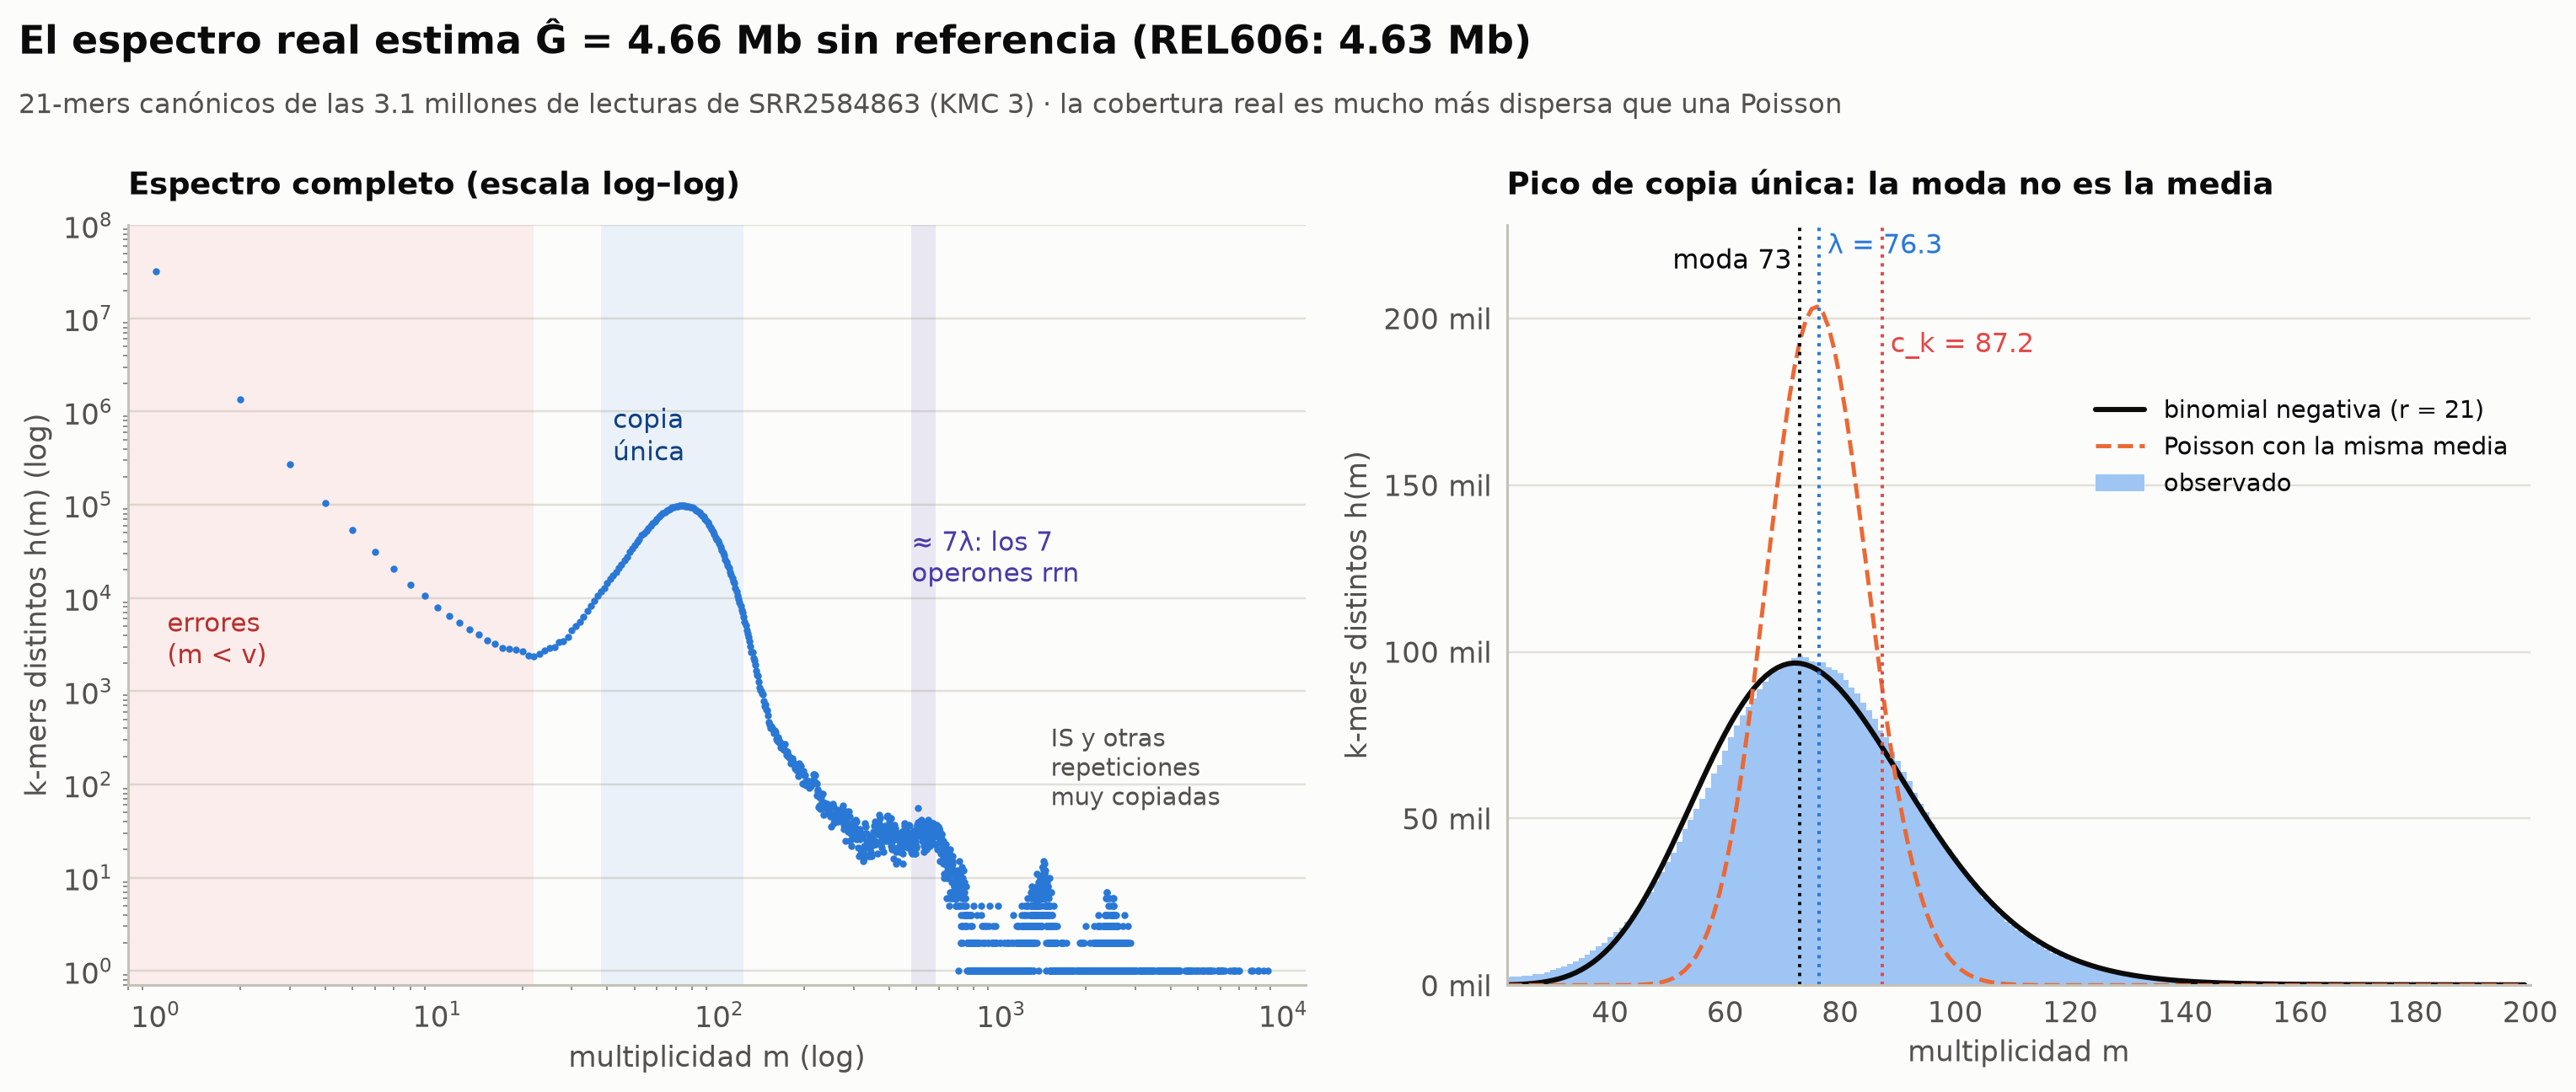

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw=dict(width_ratios=[1.15, 1]))
nz = hist_real > 0
ax1.loglog(m_real[nz], hist_real[nz], ".", ms=3.5, color=ec.BLUE)
ax1.axvspan(0.8, v_real, color=ec.RED, alpha=0.08, lw=0)
ax1.axvspan(0.5 * lam_real, 1.6 * lam_real, color=ec.BLUE, alpha=0.08, lw=0)
ax1.axvspan(6.3 * lam_real, 7.7 * lam_real, color=ec.VIOLET, alpha=0.10, lw=0)
ax1.text(1.1, 2e3, "errores\n(m < v)", color="#b8302f", fontsize=10)
ax1.text(lam_real * 0.55, 3e5, "copia\núnica", color="#104281", fontsize=10)
ax1.text(6.3 * lam_real, 1.5e4, "≈ 7λ: los 7\noperones rrn", color=ec.VIOLET, fontsize=10)
ax1.text(1500, 60, "IS y otras\nrepeticiones\nmuy copiadas", color=ec.INK_2, fontsize=9.5)
ax1.set_xlim(0.8, 1.2e4); ax1.set_ylim(0.7, 1e8)
ax1.set_xlabel("multiplicidad m (log)"); ax1.set_ylabel("k-mers distintos h(m) (log)")
ax1.set_title("Espectro completo (escala log–log)", loc="left", fontsize=12)

zm = np.arange(v_real, 200)
ax2.bar(zm, hist_real[zm], width=1.0, color="#9ec5f4", lw=0, label="observado")
ax2.plot(zm, mixture(par_real, zm), color=ec.INK, lw=2, label=f"binomial negativa (r = {r_real:.0f})")
ax2.plot(zm, a1_r * stats.poisson.pmf(zm, lam_real), color=ec.ORANGE, lw=1.6, ls="--",
         label="Poisson con la misma media")
ymax2 = a1_r * stats.poisson.pmf(int(lam_real), lam_real) * 1.12
for x_, lab, col, yy, ha in [(mode_real, f"moda {mode_real}", ec.INK, 0.97, "right"),
                             (lam_real, f"λ = {lam_real:.1f}", ec.BLUE, 0.99, "left"),
                             (ck_true, f"c_k = {ck_true:.1f}", ec.RED, 0.86, "left")]:
    ax2.axvline(x_, color=col, ls=":", lw=1.3)
    ax2.text(x_ + (1.5 if ha == "left" else -1.5), ymax2 * yy, lab, color=col, fontsize=10.5, va="top", ha=ha)
ax2.set_xlim(v_real, 200); ax2.set_ylim(0, ymax2)
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, p: f"{v / 1000:.0f} mil"))
ax2.set_xlabel("multiplicidad m"); ax2.set_ylabel("k-mers distintos h(m)")
ax2.legend(loc="upper right", bbox_to_anchor=(1.0, 0.8), frameon=False, fontsize=9.5)
ax2.set_title("Pico de copia única: la moda no es la media", loc="left", fontsize=12)
ec.fig_title(fig, f"El espectro real estima Ĝ = {G_fit / 1e6:.2f} Mb sin referencia (REL606: 4.63 Mb)",
             "21-mers canónicos de las 3.1 millones de lecturas de SRR2584863 (KMC 3) · la cobertura real es mucho más dispersa que una Poisson")
plt.tight_layout()
plt.show()

### 7.2 Las repeticiones, vistas desde el espectro y desde la referencia

La región violeta de la figura, alrededor de $7\lambda \approx 530$, es otra predicción cumplida: *E. coli* tiene **7
operones de ARN ribosómico** casi idénticos, de unos 5 kb cada uno, y sus $k$-mers se leen siete veces más. Ahora sí
«abrimos el sobre» y contamos, en el genoma de REL606, cuántos 21-mers distintos tienen 1, 2, …, 7 copias, para comparar
con lo que el espectro ve en las ventanas $[(r-\tfrac12)\lambda,\ (r+\tfrac12)\lambda)$.

In [30]:
rel_txt = gzip.decompress(course_bytes("NC_012967.1.fasta.gz")).decode()
rel606 = "".join(l.strip() for l in rel_txt.splitlines() if not l.startswith(">"))
g_rel = encode(rel606)
print(f"REL606: {len(rel606):,} pb")

def copy_numbers(genome_codes, k):
    """Para cada 21-mer canónico distinto del genoma, en cuántas posiciones (de ambas hebras) aparece."""
    return np.unique(kmers_canon(genome_codes[None, :], k), return_counts=True)[1]

cn21 = copy_numbers(g_rel, 21)
rows = []
for r_ in range(1, 9):
    lo, hi = int(round((r_ - 0.5) * lam_real)), int(round((r_ + 0.5) * lam_real))
    rows.append(dict(copias=r_, **{"21-mers distintos en REL606": int((cn21 == r_).sum()),
                                   "ventana de m en el espectro": f"[{max(lo, v_real)}, {hi})",
                                   "k-mers distintos en esa ventana": int(hist_real[max(lo, v_real):hi].sum())}))
rep_tab = pd.DataFrame(rows)
print(rep_tab.to_string(index=False))
print(f"\n21-mers de REL606 con ≥ 10 copias: {(cn21 >= 10).sum():,} distintos (máx. {cn21.max()} copias) · "
      f"en el espectro, k-mers con m ≥ {int(9.5 * lam_real)}: {hist_real[int(9.5 * lam_real):].sum():,}")
# Espectro PREDICHO desde la referencia: un k-mer con r copias se lee como la suma de r binomiales
# negativas independientes (media rλ, forma r·r_nb). Sólo usamos λ y r del ajuste y las copias de REL606.
cn_vals, cn_n = np.unique(cn21, return_counts=True)
m_pred = np.arange(v_real, 3000)
pred = np.zeros(m_pred.size)
for r_, n_r in zip(cn_vals, cn_n):
    pred += n_r * stats.nbinom.pmf(m_pred, r_ * r_real, r_real / (r_real + lam_real))
print(f"Copias en REL606: {dict(zip(cn_vals[:8].tolist(), cn_n[:8].tolist()))} …")

REL606: 4,629,812 pb


 copias  21-mers distintos en REL606 ventana de m en el espectro  k-mers distintos en esa ventana
      1                      4489628                   [38, 114)                          4283233
      2                        20672                  [114, 191)                           149262
      3                         3219                  [191, 267)                             6162
      4                         2186                  [267, 343)                             2433
      5                         4380                  [343, 420)                             2233
      6                          622                  [420, 496)                             1946
      7                         4274                  [496, 572)                             2356
      8                           97                  [572, 648)                             1819

21-mers de REL606 con ≥ 10 copias: 934 distintos (máx. 78 copias) · en el espectro, k-mers con m ≥ 724: 3,109
Copias 

> 🔎 **Qué observamos.** REL606 tiene unos 4.49 millones de 21-mers de copia única, y el ajuste del espectro asignó
> 4.45 millones al componente $\lambda$: casi lo mismo, sin mirar la referencia. Contar por **ventanas** de $m$ funciona
> mal para las repeticiones: la binomial negativa de copia única es tan ancha ($r \approx 21$) que su cola invade la
> ventana de 2 copias (149 000 frente a 21 000). Por eso la comparación honesta es la de la figura siguiente: el espectro
> que **predice** la referencia (cada $k$-mer con $r$ copias leído como una binomial negativa de media $r\lambda$) frente
> al observado. Los $k$-mers con muchas copias corresponden a los **elementos de inserción** (IS1, IS150…) que REL606
> tiene en decenas de copias. Como anunciaba el libro: **las repeticiones no estorban para estimar $G$**, porque cada
> $k$-mer aporta a la masa exactamente tantas veces como copias tiene.

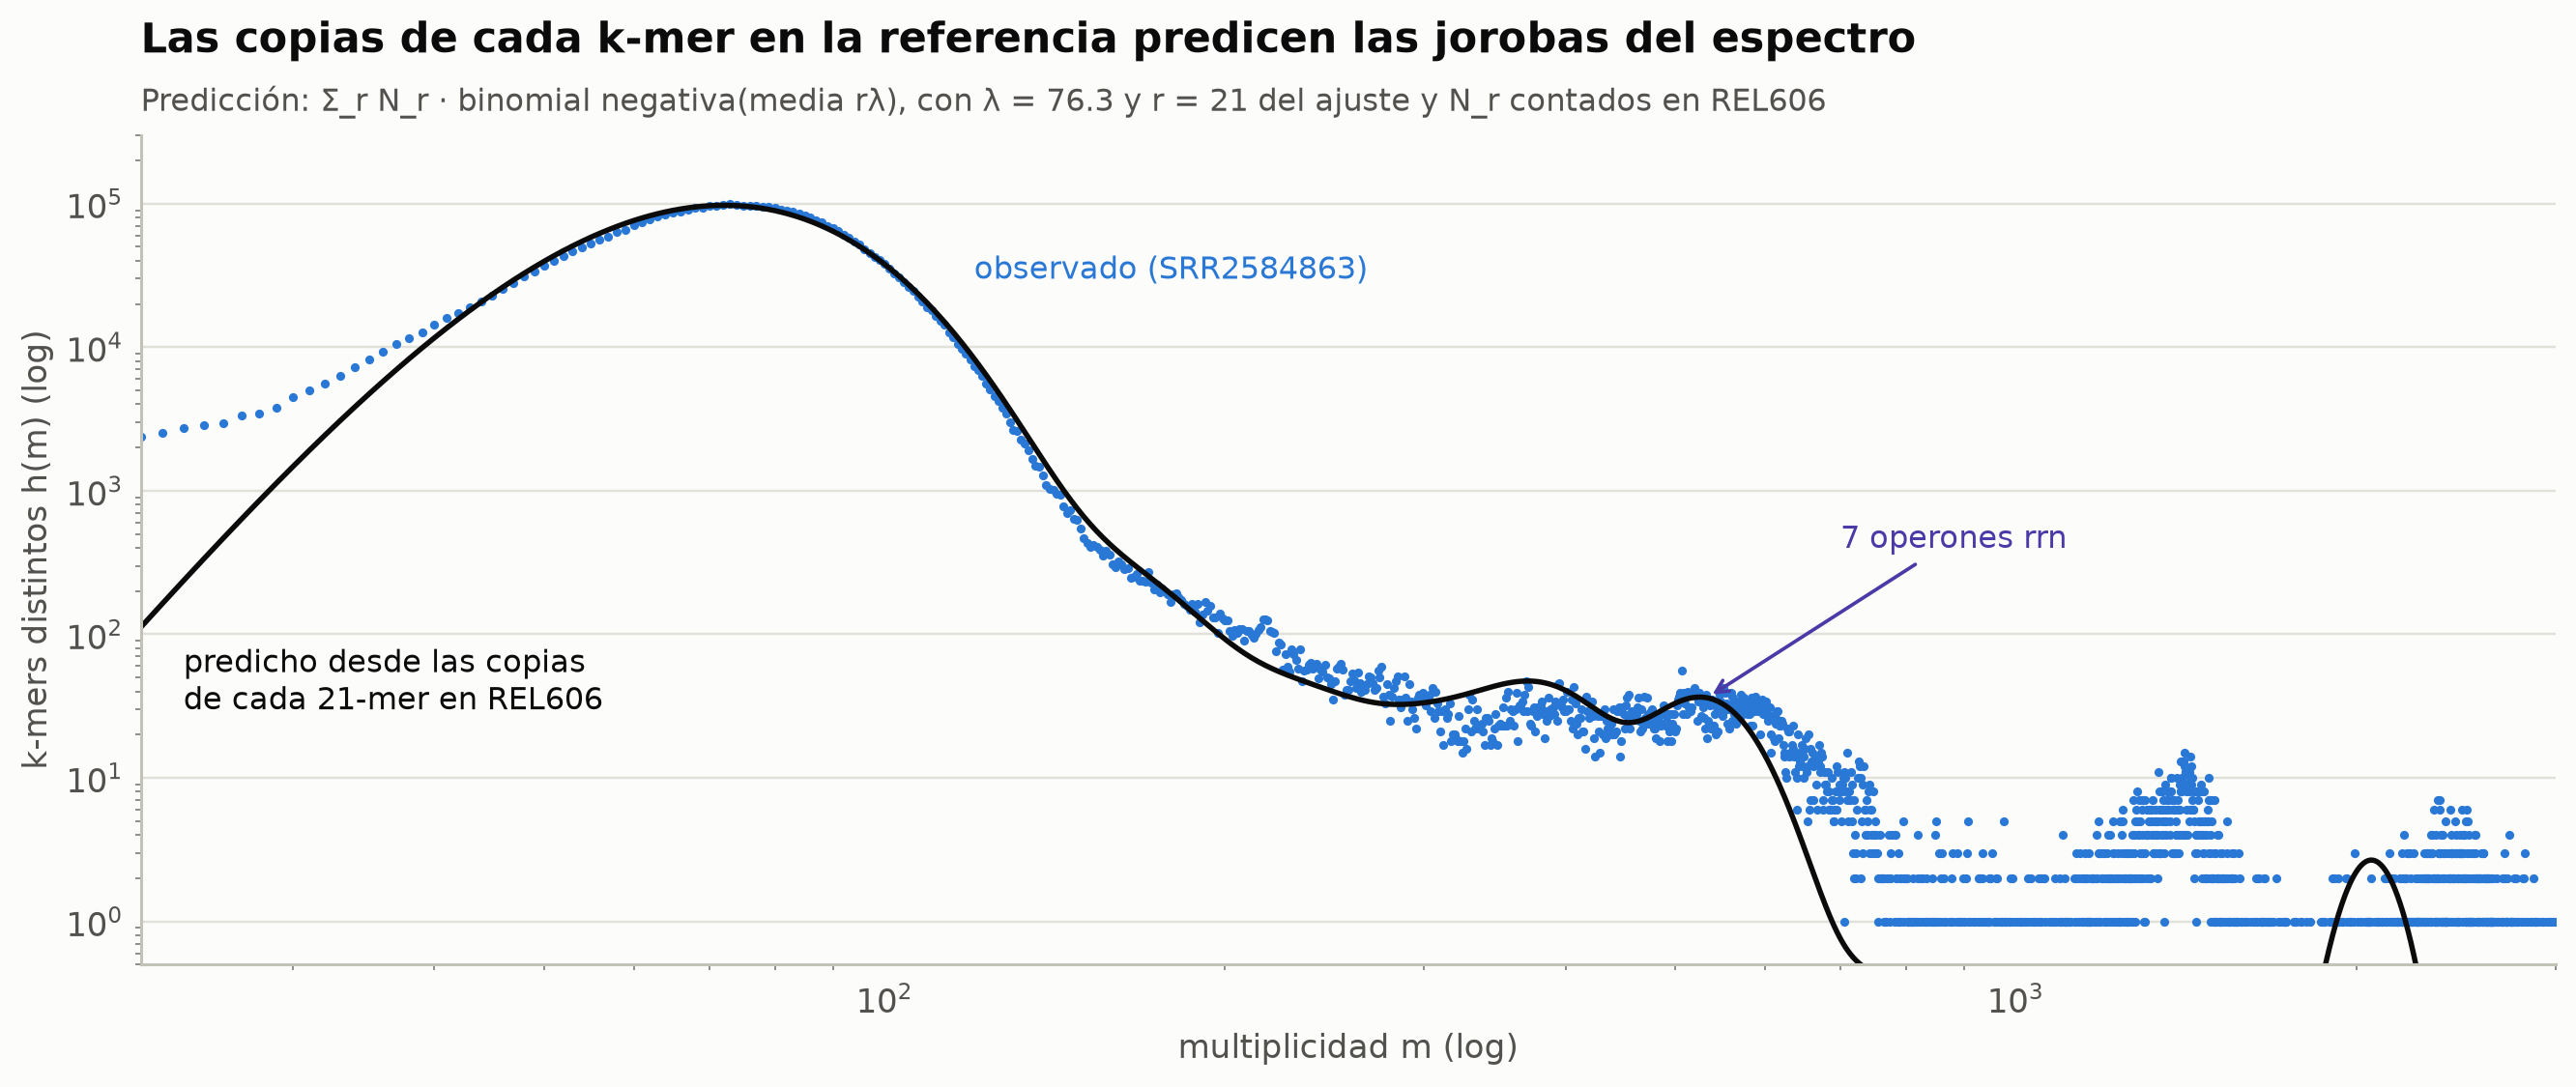

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
nzo = (m_real >= v_real) & (hist_real > 0) & (m_real < 3000)
ax.loglog(m_real[nzo], hist_real[nzo], ".", ms=4, color=ec.BLUE)
ok_ = pred > 0.05
ax.loglog(m_pred[ok_], pred[ok_], color=ec.INK, lw=1.8)
ax.text(120, 3e4, "observado (SRR2584863)", color=ec.BLUE, fontsize=10.5)
ax.text(24, 30, "predicho desde las copias\nde cada 21-mer en REL606", color=ec.INK, fontsize=10.5)
ax.annotate("7 operones rrn", (7 * lam_real, pred[int(7 * lam_real) - v_real]), xytext=(700, 400), fontsize=10.5,
            color=ec.VIOLET, arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.VIOLET))
ax.set_xlim(v_real, 3000); ax.set_ylim(0.5, 3e5)
ax.set_xlabel("multiplicidad m (log)"); ax.set_ylabel("k-mers distintos h(m) (log)")
ec.title(ax, "Las copias de cada k-mer en la referencia predicen las jorobas del espectro",
         f"Predicción: Σ_r N_r · binomial negativa(media rλ), con λ = {lam_real:.1f} y r = {r_real:.0f} del ajuste y N_r contados en REL606")
plt.show()

> 🔎 **Qué observamos.** Sin ningún parámetro nuevo, la curva construida con las copias de REL606 reproduce el pico de
> copia única, la cola de 2–4 copias y la joroba de los operones *rrn* en $\approx 7\lambda$. Las jorobas de muy alta
> multiplicidad (≈ 1 000–3 000) son las familias de elementos IS. Donde las dos curvas difieren conviene recordar que
> el clon **no es** exactamente su ancestro: es probable que, tras miles de generaciones en el LTEE, algunos elementos
> IS hayan cambiado de número de copias, y las lecturas traen además algo de secuencia técnica (adaptadores). El
> espectro es, de paso, una forma rápida de sospechar cuánto se aparta un genoma de su referencia.

La versión interactiva del espectro real. Pase el cursor: verá, para cada multiplicidad, cuántas «copias genómicas»
equivalen ($m/\lambda$), qué fracción de la masa aporta y cómo interpretarla.

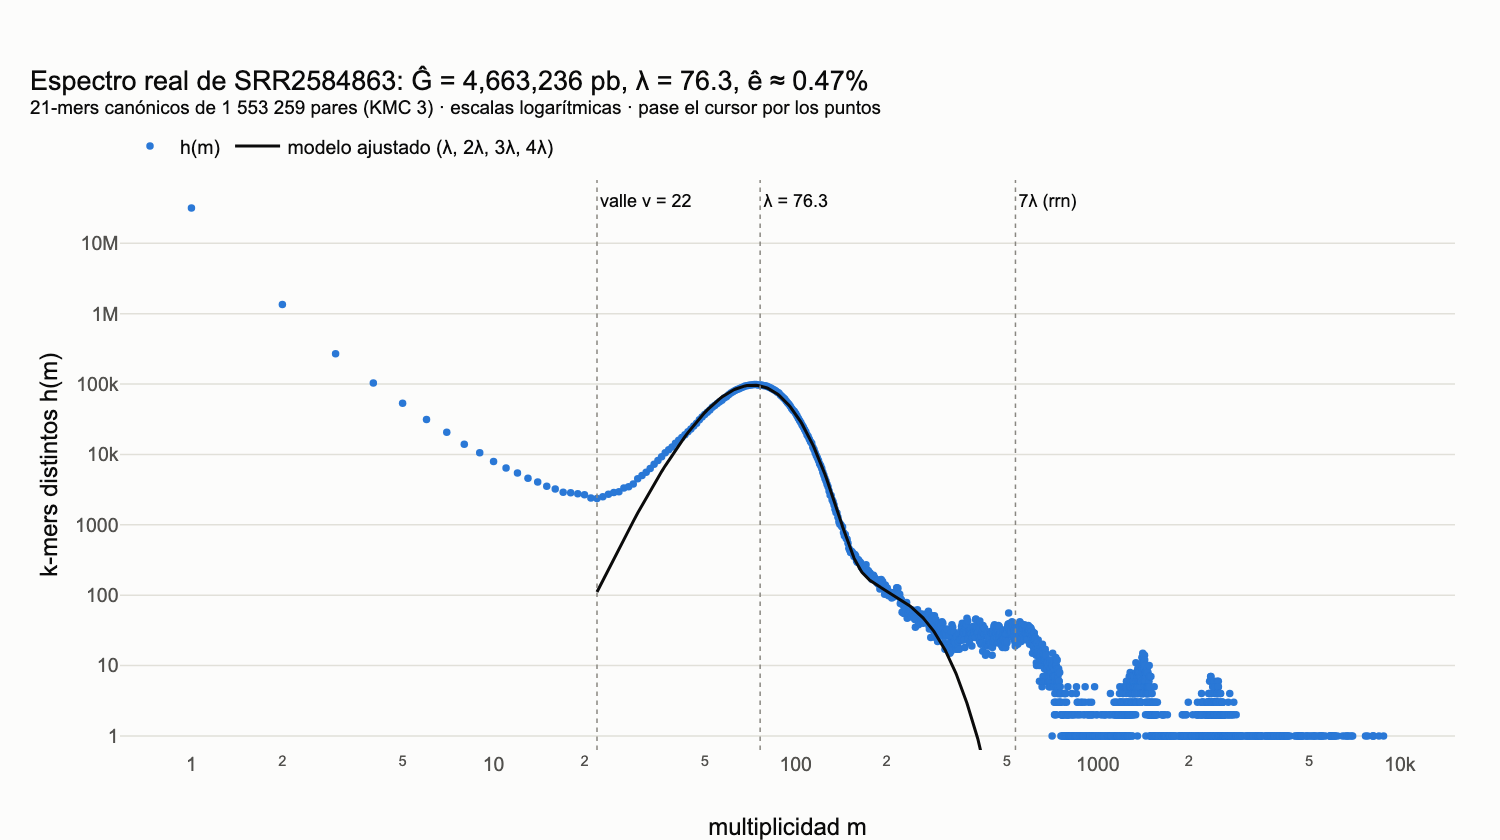

In [32]:
sel_p = np.flatnonzero(hist_real > 0)
sel_p = sel_p[sel_p >= 1]
mp, hp = m_real[sel_p], hist_real[sel_p]
def zone(m):
    if m < v_real: return "errores: k-mers con alguna base mal leída (casi todos únicos)"
    if m < 1.6 * lam_real: return "copia única: la gran mayoría del genoma"
    if 6.3 * lam_real <= m < 7.7 * lam_real: return "≈ 7 copias: los operones de ARN ribosómico (rrn)"
    if m < 9.5 * lam_real: return "repeticiones de pocas copias (o cola de la copia única)"
    return "muchas copias: elementos IS, otras repeticiones y posibles restos de adaptadores"
cd = np.column_stack([mp / lam_real, 100 * mp * hp / total_kmers, [zone(m) for m in mp]])
fig = go.Figure(go.Scatter(
    x=mp, y=hp, mode="markers", marker=dict(size=5, color=ec.BLUE), customdata=cd, name="h(m)",
    hovertemplate="<b>m = %{x:,}</b> · h(m) = %{y:,} k-mers distintos<br>≈ %{customdata[0]:.1f} copias (m/λ)"
                  "<br>aporta el %{customdata[1]:.3f} % de los k-mers leídos<br>%{customdata[2]}<extra></extra>"))
fig.add_scatter(x=np.arange(v_real, 700), y=mixture(par_real, np.arange(v_real, 700)), mode="lines",
                line=dict(color=ec.INK, width=2), name="modelo ajustado (λ, 2λ, 3λ, 4λ)",
                hovertemplate="modelo: m = %{x}, %{y:,.0f}<extra></extra>")
for x_, lab in [(v_real, f"valle v = {v_real}"), (lam_real, f"λ = {lam_real:.1f}"), (7 * lam_real, "7λ (rrn)")]:
    fig.add_vline(x=x_, line=dict(color=ec.MUTED, dash="dot", width=1))
    fig.add_annotation(x=np.log10(x_), y=7.6, text=lab, showarrow=False, xanchor="left", font=dict(size=12))
fig.update_layout(
    title=dict(text=f"Espectro real de SRR2584863: Ĝ = {G_fit:,.0f} pb, λ = {lam_real:.1f}, ê ≈ {e_hat:.2%}"
                    "<br><sup>21-mers canónicos de 1 553 259 pares (KMC 3) · escalas logarítmicas · pase el cursor por los puntos</sup>"),
    xaxis=dict(type="log", title="multiplicidad m"), yaxis=dict(type="log", title="k-mers distintos h(m)", range=[-0.2, 7.9]),
    height=560, margin=dict(t=120, l=80, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

### 7.3 (Opcional, sólo Colab) Recalcular el histograma desde las lecturas completas

La celda siguiente descarga los dos FASTQ completos del ENA (≈ 375 MB) y los cuenta con KMC. En Colab tarda unos
3–5 minutos, por eso está desactivada: cambie `RUN_FULL = True` para ejecutarla. Debería reproducir `SRR2584863_k21.histo`.

In [33]:
RUN_FULL = False                                   # cámbielo a True en Colab para contar las 3.1 millones de lecturas

if RUN_FULL:
    if not shutil.which("kmc"):
        subprocess.run("apt-get -qq update > /dev/null && apt-get -qq install -y kmc > /dev/null", shell=True)
    work = tempfile.mkdtemp(prefix="full81_")
    urls = ["https://" + u for u in meta.fastq_ftp.split(";")]
    paths = []
    for u in urls:
        p = os.path.join(work, os.path.basename(u))
        print("Descargando", u)
        urllib.request.urlretrieve(u, p)
        paths.append(p)
    open(os.path.join(work, "lista.txt"), "w").write("\n".join(paths) + "\n")
    t0 = time.time()
    subprocess.run(f"kmc -k21 -ci1 -cs100000 -t2 -m6 @{work}/lista.txt {work}/k21 {work} > {work}/kmc.log && "
                   f"kmc_tools transform {work}/k21 histogram {work}/k21.histo -cx100000", shell=True, check=True)
    full = np.loadtxt(f"{work}/k21.histo", dtype=np.int64)
    full = full[full[:, 1] > 0]
    h_full = np.zeros(full[:, 0].max() + 1, dtype=np.int64); h_full[full[:, 0]] = full[:, 1]
    print(f"KMC: {time.time() - t0:.0f} s · k-mers leídos {(np.arange(len(h_full)) * h_full).sum():,} "
          f"(histograma del curso: {total_kmers:,})")
else:
    print("RUN_FULL = False: usamos el histograma precomputado del curso.")

RUN_FULL = False: usamos el histograma precomputado del curso.


## 8. Elegir $k$

La elección de $k$ es un compromiso entre dos exigencias opuestas, como elegir el tamaño de letra de una señal de
tráfico: si es muy pequeña no se distingue una palabra de otra; si es muy grande no cabe nada en el cartel.

* $k$ debe ser **lo bastante grande** para que los $k$-mers sean **únicos** en el genoma: si un $k$-mer aparece en
  muchos lugares por puro azar, deja de identificar una posición.
* $k$ debe ser **lo bastante pequeño** para que los $k$-mers tengan cobertura suficiente y no se vean arruinados por los
  errores (ecuación 08-ck).

### 8.1 Unicidad: un modelo nulo

Cuantifiquemos la primera exigencia con un genoma **aleatorio** de $G$ bases equiprobables. Un $k$-mer dado puede
reaparecer en cualquiera de las $\approx 2G$ posiciones de las dos hebras, cada una con probabilidad $4^{-k}$. El número
de apariciones casuales es aproximadamente de Poisson con media $2G/4^k$, y la probabilidad de que haya al menos una es

$$
p_{\text{azar}}(k) \;=\; 1-\exp\!\left(-\frac{2G}{4^{k}}\right),
\qquad
p_{\text{azar}}\ll 1 \iff k \gg \log_4(2G)
\qquad\text{(ecuación 08-azar)}
$$

| Símbolo | Significado |
|---|---|
| $p_{\text{azar}}(k)$ | Probabilidad de que un $k$-mer del genoma aparezca otra vez por azar (no por una repetición biológica) |
| $2G/4^k$ | Número esperado de coincidencias casuales en las dos hebras |
| $\log_4(2G)$ | Longitud a partir de la cual los $k$-mers aleatorios empiezan a ser únicos |

**Ejemplo a mano.** Bacteria de 5 Mb con $k = 17$: $4^{17} = 1.72 \times 10^{10}$, $2G/4^k = 10^7 / 1.72\times10^{10} =
5.8 \times 10^{-4}$ y $p_{\text{azar}} \approx 5.8\times10^{-4}$. Humano (3.1 Gb): $2G/4^k = 6.2\times10^9/1.72\times10^{10}
= 0.36$ y $p_{\text{azar}} = 1 - e^{-0.36} = 0.30$. **Con $k=17$, uno de cada tres $k$-mers humanos reaparece por pura
casualidad.** Para una bacteria (5 Mb) $\log_4(2G) \approx 11.6$; para el humano $\approx 16.3$.

In [34]:
def p_random(k, G):
    """Probabilidad de que un k-mer reaparezca por azar en un genoma aleatorio de tamaño G (ecuación 08-azar)."""
    return 1 - np.exp(-2 * G / 4.0 ** k)

print(" k | P(azar) bacteria 5 Mb | P(azar) humano 3.1 Gb | (1−0.01)^k")
for k in (11, 15, 17, 21, 31):
    print(f"{k:2d} | {p_random(k, 5e6):21.3g} | {p_random(k, 3.1e9):21.3g} | {0.99 ** k:.3f}")
print(f"log4(2G): bacteria (5 Mb) = {math.log(2 * 5e6, 4):.2f} · humano (3.1 Gb) = {math.log(2 * 3.1e9, 4):.2f}")

 k | P(azar) bacteria 5 Mb | P(azar) humano 3.1 Gb | (1−0.01)^k
11 |                 0.908 |                     1 | 0.895
15 |               0.00927 |                 0.997 | 0.860
17 |              0.000582 |                 0.303 | 0.843
21 |              2.27e-06 |               0.00141 | 0.810
31 |              2.17e-12 |              1.34e-09 | 0.732
log4(2G): bacteria (5 Mb) = 11.63 · humano (3.1 Gb) = 16.26


Los genomas reales **no** son aleatorios. Midamos en REL606 qué fracción de las posiciones tiene un $k$-mer que aparece
más de una vez (en cualquiera de las dos hebras), y comparemos con el mismo genoma **barajado** (mismas letras, orden
aleatorio), que sí se comporta como el modelo nulo.

> 🤔 **Antes de ejecutar, prediga.** Con $k = 31$ el modelo nulo da $p_{\text{azar}} \approx 10^{-12}$. ¿Qué fracción
> de las posiciones de REL606 cree que tendrá un 31-mer repetido: ninguna, 0.1 % o varios por ciento?

In [35]:
def repeated_fraction(genome_codes, k):
    """Fracción de posiciones del genoma cuyo k-mer canónico aparece en más de una posición."""
    c_ = kmers_canon(genome_codes[None, :], k)
    u_, inv_, n_ = np.unique(c_, return_inverse=True, return_counts=True)
    return float((n_[inv_] > 1).mean())

t0 = time.time()
g_shuf = rng.permutation(g_rel)
k_scan = [9, 10, 11, 12, 13, 14, 15, 17, 21, 31]
scan = pd.DataFrame({"k": k_scan,
                     "REL606 real": [repeated_fraction(g_rel, k) for k in k_scan],
                     "REL606 barajado": [repeated_fraction(g_shuf, k) for k in k_scan],
                     "modelo nulo (08-azar)": [p_random(k, len(g_rel)) for k in k_scan]})
print(scan.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print(f"({time.time() - t0:.1f} s)")

 k  REL606 real  REL606 barajado  modelo nulo (08-azar)
 9       0.9997                1                      1
10       0.9912           0.9998                 0.9999
11       0.8954             0.89                   0.89
12       0.6048           0.4254                 0.4242
13       0.2945           0.1295                 0.1289
14       0.1267           0.0341                0.03391
15      0.06302         0.008734               0.008587
17      0.03508        0.0005406              0.0005388
21      0.03027         4.32e-07              2.105e-06
31      0.02728                0              2.008e-12
(12.5 s)


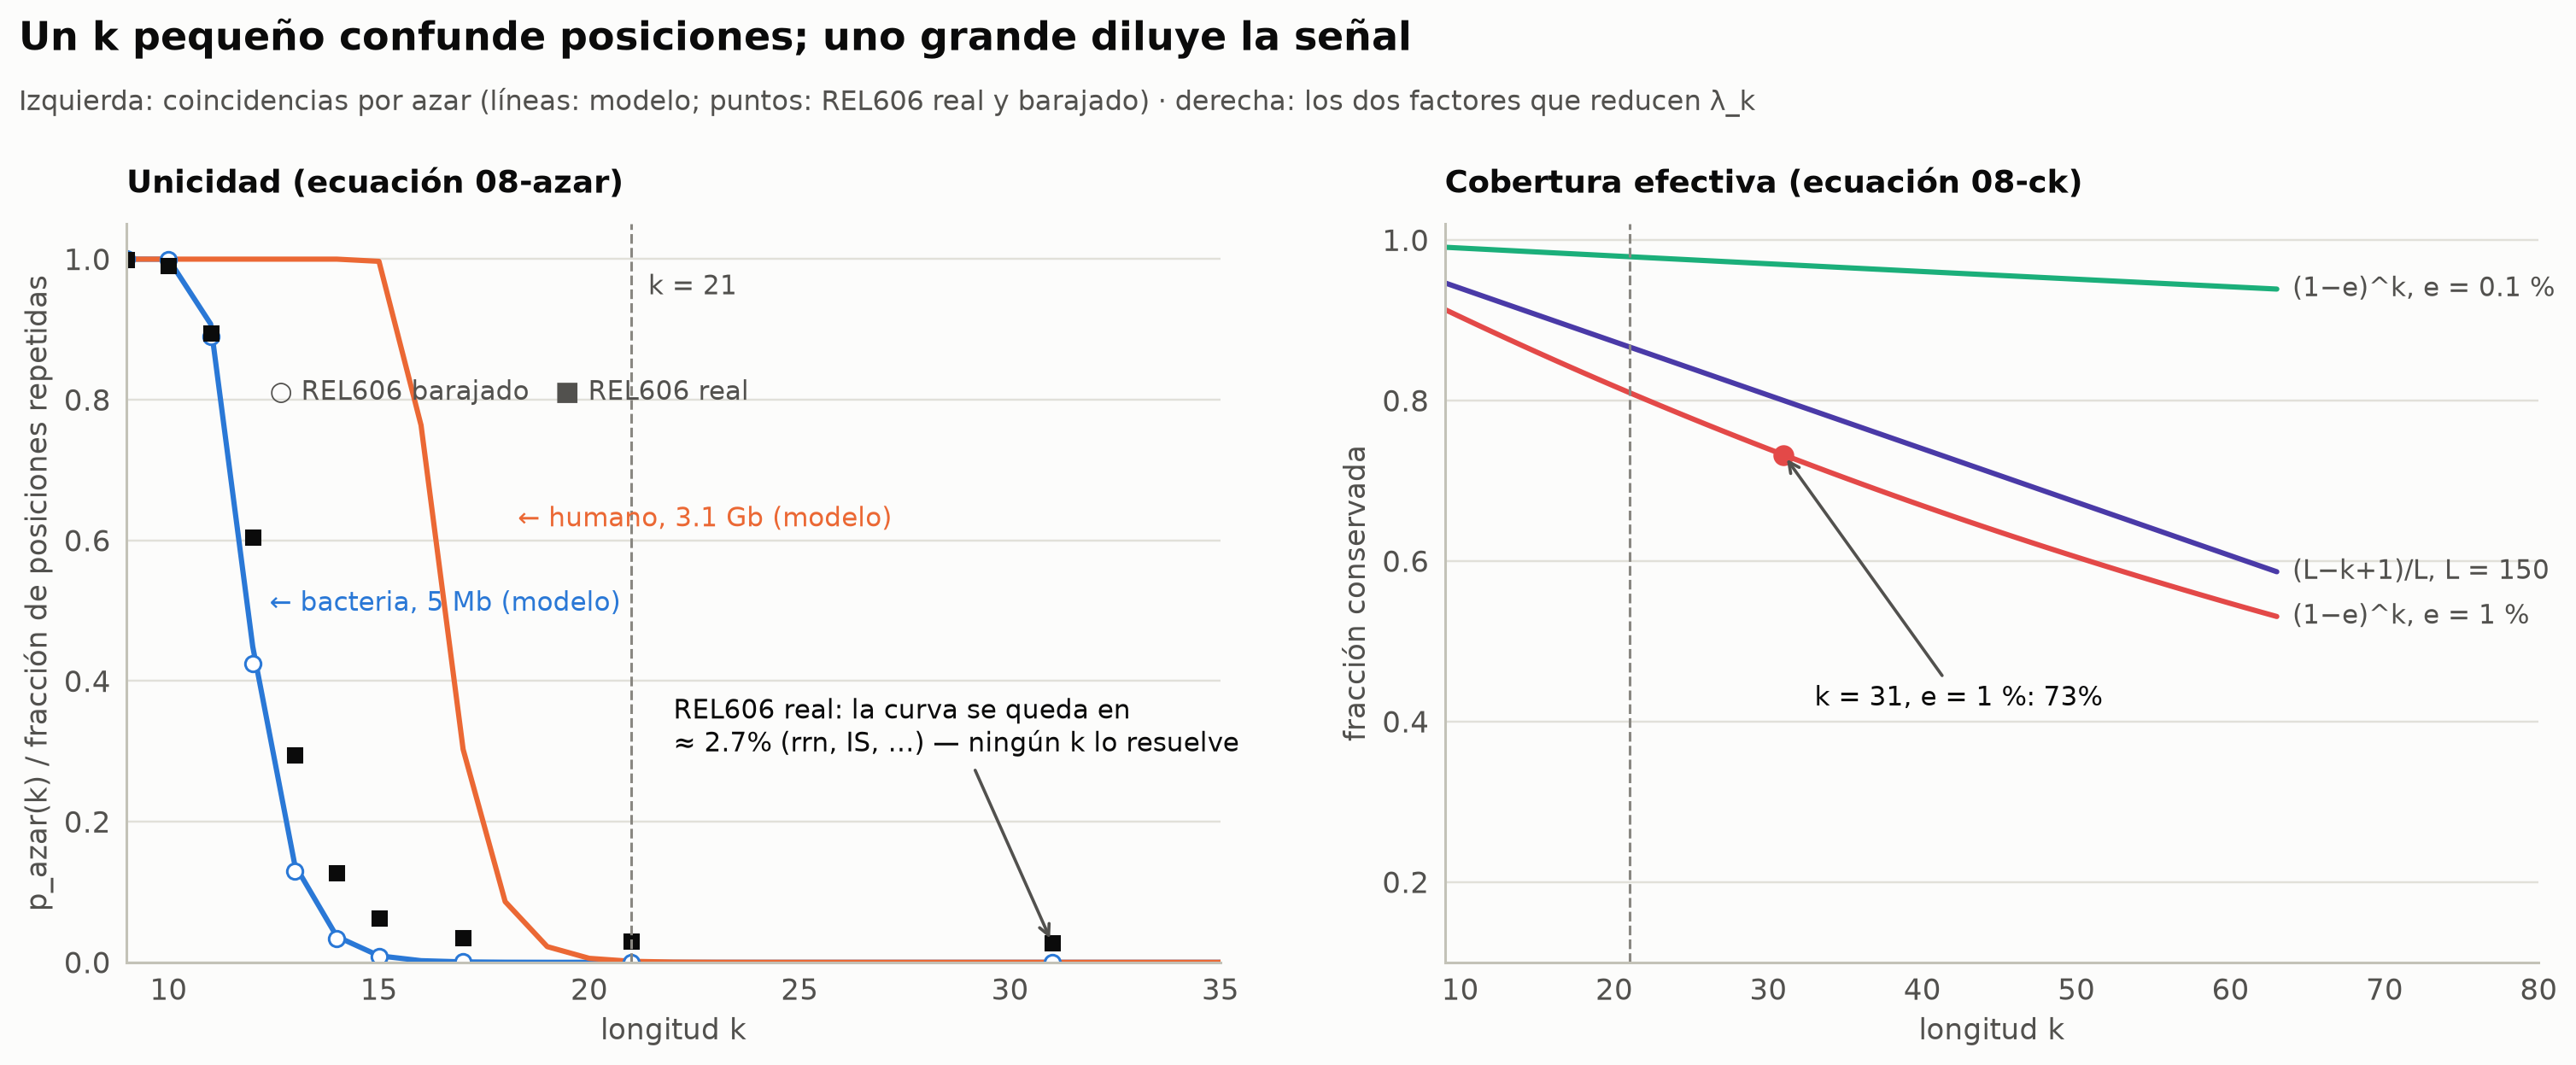

In [36]:
kk = np.arange(9, 64)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(kk, p_random(kk, 5e6), color=ec.BLUE, lw=2)
ax1.plot(kk, p_random(kk, 3.1e9), color=ec.ORANGE, lw=2)
ax1.plot(scan.k, scan["REL606 barajado"], "o", color=ec.BLUE, mfc="white", ms=6)
ax1.plot(scan.k, scan["REL606 real"], "s", color=ec.INK, ms=5)
ax1.text(12.4, 0.5, "← bacteria, 5 Mb (modelo)", color=ec.BLUE, fontsize=10)
ax1.text(18.3, 0.62, "← humano, 3.1 Gb (modelo)", color=ec.ORANGE, fontsize=10)
ax1.annotate(f"REL606 real: la curva se queda en\n≈ {scan['REL606 real'].iloc[-1]:.1%} (rrn, IS, …) — ningún k lo resuelve",
             (31, scan["REL606 real"].iloc[-1]), xytext=(22, 0.3), fontsize=10,
             arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.INK_2))
ax1.text(12.4, 0.8, "○ REL606 barajado   ■ REL606 real", fontsize=10, color=ec.INK_2)
ax1.axvline(21, color=ec.MUTED, ls="--", lw=1)
ax1.text(21.4, 0.95, "k = 21", fontsize=10, color=ec.INK_2)
ax1.set_xlim(9, 35); ax1.set_ylim(0, 1.05)
ax1.set_xlabel("longitud k"); ax1.set_ylabel("p_azar(k) / fracción de posiciones repetidas")
ax1.set_title("Unicidad (ecuación 08-azar)", loc="left", fontsize=12)

for y_, lab, col in [(0.999 ** kk, "(1−e)^k, e = 0.1 %", ec.AQUA), (0.99 ** kk, "(1−e)^k, e = 1 %", ec.RED),
                     ((150 - kk + 1) / 150, "(L−k+1)/L, L = 150", ec.VIOLET)]:
    ax2.plot(kk, y_, color=col, lw=2)
    ec.label_end(ax2, kk[-1], y_[-1], lab)
ax2.axvline(21, color=ec.MUTED, ls="--", lw=1)
ax2.plot([31], [0.99 ** 31], "o", color=ec.RED)
ax2.annotate(f"k = 31, e = 1 %: {0.99 ** 31:.0%}", (31, 0.99 ** 31), xytext=(33, 0.42), fontsize=10,
             arrowprops=dict(arrowstyle="->", lw=1.2, color=ec.INK_2))
ax2.set_xlim(9, 80); ax2.set_ylim(0.1, 1.02)
ax2.set_xlabel("longitud k"); ax2.set_ylabel("fracción conservada")
ax2.set_title("Cobertura efectiva (ecuación 08-ck)", loc="left", fontsize=12)
ec.fig_title(fig, "Un k pequeño confunde posiciones; uno grande diluye la señal",
             "Izquierda: coincidencias por azar (líneas: modelo; puntos: REL606 real y barajado) · derecha: los dos factores que reducen λ_k")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** El genoma **barajado** sigue la curva del modelo nulo casi al pie de la letra: la transición
> ocurre cerca de $\log_4(2G) \approx 11.6$. El genoma **real** también cae en picado… hasta quedarse en una meseta del
> **~3 %** que no baja ni con $k = 31$. Esas posiciones son **repeticiones biológicas** (los 7 operones *rrn*, decenas de
> elementos IS, genes de tRNA, familias génicas), mucho más largas que cualquier $k$ razonable. Ningún $k$ las resuelve:
> será el problema central de la Lección 8.2. A la derecha, con errores del 1 %, un 31-mer se conserva intacto sólo el
> 73 % de las veces. Los ensambladores modernos (SPAdes, Lección 8.3) esquivan el dilema usando **varios** valores de $k$
> a la vez.

El compromiso completo, interactivo. Para cada $k$ se muestran las dos exigencias con lecturas de 150 pb. Pase el cursor
para ver los números; haga clic en la leyenda para ocultar curvas.

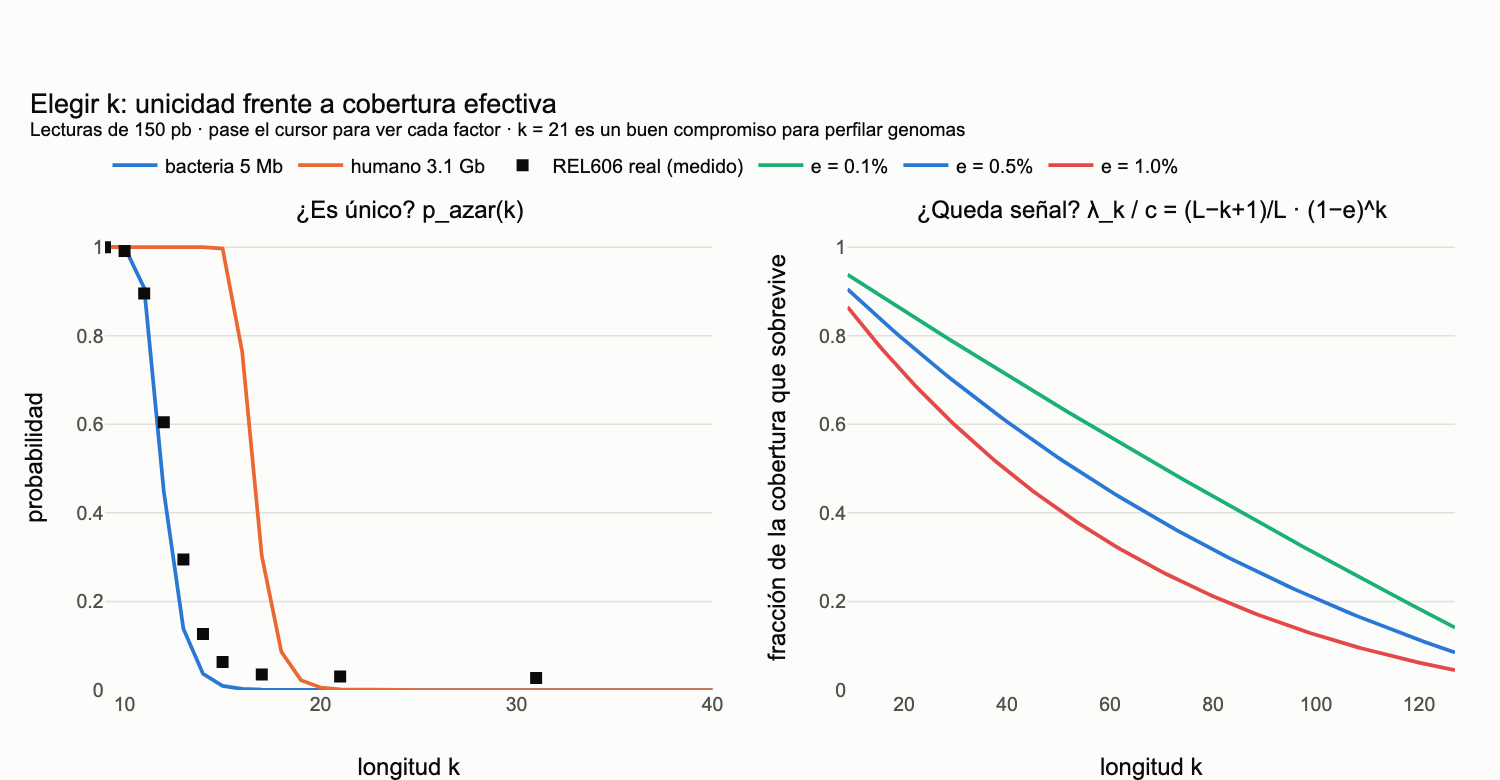

In [37]:
kk = np.arange(9, 128)
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.1,
                    subplot_titles=("¿Es único? p_azar(k)", "¿Queda señal? λ_k / c = (L−k+1)/L · (1−e)^k"))
for G_, nm, col in [(5e6, "bacteria 5 Mb", ec.BLUE), (3.1e9, "humano 3.1 Gb", ec.ORANGE)]:
    fig.add_scatter(x=kk, y=p_random(kk, G_), name=nm, line=dict(color=col, width=2.5), row=1, col=1,
                    customdata=2 * G_ / 4.0 ** kk,
                    hovertemplate=f"<b>{nm}</b><br>k = %{{x}}<br>coincidencias esperadas 2G/4^k = %{{customdata:.3g}}"
                                  "<br>p_azar = %{y:.3g}<extra></extra>")
fig.add_scatter(x=scan.k, y=scan["REL606 real"], mode="markers", name="REL606 real (medido)",
                marker=dict(color=ec.INK, symbol="square", size=8), row=1, col=1,
                hovertemplate="REL606, k = %{x}<br>%{y:.2%} de las posiciones tienen un k-mer repetido"
                              "<br>(meseta = repeticiones biológicas)<extra></extra>")
for e_, col in [(0.001, ec.AQUA), (0.005, ec.BLUE), (0.01, ec.RED)]:
    y_ = (150 - kk + 1) / 150 * (1 - e_) ** kk
    fig.add_scatter(x=kk, y=y_, name=f"e = {e_:.1%}", line=dict(color=col, width=2.5, dash="solid"), row=1, col=2,
                    customdata=np.column_stack([(150 - kk + 1) / 150, (1 - e_) ** kk, 30 * y_]),
                    hovertemplate=f"<b>e = {e_:.1%}</b>, k = %{{x}}<br>(L−k+1)/L = %{{customdata[0]:.3f}}"
                                  "<br>(1−e)^k = %{customdata[1]:.3f}<br>λ_k / c = %{y:.3f}"
                                  "<br>con 30× de cobertura: λ_k = %{customdata[2]:.1f}<extra></extra>")
fig.update_xaxes(title_text="longitud k")
fig.update_yaxes(title_text="probabilidad", range=[0, 1.05], row=1, col=1)
fig.update_xaxes(range=[9, 40], row=1, col=1)
fig.update_yaxes(title_text="fracción de la cobertura que sobrevive", range=[0, 1.05], row=1, col=2)
fig.update_layout(
    title=dict(text="Elegir k: unicidad frente a cobertura efectiva"
                    "<br><sup>Lecturas de 150 pb · pase el cursor para ver cada factor · k = 21 es un buen compromiso para perfilar genomas</sup>"),
    height=520, margin=dict(t=150, l=70, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.08, x=0))
fig.show()

> ✅ **Compruebe su comprensión.** ¿Por qué $k = 21$ es un valor habitual para **perfilar** genomas (GenomeScope) pero los
> ensambladores como SPAdes usan $k$ de 21 a 77 (o más)? *(Respuesta: para contar y ajustar un espectro basta con que $p_{\text{azar}}$ sea
> despreciable ($2\times10^{-6}$ en bacterias, $1.4\times10^{-3}$ en humanos con $k=21$) y conviene conservar la mayor
> cobertura posible. Para ensamblar interesa además que los $k$-mers sean más largos que las repeticiones cortas, aunque
> se pierda cobertura: por eso se combinan varios $k$.)*

> 🔬 **Para profundizar: los $k$-mers como regla de medir la calidad.** El espectro no sólo sirve **antes** del
> ensamblaje. Si contamos por separado los $k$-mers de las lecturas y los del ensamblaje terminado, cada $k$-mer del
> ensamblaje que no aparece en las lecturas señala casi con certeza un error de consenso. **Merqury** (Rhie *et al.*,
> 2020) convierte esa idea en una estimación de la exactitud por base sin necesidad de referencia, y usa los espectros de
> los padres para medir si un ensamblaje separa correctamente los dos haplotipos. Lo usaremos en la Lección 8.3.

> 💡 **Idea clave.** El espectro de $k$-mers es una radiografía gratuita del genoma: el pico en $2\lambda$ da la
> cobertura, la masa bajo la curva dividida por $2\lambda$ da el tamaño, y el pico en $\lambda$ delata la
> heterocigosidad. (En un haploide, el único pico es $\lambda$.)

## 9. ✍️ Ejercicios

**Ejercicio 1 — Canónicos y 2 bits a mano.** Para $x_1 = \texttt{GGCAT}$ y $x_2 = \texttt{ATGCC}$: (a) calcule
$\bar{x}$ y $\kappa(x)$ de cada uno; (b) ¿qué relación hay entre ellos?; (c) calcule a mano el código de 2 bits de
$\kappa(x_1)$ y compruébelo con `kmer_code`; (d) ¿cuántos 5-mers canónicos distintos existen?

**Ejercicio 2 — Confundir los picos.** Simule un diploide de 200 kb con **$h = 3\,\%$**, $e = 0.5\,\%$ y
**$10\times$ por haplotipo** (use `simulate_reads`, `count_codes` y `count_spectrum`). (a) ¿Qué pico es más alto?
(b) Calcule $\widehat{G}$ tomando la multiplicidad del pico más alto como «la cobertura» y compárelo con el correcto,
$\sum_{m\ge v} m\,h(m)/(2\lambda)$ con $\lambda$ teórica. (c) Explique el resultado con $\alpha$.

**Ejercicio 3 — Otro $k$ para las lecturas reales.** Recuente los $k$-mers de la región real (`R_reg`) con $k = 31$.
¿Dónde queda ahora el pico de copia única? Compare el cociente de picos (31 frente a 21) con el que predice la ecuación
08-ck usando $\hat e$ de la sección 7.

**Ejercicio 4 — La tasa de error desde el espectro.** Con el espectro de la simulación del libro (`hist_sim`) estime la
tasa de error por base como $\hat e = 1 - \left(\sum_{m\ge v} m\,h(m) / \sum_m m\,h(m)\right)^{1/k}$. ¿Se parece al 0.5 %
simulado? ¿Por qué esta estimación ignora los errores que producen un $k$-mer que ya existía en el genoma?

In [38]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
for x in ["GGCAT", "ATGCC"]:
    print(f"x = {x} · x̄ = {revcomp(x)} · κ(x) = {canonical(x)}")
print("(b) Son reversos complementarios el uno del otro: comparten la misma clave canónica, ATGCC.")
print("(c) ATGCC → 00 11 10 01 01 = 0b0011100101 =", 0b0011100101, "· kmer_code:", kmer_code("ATGCC"))
print("(d) k impar → sin palíndromos → 4^5 / 2 =", 4 ** 5 // 2, "5-mers canónicos")

x = GGCAT · x̄ = ATGCC · κ(x) = ATGCC
x = ATGCC · x̄ = GGCAT · κ(x) = ATGCC
(b) Son reversos complementarios el uno del otro: comparten la misma clave canónica, ATGCC.
(c) ATGCC → 00 11 10 01 01 = 0b0011100101 = 229 · kmer_code: 229
(d) k impar → sin palíndromos → 4^5 / 2 = 512 5-mers canónicos


In [39]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
rng_ex = np.random.default_rng(2)
hA = rng_ex.integers(0, 4, 200_000).astype(np.uint8)
hB = hA.copy(); sn = rng_ex.random(hA.size) < 0.03
hB[sn] = (hB[sn] + rng_ex.integers(1, 4, sn.sum())) % 4
hx = count_spectrum(np.concatenate([count_codes(simulate_reads(g_, 10, err=0.005, rng=rng_ex), 21) for g_ in (hA, hB)]))
v_ex = find_valley(hx, 2, 8)
top = v_ex + int(np.argmax(hx[v_ex:60]))
lam_t = 10 * 130 / 150 * 0.995 ** 21
mass_ex = (np.arange(len(hx)) * hx)[v_ex:].sum()
alpha_ex = 1 - 0.97 ** 21
print(f"(a) Pico más alto en m = {top} (λ teórica = {lam_t:.1f}, 2λ = {2 * lam_t:.1f}): es el HETEROCIGOTO")
print(f"(b) Ĝ ingenuo = masa / {top} = {mass_ex / top:,.0f} pb · Ĝ correcto = masa / 2λ = {mass_ex / (2 * lam_t):,.0f} pb")
print(f"(c) α = 1 − 0.97^21 = {alpha_ex:.2f}: hay 2Gα = {2 * alpha_ex:.2f}G k-mers heterocigotos frente a "
      f"G(1−α) = {1 - alpha_ex:.2f}G homocigotos; el pico de λ es más alto y el ingenuo duplica el genoma.")

(a) Pico más alto en m = 7 (λ teórica = 7.8, 2λ = 15.6): es el HETEROCIGOTO
(b) Ĝ ingenuo = masa / 7 = 446,585 pb · Ĝ correcto = masa / 2λ = 200,371 pb
(c) α = 1 − 0.97^21 = 0.47: hay 2Gα = 0.95G k-mers heterocigotos frente a G(1−α) = 0.53G homocigotos; el pico de λ es más alto y el ingenuo duplica el genoma.


In [40]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
h31 = count_spectrum(count_codes(R_reg, 31))
v31 = find_valley(h31)
peak31 = v31 + int(np.argmax(h31[v31:200]))
lam31 = fit_haploid(h31, v31, 150, peak31)[0]
pred_ratio = (150 - 31 + 1) / (150 - 21 + 1) * (1 - e_hat) ** 10
print(f"k = 21: λ = {lam_reg:.1f} · k = 31: λ = {lam31:.1f} (moda {peak31})")
print(f"Cociente observado {lam31 / lam_reg:.3f} · predicho (120/130)·(1−ê)^10 = {pred_ratio:.3f}")
print("El pico se corre a la izquierda como predice la ecuación 08-ck; la diferencia de unos puntos refleja la\n"
      "incertidumbre de ajustar λ en un espectro tan sobredisperso y con sólo 250 kb de genoma.")

k = 21: λ = 30.2 · k = 31: λ = 27.3 (moda 26)
Cociente observado 0.904 · predicho (120/130)·(1−ê)^10 = 0.880
El pico se corre a la izquierda como predice la ecuación 08-ck; la diferencia de unos puntos refleja la
incertidumbre de ajustar λ en un espectro tan sobredisperso y con sólo 250 kb de genoma.


In [41]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
tot_sim = (np.arange(len(hist_sim)) * hist_sim).sum()
e_sim = 1 - (mass_true / tot_sim) ** (1 / K)
print(f"Fracción de k-mers por encima del valle: {mass_true / tot_sim:.4f} · ê = {e_sim:.3%} (simulado: 0.5 %)")
print("Un error que convierte un k-mer en otro que ya existe en el genoma (p. ej., en una repetición o en el otro\n"
      "alelo) cae por encima del valle y no se cuenta como error; en un genoma aleatorio de 1 Mb es rarísimo.")

Fracción de k-mers por encima del valle: 0.9004 · ê = 0.498% (simulado: 0.5 %)
Un error que convierte un k-mer en otro que ya existe en el genoma (p. ej., en una repetición o en el otro
alelo) cae por encima del valle y no se cuenta como error; en un genoma aleatorio de 1 Mb es rarísimo.


## 📌 Resumen

* Un **$k$-mer** es una palabra de longitud $k$; una lectura de longitud $L$ contiene $L-k+1$. Se cuentan **canónicos**,
  $\kappa(x) = \min\{x, \bar{x}\}$, para no separar las dos hebras; con $k$ **impar** no hay palíndromos. Se guardan como
  enteros de **2 bits por base** y se actualizan con desplazamiento y máscara.
* La **cobertura de $k$-mers** es $\lambda_k = c\,\frac{L-k+1}{L}(1-e)^k$: con 20×, 150 pb, $k = 21$ y $e = 0.5\,\%$,
  $17.33 \times 0.900 = 15.60$.
* El **espectro** $h(m)$ cuenta cuántos $k$-mers distintos se vieron $m$ veces. Firmas: **errores** (muro en $m \le 3$:
  muchos distintos, pocos leídos), **heterocigosidad** (pico en $\lambda$, mitad de $2\lambda$) y **repeticiones**
  (múltiplos de la cobertura).
* Modelo diploide: $\alpha = 1-(1-h)^k$ (0.19 con $h = 1\,\%$, $k = 21$); mezcla de binomiales negativas;
  $\widehat{G} = \sum_{m\ge v} m\,h(m) / 2\lambda$ (la heterocigosidad se cancela) y
  $\widehat{h} = 1-(1-\widehat{\alpha})^{1/k}$. Reprodujimos el libro: $\widehat{G} = 1\,000\,409$ pb,
  $\widehat{h} = 1.02\,\%$.
* **Contar a escala**: Jellyfish (tabla *hash* sin bloqueos), KMC 3 (particiones en disco + ordenar), filtros de Bloom
  para no guardar los $k$-mers únicos. Nuestro contador en NumPy y KMC dieron el mismo histograma.
* **Datos reales (SRR2584863)**: valle en 22, moda en 73, $\lambda = 76.3$, $\widehat{G} \approx 4.66$ Mb frente a
  4 629 812 pb (+0.7 %), $\hat e \approx 0.47\,\%$. El pico no está en $c_k \approx 87$ porque faltan ventanas, un
  9.5 % de los $k$-mers tiene errores y la cobertura real está **sobredispersa** (la moda queda por debajo de la media).
  Los 7 operones *rrn* aparecen en $\approx 7\lambda$.
* **Elegir $k$**: $p_{\text{azar}}(k) = 1-e^{-2G/4^k}$ exige $k \gg \log_4(2G)$; $(1-e)^k$ y $(L-k+1)/L$ castigan los $k$
  grandes. Las repeticiones biológicas (≈ 3 % de REL606) no desaparecen con ningún $k$.

## 📚 Para profundizar

* Marçais, G. & Kingsford, C. (2011). A fast, lock-free approach for efficient parallel counting of occurrences of
  *k*-mers. *Bioinformatics* 27(6): 764–770. doi:10.1093/bioinformatics/btr011
* Kokot, M., Długosz, M. & Deorowicz, S. (2017). KMC 3: counting and manipulating *k*-mer statistics. *Bioinformatics*
  33(17): 2759–2761. doi:10.1093/bioinformatics/btx304
* Vurture, G. W., Sedlazeck, F. J., Nattestad, M., Underwood, C. J., Fang, H., Gurtowski, J. & Schatz, M. C. (2017).
  GenomeScope: fast reference-free genome profiling from short reads. *Bioinformatics* 33(14): 2202–2204.
  doi:10.1093/bioinformatics/btx153
* Ranallo-Benavidez, T. R., Jaron, K. S. & Schatz, M. C. (2020). GenomeScope 2.0 and Smudgeplot for reference-free
  profiling of polyploid genomes. *Nature Communications* 11: 1432. doi:10.1038/s41467-020-14998-3
* Lander, E. S. & Waterman, M. S. (1988). Genomic mapping by fingerprinting random clones: a mathematical analysis.
  *Genomics* 2(3): 231–239. doi:10.1016/0888-7543(88)90007-9
* Bloom, B. H. (1970). Space/time trade-offs in hash coding with allowable errors. *Communications of the ACM* 13(7):
  422–426.
* Melsted, P. & Pritchard, J. K. (2011). Efficient counting of *k*-mers in DNA sequences using a bloom filter.
  *BMC Bioinformatics* 12: 333.
* Rhie, A., Walenz, B. P., Koren, S. & Phillippy, A. M. (2020). Merqury: reference-free quality, completeness, and
  phasing assessment for genome assemblies. *Genome Biology* 21: 245. doi:10.1186/s13059-020-02134-9
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*
  536(7615): 165–170. (Origen de las lecturas: BioProject PRJNA295606.)
* Documentación: KMC (https://github.com/refresh-bio/KMC), Jellyfish (https://github.com/gmarcais/Jellyfish) y
  GenomeScope 2.0 (https://github.com/tbenavi1/genomescope2.0).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)